# Developed CNN Architecture (No Improving CNN Architecture + Bicubic Grayscale PNG + 5-Fold)) with LIBFT (Layer Importance-Based Fine-Tuning)

### 1.1 Libraries

In [15]:
%%time

import os
import pickle
import shutil
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import math
from tqdm import tqdm

# Importar librerias de tensorflow
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model, Model
#from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler

CPU times: user 1.54 ms, sys: 0 ns, total: 1.54 ms
Wall time: 1.53 ms


In [16]:
!nvidia-smi

Tue Jul 15 00:21:19 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.107.02             Driver Version: 550.107.02     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A5500               Off |   00000000:1A:00.0 Off |                  Off |
| 30%   28C    P8             17W /  230W |       4MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [17]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))
print(tf.config.experimental.get_visible_devices())

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 1.2. Sound and Source

In [18]:
from IPython.display import Audio
import time

def sound():
    beep_07a_path = '/notebooks/beep-07a.wav'
    beep_08b_path = '/notebooks/beep-08b.wav'

    for _ in range(2):
        sound_beep_07a = Audio(beep_07a_path, autoplay=True)
        display(sound_beep_07a)
        time.sleep(0.3)
        sound_beep_08b = Audio(beep_08b_path, autoplay=True)
        display(sound_beep_08b)
        time.sleep(0.3)
sound()

### 1.3. Create a dictionary to store samples by malware families

In [19]:
source = '/notebooks/train3/'
# Inicializar un diccionario para almacenar la cantidad de muestras por familia
malware_families_train, malware_families_valid, malware_families_test, malware_families = {}, {}, {}, {}
train_data_dir = os.path.join(source, 'centum_1500/train/')
valid_data_dir = os.path.join(source, 'centum_1500/valid/')
test_data_dir = os.path.join(source, 'centum_1500/test/')
# Recorrer los directorios de las familias de malware
for familia in os.listdir(train_data_dir):
    # Comprobar si es un directorio
    if os.path.isdir(os.path.join(train_data_dir, familia)):
        # Contar la cantidad de archivos en el directorio de la familia
        cantidad_muestras_train = len(os.listdir(os.path.join(train_data_dir, familia)))
        cantidad_muestras_valid = len(os.listdir(os.path.join(valid_data_dir, familia)))
        cantidad_muestras_test = len(os.listdir(os.path.join(test_data_dir, familia)))
        # Agregar la cantidad al diccionario con el nombre de la familia como clave
        malware_families_train[familia] = cantidad_muestras_train
        malware_families_valid[familia] = cantidad_muestras_valid
        malware_families_test[familia] = cantidad_muestras_test

for d in (malware_families_train, malware_families_valid, malware_families_test):
    for key, value in d.items():
        if key in malware_families:
            malware_families[key] += value
        else:
            malware_families[key] = value

# Ordenar las familias de mayor a menor según la cantidad de muestras
sorted_families = sorted(malware_families.items(), key=lambda x: x[1], reverse=True)
# Imprimir el diccionario resultante
sorted_families

[('sfone', 1500),
 ('sillyp2p', 1500),
 ('Allaple.A', 1500),
 ('Ramnit', 1500),
 ('wabot', 1500),
 ('mira', 1500),
 ('Kelihos_ver3', 1500),
 ('ganelp', 1500),
 ('Allaple.L', 1500),
 ('wacatac', 1500),
 ('dinwod', 1500),
 ('Lollipop', 1500),
 ('berbew', 1500),
 ('small', 1500),
 ('upatre', 1500)]

### 1.3. Create a dictionary to store samples by malware families

In [20]:
%%time

def copy_malware_families(source, num_experiments, sorted_families):
    
    # Crea el directorio que contendrá el malware
    experiment_dir = os.path.join(source, "all_malware", str(num_experiments))
    os.makedirs(experiment_dir, exist_ok=True)

    # Ordenar las familias de mayor a menor según la cantidad de muestras
    #sorted_families = sorted(malware_families.items(), key=lambda x: x[1], reverse=True)

    # Crear directorios train, test, y valid del experimento
    for data_type in ['train', 'test', 'valid']:
        data_dir = os.path.join(experiment_dir, data_type)
        os.makedirs(data_dir, exist_ok=True)
        
        # Copiar las familias correspondientes
        for j in range(num_experiments):
            family_name, num_samples = sorted_families[j]
            family_dir = os.path.join(data_dir, family_name)
            os.makedirs(family_dir, exist_ok=True)
            source_dir = os.path.join(source, 'centum_1500', data_type, family_name)
            
            # Copiar las num_samples muestras de cada familia
            for filename in os.listdir(source_dir)[:num_samples]:
                source_path = os.path.join(source_dir, filename)
                dest_path = os.path.join(family_dir, filename)
                shutil.copy(source_path, dest_path)
    print("Familias de malware copiadas")
    #sound()

def delete_experiment_dir(source, num_experiments):
    experiment_dir = os.path.join(source, "all_malware", str(num_experiments))
    shutil.rmtree(experiment_dir)
    print(f"La carpeta {str(num_experiments)} fue eliminada.")

CPU times: user 27 µs, sys: 0 ns, total: 27 µs
Wall time: 36 µs


## 2. Convolutional Neural Network Decay Evaluation Metrics by Increase in Malware Families

### 2.1. Calculate Weights by Class

In [21]:
%%time

def weights_by_class(train_generator):
    # Calculate class weights using compute_class_weight
    class_weights = compute_class_weight(class_weight = 'balanced',
                         classes = np.unique(train_generator.classes), 
                         y = train_generator.classes)
    # Create a dictionary of class weights
    class_weight_dict = dict(enumerate(class_weights))
    # Print class weights
    print("Class Weights:", class_weight_dict)
    return class_weight_dict

CPU times: user 10 µs, sys: 0 ns, total: 10 µs
Wall time: 16.2 µs


### 2.2. Image generator (Training, validation, and testing)

In [22]:
%%time

def data_gen(source_cnn, train_data_dir, validation_data_dir, test_data_dir):
    # Settings for Data Generator
    train_datagen = ImageDataGenerator(rescale=1./255)
    validation_datagen = ImageDataGenerator(rescale=1./255)
    test_datagen = ImageDataGenerator(rescale=1./255)

    train_generator = train_datagen.flow_from_directory(
            train_data_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=False
    )

    validation_generator = validation_datagen.flow_from_directory(
            validation_data_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            class_mode='categorical')

    test_generator = test_datagen.flow_from_directory(
            test_data_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            class_mode='categorical')
    return (train_generator, validation_generator, test_generator)

CPU times: user 21 µs, sys: 10 µs, total: 31 µs
Wall time: 35.8 µs


### 2.3. Creation of the Model Based on the Architecture
Descongelamos 5 capas de MobileNet para esta versión, pero para más adelante, version optimizada,podemos desconger 10 capas.

In [23]:
%%time

def new_model(num_classes):
    # Use MobileNet architecture with imagenet weights by transfer Learning 
    base_model = MobileNet(weights='imagenet',
                           include_top=False,
                           input_shape=(img_width, img_height, 3))

    # Freeze the convolutional layers of the pretrained model
    for layer in base_model.layers:
        layer.trainable = False

    # Unfreeze the last 5 layers of the MobileNet base model
    for layer in base_model.layers[-5:]:
        layer.trainable = True

    # Malware classification head
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    #x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x) # Probar con 0.5 si no mejora los resultados
    x = layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)  # Nueva capa adicional
    x = Dropout(0.3)(x) # Nueva capa adicional
    predictions = layers.Dense(num_classes, activation='softmax')(x)

    # Combining the pretrained model with the malware classification layer
    model = models.Model(inputs=base_model.input, outputs=predictions)

    # Compile the model with an optimizer and learning rate
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    
    # Calculate the total # parameters
    total_params = model.count_params()
    trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    non_trainable_params = total_params - trainable_params
    # Print request info paramers
    print("Total params: {}".format(total_params))
    print("Trainable params: {}".format(trainable_params))
    print("Non-trainable params: {}".format(non_trainable_params))

    
    return model

CPU times: user 30 µs, sys: 0 ns, total: 30 µs
Wall time: 35.5 µs


### 2.4. Evaluate the model and graphs

#### 2.4.1. Get the accuracy and log loss of the model (Train, Validation and Test)

In [24]:
%%time

def prediction(model, train_generator, validation_generator, test_generator):
    # Obtener la precisión y la pérdida en el conjunto de datos de entrenamiento
    train_loss, train_acc = model.evaluate(train_generator, verbose=1)
    print('Train Accuracy:', train_acc)
    print('Train Log Loss:', train_loss)

    # Obtener la precisión y la pérdida en el conjunto de datos de validación
    val_loss, val_acc = model.evaluate(validation_generator, verbose=1)
    print('Validation Accuracy:', val_acc)
    print('Validation Log Loss:', val_loss)

    # Obtener la precisión y la pérdida en el conjunto de datos de prueba
    test_loss, test_acc = model.evaluate(test_generator, verbose=1)
    print('Test Accuracy:', test_acc)
    print('Test Log Loss:', test_loss)
    
    # Return test_loss and test_acc
    return(test_acc, test_loss)

CPU times: user 19 µs, sys: 0 ns, total: 19 µs
Wall time: 24.6 µs


#### 2.4.2. Precision, Recall, Confusion Matrix and  AUC

In [25]:
%%time

def confu_matrix(model, test_generator):
# Get the total number of samples in the test builder
    total_samples = len(test_generator)
    print(f"Test labels: {test_generator.class_indices}")

    # Get test builder batch size
    batch_size = test_generator.batch_size

    # Create lists to store the actual and predicted labels
    true_labels = []
    predicted_labels = []

    # Iterate over all batches in the test builder
    for batch_index in range(total_samples):
        # Get a batch of data from the test builder
        batch_images, batch_labels = test_generator[batch_index]

        # Make predictions on the current batch
        batch_predictions = model.predict_on_batch(batch_images)

        # Get the actual labels of the current batch
        true_labels.extend(np.argmax(batch_labels, axis=1))

        # Get the predicted labels of the current batch
        predicted_labels.extend(np.argmax(batch_predictions, axis=1))

    # Convert lists of labels to numpy arrays
    true_labels = np.array(true_labels)
    predicted_labels = np.array(predicted_labels)

    # Calculate the confusion matrix
    confusion_mtx = confusion_matrix(true_labels, predicted_labels)

    print("\nMatriz de Confusión:")
    print(confusion_mtx)
    print(f"True labels: {len(true_labels)}")
    print(f"Predicted labels: len(predicted_labels)")

    # Get the classification report
    class_report = classification_report(true_labels, predicted_labels)

    # Print the classification report
    print('\nClassification report:')
    print(class_report)

    # Get the predictions for the test dataset
    y_test_pred = model.predict(test_generator)

    # Get the AUC
    #test_auc = roc_auc_score(true_labels, y_test_pred, multi_class='ovr')
    #print('AUC:', test_auc)
    
    # Normalize the confusion matrix
    cm_norm = confusion_mtx.astype('float') / confusion_mtx.sum(axis=1)[:, np.newaxis]

    # Set up plot with 12x12 inch figure
    plt.figure(figsize=(12, 12))
    sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.2f')
    plt.show()
    
    crd = classification_report(true_labels, predicted_labels, output_dict=True)
    
    return crd['macro avg']['precision'], crd['macro avg']['recall'], crd['macro avg']['f1-score']
    

CPU times: user 17 µs, sys: 0 ns, total: 17 µs
Wall time: 23.8 µs


## 3. Decay Evaluation Metrics by Increase in Malware Families

### 3.1. Settings (Configurar)

In [26]:
%%time

# Experiment dir 
source = '/notebooks/train3/'

# Model names to use for save'
nombre_modelo = 'MobileNet_tf_1500'
save_model = source + 'layer_contribution/MobileNet_tf_optimized/'
os.makedirs(save_model, exist_ok=True)

# Resize all images to 224x224
img_width, img_height = 224, 224

# Configuring the hyperparameters
batch_size = 32
num_epochs = 50
learning_rate = 0.0001
num_folds = 5
top_layers_to_unfreeze = 20

test_acc_list_all = []
test_loss_list_all = []
precision_list_all = []
recall_list_all = []
f1_score_list_all = []

sound()

CPU times: user 16.1 ms, sys: 2.3 ms, total: 18.4 ms
Wall time: 1.22 s


In [27]:
%%time

def calculate_layer_importance21(model, train_generator, confidence_level=0.95, margin_error=0.05, verbose=True):
    """
    Calcula la importancia de cada capa (incluyendo capas personalizadas) observando los gradientes de sus pesos respecto a la pérdida.
    
    Args:
        model: Modelo de Keras (incluye base MobileNet y capas personalizadas)
        train_generator: Generador de datos de entrenamiento
        confidence_level: Nivel de confianza para el muestreo (0.95 por defecto)
        margin_error: Margen de error para el muestreo (0.05 por defecto)
        verbose: Si True, muestra información detallada del proceso
    
    Returns:
        Lista de tuplas (nombre_capa, importancia) ordenadas por importancia descendente
    """

    def calculate_sample_size(population, confidence_level=0.95, margin_error=0.05):
        """Calcula el tamaño de muestra necesario usando la fórmula de Cochran."""
        if confidence_level == 1.0 or margin_error == 0.0:
            return population
        z_values = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}
        z = z_values.get(confidence_level, 1.96)
        p = 0.5  # Proporción conservadora
        n0 = (z**2 * p * (1 - p)) / (margin_error**2)
        return math.ceil(n0 / (1 + (n0 - 1) / population))

    # Asegurar que todas las capas sean entrenables
    for layer in model.layers:
        layer.trainable = True

    # Calcular tamaño de muestra
    population_size = train_generator.samples
    sample_size = calculate_sample_size(population_size, confidence_level, margin_error)

    if verbose:
        print(f"\nCalculando importancia con {sample_size} muestras ({confidence_level*100:.0f}% confianza, ±{margin_error*100:.0f}% error)")
        print(f"Incluyendo {len(model.layers)} capas (base + personalizadas)")

    k = max(1, population_size // sample_size)
    train_generator.reset()

    # Diccionario para acumular importancia por capa
    layer_importance = {}
    processed_samples = 0

    # Obtener nombres descriptivos para capas personalizadas
    def get_layer_descriptive_name(layer):
        if 'dense' in layer.name:
            return f"{layer.name}_units{layer.units}"
        elif 'batch_normalization' in layer.name:
            return f"{layer.name}_bn"
        elif 'dropout' in layer.name:
            return f"{layer.name}_drop{layer.rate}"
        return layer.name

    # Barra de progreso opcional
    progress_bar = tqdm(total=sample_size, disable=not verbose)

    for batch_idx in range(len(train_generator)):
        if processed_samples >= sample_size:
            break

        x_batch, y_batch = train_generator[batch_idx]

        for i in range(0, len(x_batch), k):
            if processed_samples >= sample_size:
                break

            img = tf.convert_to_tensor(x_batch[i:i+1], dtype=tf.float32)
            label = tf.convert_to_tensor(y_batch[i:i+1], dtype=tf.float32)

            with tf.GradientTape(persistent=True) as tape:
                predictions = model(img, training=False)
                loss = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(label, predictions))

            # Calcular gradientes para todos los pesos entrenables
            grads = tape.gradient(loss, model.trainable_weights)

            for weight, grad in zip(model.trainable_weights, grads):
                if grad is None:
                    continue
                
                # Obtener nombre de capa y hacerlo más descriptivo
                layer_name_parts = weight.name.split('/')
                base_layer_name = layer_name_parts[0]
                
                # Buscar la capa correspondiente en el modelo
                layer = next((l for l in model.layers if l.name == base_layer_name), None)
                
                if layer is not None:
                    # Nombre descriptivo para la capa
                    descriptive_name = get_layer_descriptive_name(layer)
                    
                    # Calcular importancia (valor absoluto medio del gradiente)
                    score = tf.reduce_mean(tf.abs(grad)).numpy()
                    
                    # Acumular importancia
                    if descriptive_name in layer_importance:
                        layer_importance[descriptive_name].append(score)
                    else:
                        layer_importance[descriptive_name] = [score]

            del tape  # Liberar memoria de la cinta
            processed_samples += 1
            progress_bar.update(1)

    progress_bar.close()

    # Calcular promedio de importancia para cada capa
    final_importance = {
        name: np.mean(scores) if scores else 0.0
        for name, scores in layer_importance.items()
    }

    # Ordenar capas por importancia descendente
    sorted_layers = sorted(final_importance.items(), key=lambda x: x[1], reverse=True)

    if verbose:
        print("\nResultados de importancia de capas (incluyendo personalizadas):")
        print("-" * 70)
        print(f"{'Pos.':<5} | {'Nombre de Capa':<40} | {'Importancia':<15}")
        print("-" * 70)
        for i, (name, importance) in enumerate(sorted_layers):
            print(f"{i+1:<5} | {name:<40} | {importance:.7f}")
        print("-" * 70)

    return sorted_layers
    

CPU times: user 8 µs, sys: 0 ns, total: 8 µs
Wall time: 11.2 µs


In [28]:
%%time

def exp(num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precission_list_all, recall_list_all, f1_score_list_all):
    # Copiar las familias a ser clasificadas
    copy_malware_families(source, num_classes, sorted_families)
    
    ### SETTINGS ###
    source2 = os.path.join(source, 'all_malware',str(num_classes))
    print(f"source2: {source2}")
    name_save_model = nombre_modelo + str(num_classes)
    print(f"name_save_model: {name_save_model}")
    
    train_data_dir = source2 + '/train/'
    validation_data_dir = source2 + '/valid/'
    test_data_dir = source2 + '/test/'

    # Settings for Data Generator
    train_generator, validation_generator, test_generator = data_gen(source2, train_data_dir, 
                                                                     validation_data_dir, test_data_dir)

    # Print the familias to be classified
    print("Lista de clases de malware a ser analizadas:")
    source_dir = os.path.join(source2, 'train/')
    for  dir in os.listdir(source_dir):
        print("- "+dir)


     # 1. Cargar modelo y calcular importancia de capas UNA SOLA VEZ
    model_path = os.path.join(save_model, f'{name_save_model}_best.h5')
    print(f'\nmodel_path: {model_path}')
    
    if not os.path.exists(model_path):
        print("No pre-trained model found. Stopping execution...")
        return test_acc_list_all, test_loss_list_all, precission_list_all, recall_list_all, f1_score_list_all

    print("Loading pre-trained model...")
    try:
        model = load_model(model_path, compile=False)
        print("Model loaded successfully.")
        
        # Calcular importancia de capas solo una vez
        print("\nCalculating layer importance (once for all folds)...")

        layer_importance = calculate_layer_importance21(model, train_generator, confidence_level=1.0, margin_error=0.0, verbose=True)
        #layer_importance = []

        if layer_importance is None:
            print("Error crítico: No se pudo calcular importancia de capas. Usando solo últimas 7 capas.")
            top_3_layers = []
        else:
            # Obtener las 3 capas más importantes
            top_3_layers = [name for name, imp in layer_importance[:3]]
        
        # Obtener las últimas 7 capas del modelo completo
        last_7_layers = [layer.name for layer in model.layers[-7:]]
        last_7_layers = []
        #last_7_layers = [layer.name for layer in model.layers[-5:]]
        
        # Combinar ambos conjuntos (eliminando duplicados)
        layers_to_train = list(set(top_3_layers + last_7_layers))
        
        print(f"\n✅ Capas a descongelar (últimas 7 + top 3 importantes):")
        print("\nÚltimas 7 capas del modelo:")
        for i, name in enumerate(last_7_layers):
            print(f"  {i+1}. {name}")
        
        if top_3_layers:
            print("\nTop 3 capas más importantes:")
            for i, name in enumerate(top_3_layers):
                print(f"  {i+1}. {name}")
        
        print(f"\nTotal capas a entrenar: {len(layers_to_train)}")
                
    except Exception as e:
        print(f"Error loading model: {e}. Stopping execution...")
        return test_acc_list_all, test_loss_list_all, precission_list_all, recall_list_all, f1_score_list_all

    # 5. Callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=50,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=10,
            min_lr=1e-7
        ),
    ]

    # Defines the number of folds for cross validation
    num_folds = 5

    # Split the data set into folds
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

    # Lists to store the metrics of each fold
    fold_train_histories, fold_val_histories = [], []
    test_loss_list, test_acc_list = [], []
    precision_list, recall_list, f1_score_list = [], [], []
    
    # Variables to track the best fold
    best_val_accuracy = 0
    best_fold_idx = 0

    for fold_idx, (train_index, val_index) in enumerate(skf.split(train_generator.filenames, train_generator.classes)):
        print('')
        print('=' * 100)
        print(f'TRAINING AND EVALUATING FOLD {fold_idx + 1}/{num_folds}...\n')

        # Cargar modelo nuevamente para cada fold (pero con misma configuración)
        model = load_model(model_path, compile=False)

        # Configurar capas entrenables
        for layer in model.layers:
            layer.trainable = layer.name in layers_to_train

        # Reporte de capas entrenables
        print("\nCapas configuradas como entrenables:")
        trainable_layers = [layer.name for layer in model.layers if layer.trainable]
        for name in trainable_layers:
            print(f"- {name}")
        print(f"Total: {len(trainable_layers)}/{len(model.layers)} capas entrenables")
        
        # Recompilar el modelo
        model.compile(optimizer=Adam(learning_rate=learning_rate * 0.1),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

        # Entrenamiento
        history_model = model.fit(
            train_generator,
            steps_per_epoch=train_generator.samples // batch_size,
            epochs=num_epochs,
            validation_data=validation_generator,
            validation_steps=validation_generator.samples // batch_size,
            callbacks=callbacks,
        )

        sound()

        # Check if this fold is the best one
        current_val_accuracy = max(history_model.history['val_accuracy'])
        if current_val_accuracy > best_val_accuracy:
            best_val_accuracy = current_val_accuracy
            best_fold_idx = fold_idx + 1

        ##### SAVE HISTORY #####
        history_filename = f'c9_base_MobNetTF_1500_LIBFT_{name_save_model}_{fold_idx + 1}.pkl'
        with open(os.path.join(save_model, history_filename), 'wb') as file:
            pickle.dump(history_model.history, file)
        print(f"History for fold {fold_idx + 1} saved as {history_filename}")

        # Store training and validation metrics for this fold
        fold_train_histories.append(history_model.history['accuracy'])
        fold_val_histories.append(history_model.history['val_accuracy'])

        # Store Metrics
        test_acc, test_loss = prediction(model, train_generator, validation_generator, test_generator)
        test_acc_list.append(test_acc)
        test_loss_list.append(test_loss)
        precision, recall, f1_score = confu_matrix(model, test_generator)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_score_list.append(f1_score)

    print(f"\nBest fold was {best_fold_idx} with val_accuracy: {best_val_accuracy:.4f}")

    # Calcula el promedio de las métricas de todos los pliegues
    avg_train_accuracy = sum([max(hist) for hist in fold_train_histories]) / num_folds
    avg_val_accuracy = sum([max(hist) for hist in fold_val_histories]) / num_folds
    # Imprime el promedio de las métricas de entrenamiento y validación
    print(f'Average training accuracy in {num_folds}-fold: {avg_train_accuracy}')
    print(f'Average validation precision in {num_folds}-fold: {avg_val_accuracy}')

    print("\nTest Metrics")
    print(f"test_acc_list: {test_acc_list}")
    print(f'Average Test Accuracy with {num_folds}-fold: {sum(test_acc_list)/len(test_acc_list)}')
    print(f"test_loss_list: {test_loss_list}")
    print(f'Average Test Log Loss with {num_folds}-fold: {sum(test_loss_list)/len(test_loss_list)}')
    print(f'\nPrecision List: {precision_list}')
    print(f'Average Precision List with {num_folds}-fold: {sum(precision_list)/len(precision_list)}')
    print(f'Recall List: {recall_list}')
    print(f'Average Recall List with {num_folds}-fold: {sum(recall_list)/len(recall_list)}')
    print(f'F1 Score List: {f1_score_list}')
    print(f'Average F1 Score List with {num_folds}-fold: {sum(f1_score_list)/len(f1_score_list)}')

    print("\nMetrics List Store")
    test_acc_list_all.append(sum(test_acc_list)/len(test_acc_list))
    print(f'\ntest_acc_list_all = {test_acc_list_all}')
    test_loss_list_all.append(sum(test_loss_list)/len(test_loss_list))
    print(f'test_loss_list_all = {test_loss_list_all}')
    precission_list_all.append(sum(precision_list)/len(precision_list))
    print(f'precision_list_all = {precission_list_all}')
    recall_list_all.append(sum(recall_list)/len(recall_list))
    print(f'recall_list_all = {recall_list_all}')
    f1_score_list_all.append(sum(f1_score_list)/len(f1_score_list))
    print(f'f1_score_list_all = {f1_score_list_all}')

    # Eliminamos el directorio del experimento
    delete_experiment_dir(source, num_classes)

    return test_acc_list_all, test_loss_list_all, precission_list_all, recall_list_all, f1_score_list_all


CPU times: user 3 µs, sys: 1e+03 ns, total: 4 µs
Wall time: 6.91 µs


## 4. Experiments

Familias de malware copiadas
source2: /notebooks/train3/all_malware/2
name_save_model: MobileNet_tf_15002
Found 2100 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15002_best.h5
Loading pre-trained model...


2025-07-15 00:21:45.113309: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22449 MB memory:  -> device: 0, name: NVIDIA RTX A5500, pci bus id: 0000:1a:00.0, compute capability: 8.6


Model loaded successfully.

Calculating layer importance (once for all folds)...

Calculando importancia con 2100 muestras (100% confianza, ±0% error)
Incluyendo 93 capas (base + personalizadas)


100%|██████████| 2100/2100 [04:29<00:00,  7.80it/s]



Resultados de importancia de capas (incluyendo personalizadas):
----------------------------------------------------------------------
Pos.  | Nombre de Capa                           | Importancia    
----------------------------------------------------------------------
1     | conv_dw_1                                | 0.0000267
2     | conv_pw_1                                | 0.0000258
3     | conv_pw_3                                | 0.0000170
4     | conv_dw_1_bn                             | 0.0000164
5     | conv_dw_2_bn                             | 0.0000118
6     | conv_pw_2                                | 0.0000111
7     | conv_dw_3_bn                             | 0.0000098
8     | conv_dw_3                                | 0.0000083
9     | conv1_bn                                 | 0.0000079
10    | conv_pw_3_bn                             | 0.0000078
11    | conv_pw_1_bn                             | 0.0000077
12    | conv_dw_4_bn                             | 0.00

2025-07-15 00:26:20.291969: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fb3fe40c990 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-07-15 00:26:20.292004: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A5500, Compute Capability 8.6
2025-07-15 00:26:20.297592: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1752539180.438725     410 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


65/65 [==============================] - 11s 97ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 2/50
65/65 [==============================] - 5s 68ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 3/50
65/65 [==============================] - 5s 69ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 4/50
65/65 [==============================] - 5s 70ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 5/50
65/65 [==============================] - 4s 68ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 6/50
65/65 [==============================] - 5s 69ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 7/50
65/65 [==============================] - 5s 68ms/st

History for fold 1 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15002_1.pkl
66/66 [==============================] - 4s 55ms/step - loss: 0.1012 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.10119424015283585
15/15 [==============================] - 1s 57ms/step - loss: 0.1012 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.10122063010931015
15/15 [==============================] - 1s 53ms/step - loss: 0.1012 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.10119451582431793
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1

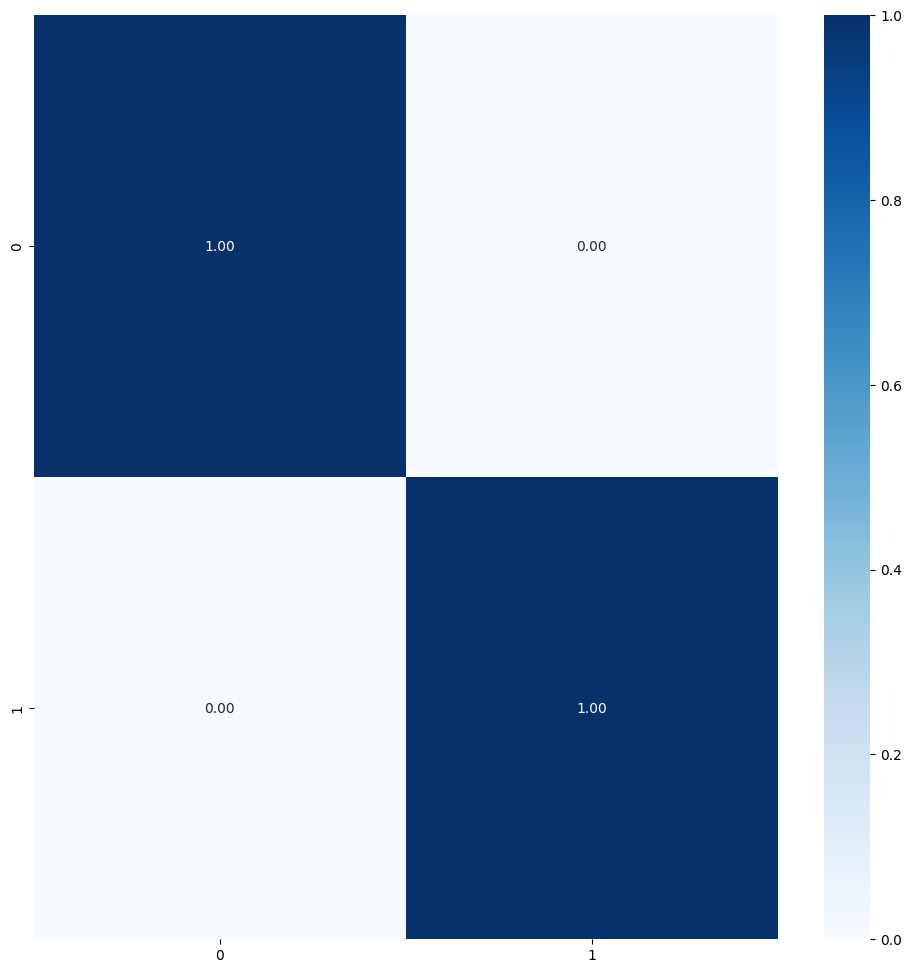


TRAINING AND EVALUATING FOLD 2/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
65/65 [==============================] - 7s 81ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 2/50
65/65 [==============================] - 4s 67ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 3/50
65/65 [==============================] - 4s 64ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 4/50
65/65 [==============================] - 4s 68ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 5/50
65/65 [==============================] - 5s 69ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 6/50
65/65 [==============================] - 5s 68ms/step - l

History for fold 2 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15002_2.pkl
66/66 [==============================] - 4s 53ms/step - loss: 0.1012 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.10119432955980301
15/15 [==============================] - 1s 52ms/step - loss: 0.1012 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.10124936699867249
15/15 [==============================] - 1s 51ms/step - loss: 0.1012 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.1011946052312851
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.

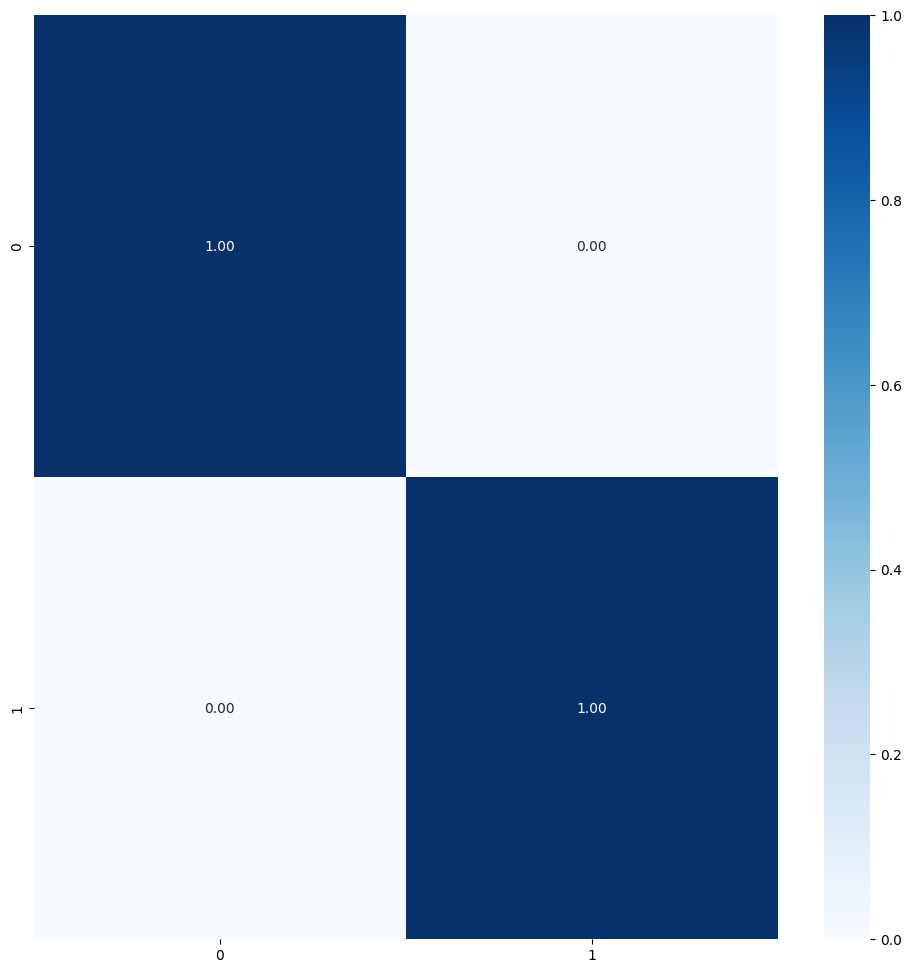


TRAINING AND EVALUATING FOLD 3/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
65/65 [==============================] - 7s 79ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 2/50
65/65 [==============================] - 5s 70ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 3/50
65/65 [==============================] - 4s 68ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 4/50
65/65 [==============================] - 5s 71ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 5/50
65/65 [==============================] - 4s 68ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 6/50
65/65 [==============================] - 4s 68ms/step - l

History for fold 3 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15002_3.pkl
66/66 [==============================] - 4s 52ms/step - loss: 0.1012 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.10119441151618958
15/15 [==============================] - 1s 53ms/step - loss: 0.1012 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.10123082995414734
15/15 [==============================] - 1s 53ms/step - loss: 0.1012 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.10119467228651047
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1

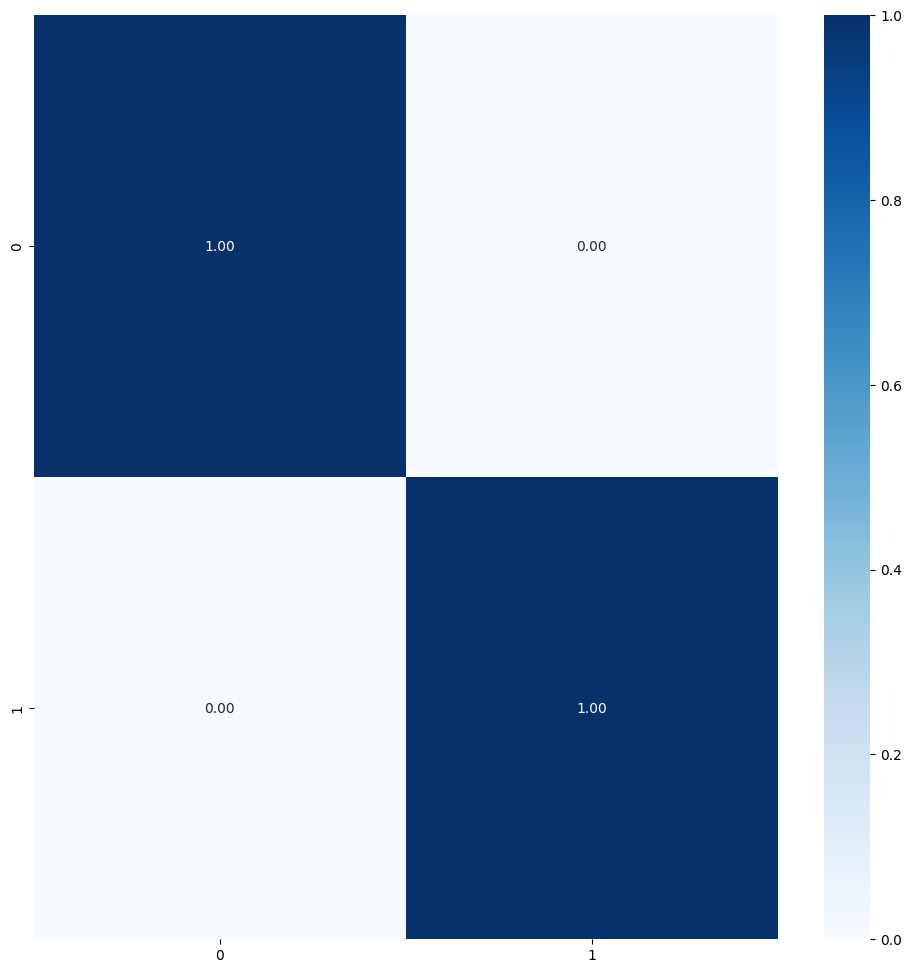


TRAINING AND EVALUATING FOLD 4/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
65/65 [==============================] - 7s 77ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 2/50
65/65 [==============================] - 4s 68ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 3/50
65/65 [==============================] - 5s 68ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 4/50
65/65 [==============================] - 5s 70ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 5/50
65/65 [==============================] - 4s 68ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 6/50
65/65 [==============================] - 5s 70ms/step - l

History for fold 4 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15002_4.pkl
66/66 [==============================] - 4s 57ms/step - loss: 0.1012 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.1011943370103836
15/15 [==============================] - 1s 49ms/step - loss: 0.1012 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.10121875256299973
15/15 [==============================] - 1s 50ms/step - loss: 0.1012 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.10119494050741196
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.

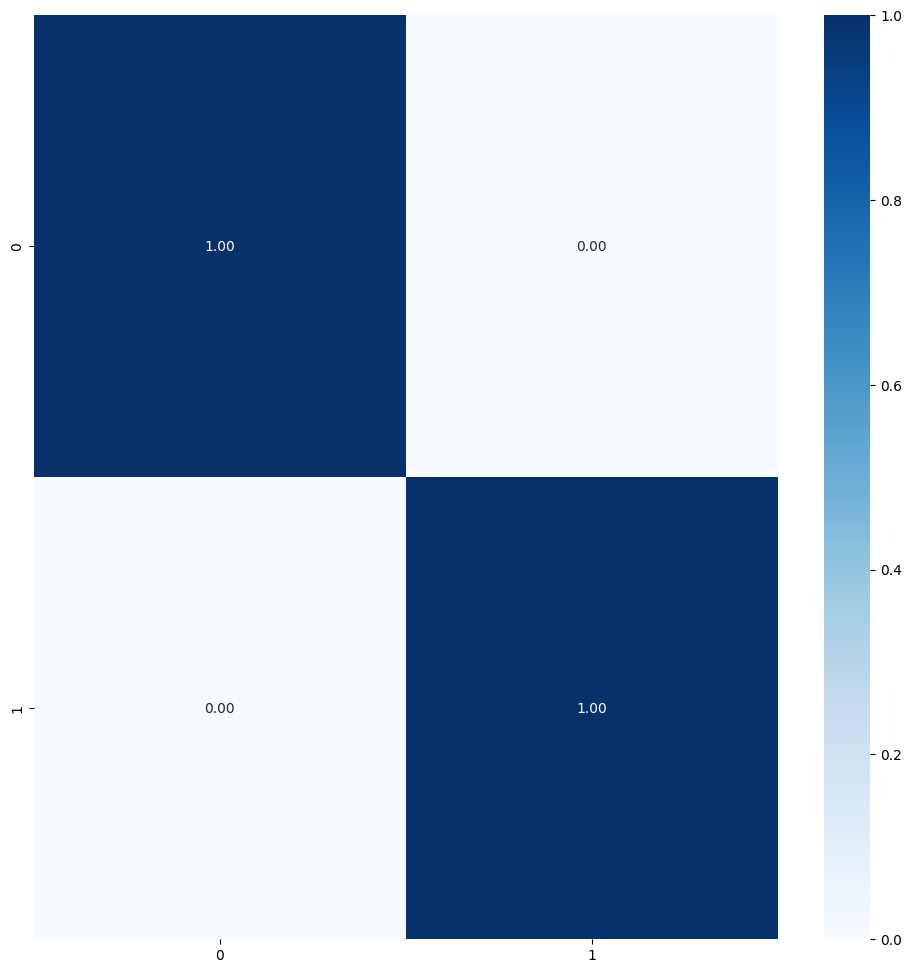


TRAINING AND EVALUATING FOLD 5/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
65/65 [==============================] - 7s 78ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 2/50
65/65 [==============================] - 5s 68ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 3/50
65/65 [==============================] - 5s 69ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 4/50
65/65 [==============================] - 4s 66ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 5/50
65/65 [==============================] - 4s 66ms/step - loss: 0.1012 - accuracy: 1.0000 - val_loss: 0.1012 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 6/50
65/65 [==============================] - 5s 69ms/step - l

History for fold 5 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15002_5.pkl
66/66 [==============================] - 4s 55ms/step - loss: 0.1012 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.10119412839412689
15/15 [==============================] - 1s 54ms/step - loss: 0.1012 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.10124006122350693
15/15 [==============================] - 1s 53ms/step - loss: 0.1012 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.10119427740573883
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1

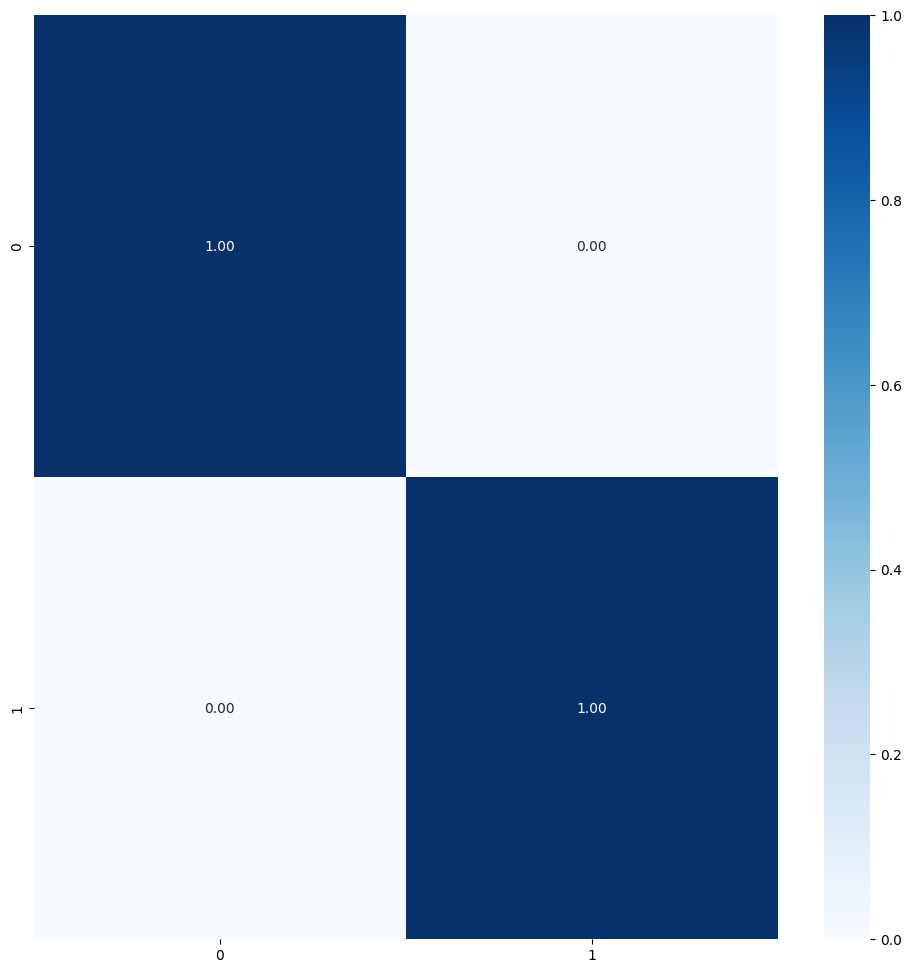


Best fold was 1 with val_accuracy: 1.0000
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 1.0

Test Metrics
test_acc_list: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Test Accuracy with 5-fold: 1.0
test_loss_list: [0.10119451582431793, 0.1011946052312851, 0.10119467228651047, 0.10119494050741196, 0.10119427740573883]
Average Test Log Loss with 5-fold: 0.10119460225105285

Precision List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Precision List with 5-fold: 1.0
Recall List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Recall List with 5-fold: 1.0
F1 Score List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average F1 Score List with 5-fold: 1.0

Metrics List Store

test_acc_list_all = [1.0]
test_loss_list_all = [0.10119460225105285]
precision_list_all = [1.0]
recall_list_all = [1.0]
f1_score_list_all = [1.0]
La carpeta 2 fue eliminada.
CPU times: user 35min 58s, sys: 1min 40s, total: 37min 39s
Wall time: 24min 37s


In [29]:
%%time

num_classes = 2
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/3
name_save_model: MobileNet_tf_15003
Found 3150 images belonging to 3 classes.
Found 675 images belonging to 3 classes.
Found 675 images belonging to 3 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15003_best.h5
Loading pre-trained model...
Model loaded successfully.

Calculating layer importance (once for all folds)...

Calculando importancia con 3150 muestras (100% confianza, ±0% error)
Incluyendo 93 capas (base + personalizadas)


100%|██████████| 3150/3150 [07:02<00:00,  7.45it/s]



Resultados de importancia de capas (incluyendo personalizadas):
----------------------------------------------------------------------
Pos.  | Nombre de Capa                           | Importancia    
----------------------------------------------------------------------
1     | conv_pw_1                                | 0.0000466
2     | conv_dw_1                                | 0.0000436
3     | conv_pw_3                                | 0.0000333
4     | conv_dw_1_bn                             | 0.0000298
5     | conv_pw_2                                | 0.0000203
6     | conv_dw_2_bn                             | 0.0000193
7     | conv_dw_3_bn                             | 0.0000187
8     | conv_dw_3                                | 0.0000156
9     | conv_pw_3_bn                             | 0.0000153
10    | conv1_bn                                 | 0.0000148
11    | conv_pw_1_bn                             | 0.0000144
12    | conv_dw_4_bn                             | 0.00

History for fold 1 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15003_1.pkl
99/99 [==============================] - 6s 58ms/step - loss: 0.0315 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.031537484377622604
22/22 [==============================] - 1s 60ms/step - loss: 0.0375 - accuracy: 0.9985
Validation Accuracy: 0.9985185265541077
Validation Log Loss: 0.03748038783669472
22/22 [==============================] - 1s 60ms/step - loss: 0.0315 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.03153898939490318
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                           

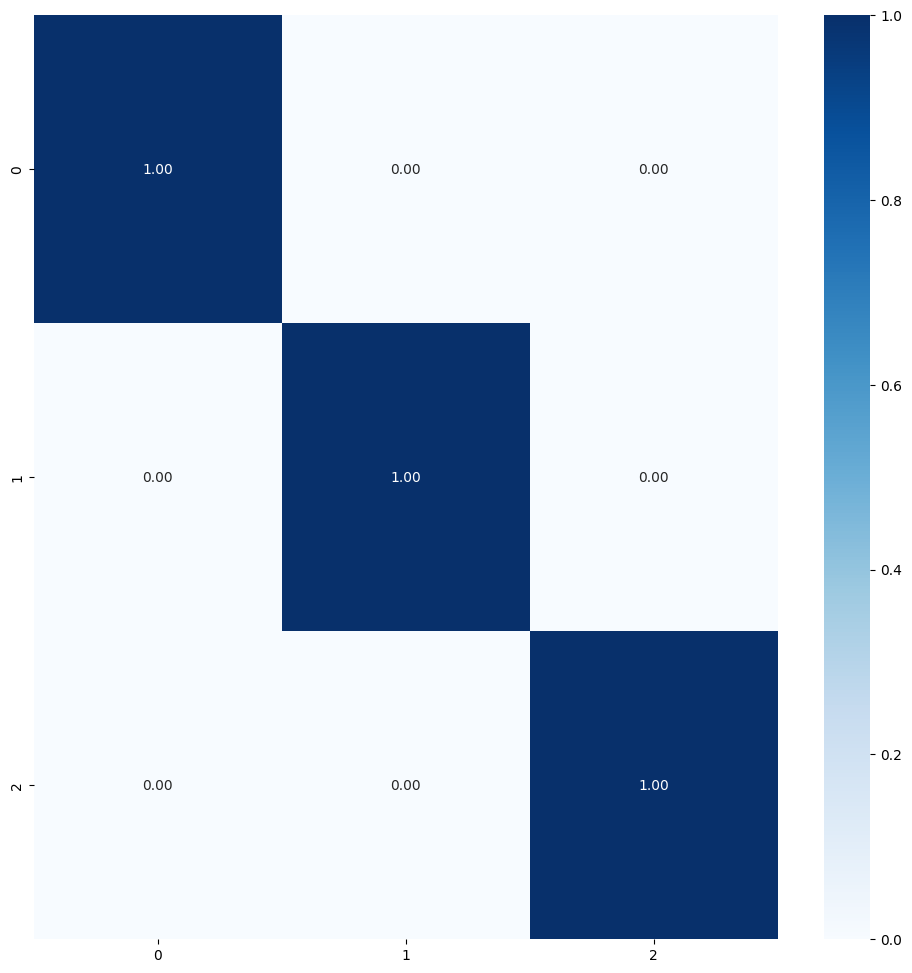


TRAINING AND EVALUATING FOLD 2/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
98/98 [==============================] - 9s 77ms/step - loss: 0.0316 - accuracy: 1.0000 - val_loss: 0.0371 - val_accuracy: 0.9985 - lr: 1.0000e-05
Epoch 2/50
98/98 [==============================] - 7s 67ms/step - loss: 0.0316 - accuracy: 1.0000 - val_loss: 0.0377 - val_accuracy: 0.9985 - lr: 1.0000e-05
Epoch 3/50
98/98 [==============================] - 7s 68ms/step - loss: 0.0315 - accuracy: 1.0000 - val_loss: 0.0372 - val_accuracy: 0.9985 - lr: 1.0000e-05
Epoch 4/50
98/98 [==============================] - 7s 71ms/step - loss: 0.0316 - accuracy: 1.0000 - val_loss: 0.0372 - val_accuracy: 0.9985 - lr: 1.0000e-05
Epoch 5/50
98/98 [==============================] - 7s 72ms/step - loss: 0.0315 - accuracy: 1.0000 - val_loss: 0.0359 - val_accuracy: 0.9985 - lr: 1.0000e-05
Epoch 6/50
98/98 [==============================] - 7s 70ms/step - l

History for fold 2 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15003_2.pkl
99/99 [==============================] - 6s 58ms/step - loss: 0.0315 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0315377376973629
22/22 [==============================] - 1s 57ms/step - loss: 0.0370 - accuracy: 0.9985
Validation Accuracy: 0.9985185265541077
Validation Log Loss: 0.037039704620838165
22/22 [==============================] - 1s 56ms/step - loss: 0.0315 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.031538669019937515
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                           

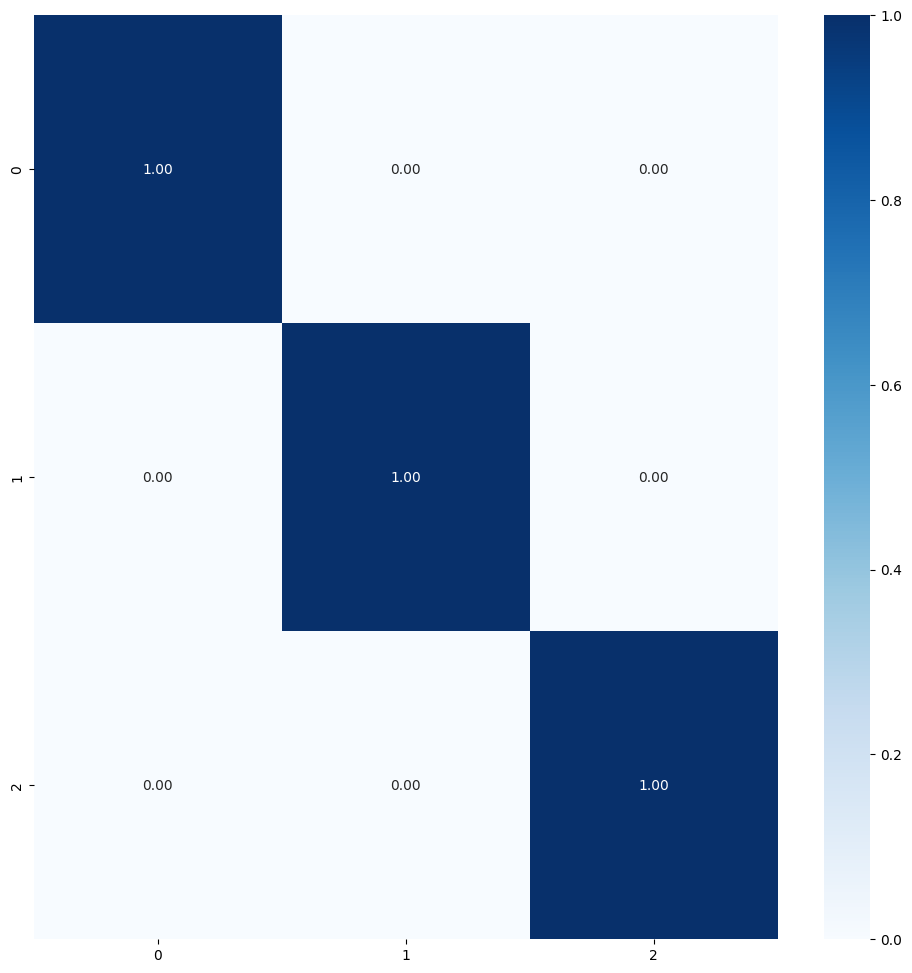


TRAINING AND EVALUATING FOLD 3/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
98/98 [==============================] - 10s 78ms/step - loss: 0.0316 - accuracy: 1.0000 - val_loss: 0.0372 - val_accuracy: 0.9985 - lr: 1.0000e-05
Epoch 2/50
98/98 [==============================] - 7s 69ms/step - loss: 0.0316 - accuracy: 1.0000 - val_loss: 0.0379 - val_accuracy: 0.9985 - lr: 1.0000e-05
Epoch 3/50
98/98 [==============================] - 7s 71ms/step - loss: 0.0315 - accuracy: 1.0000 - val_loss: 0.0381 - val_accuracy: 0.9985 - lr: 1.0000e-05
Epoch 4/50
98/98 [==============================] - 7s 68ms/step - loss: 0.0315 - accuracy: 1.0000 - val_loss: 0.0366 - val_accuracy: 0.9985 - lr: 1.0000e-05
Epoch 5/50
98/98 [==============================] - 7s 70ms/step - loss: 0.0315 - accuracy: 1.0000 - val_loss: 0.0374 - val_accuracy: 0.9985 - lr: 1.0000e-05
Epoch 6/50
98/98 [==============================] - 7s 71ms/step - 

History for fold 3 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15003_3.pkl
99/99 [==============================] - 5s 53ms/step - loss: 0.0315 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.03153778240084648
22/22 [==============================] - 1s 49ms/step - loss: 0.0375 - accuracy: 0.9985
Validation Accuracy: 0.9985185265541077
Validation Log Loss: 0.03751760348677635
22/22 [==============================] - 1s 55ms/step - loss: 0.0315 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.03153979405760765
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                           1

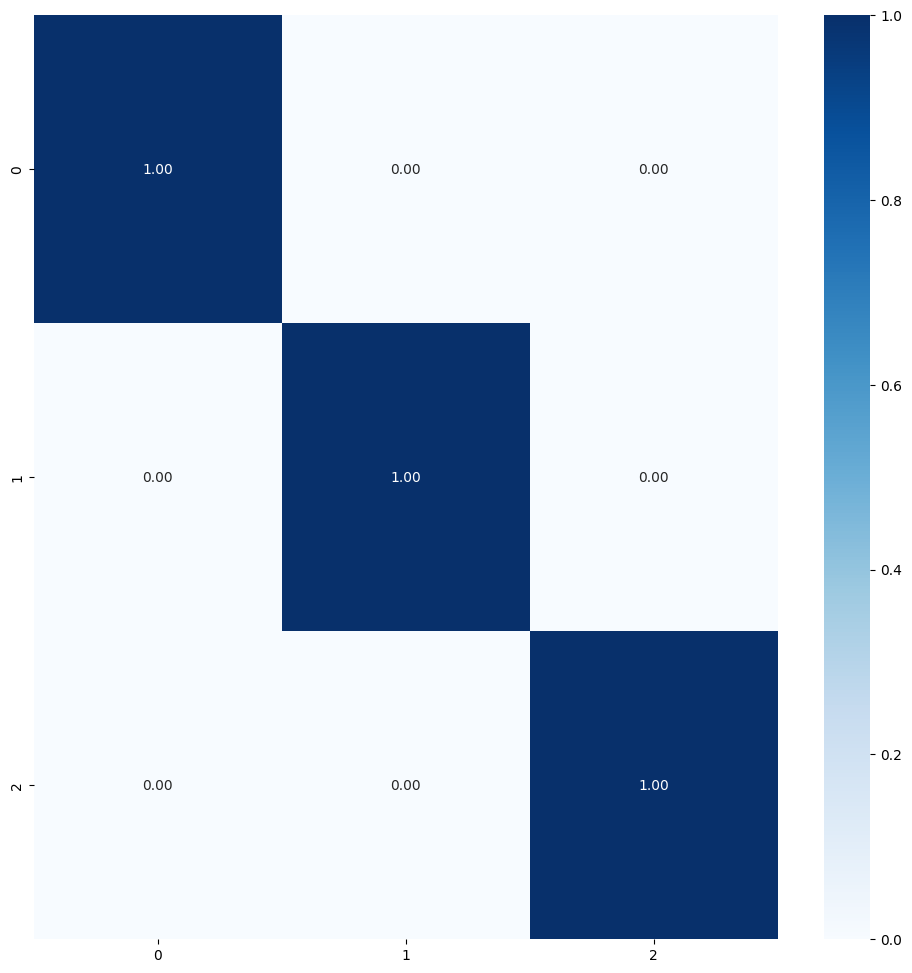


TRAINING AND EVALUATING FOLD 4/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
98/98 [==============================] - 10s 77ms/step - loss: 0.0316 - accuracy: 1.0000 - val_loss: 0.0364 - val_accuracy: 0.9985 - lr: 1.0000e-05
Epoch 2/50
98/98 [==============================] - 7s 69ms/step - loss: 0.0316 - accuracy: 1.0000 - val_loss: 0.0363 - val_accuracy: 0.9985 - lr: 1.0000e-05
Epoch 3/50
98/98 [==============================] - 7s 68ms/step - loss: 0.0316 - accuracy: 1.0000 - val_loss: 0.0376 - val_accuracy: 0.9985 - lr: 1.0000e-05
Epoch 4/50
98/98 [==============================] - 7s 68ms/step - loss: 0.0315 - accuracy: 1.0000 - val_loss: 0.0370 - val_accuracy: 0.9985 - lr: 1.0000e-05
Epoch 5/50
98/98 [==============================] - 7s 71ms/step - loss: 0.0315 - accuracy: 1.0000 - val_loss: 0.0377 - val_accuracy: 0.9985 - lr: 1.0000e-05
Epoch 6/50
98/98 [==============================] - 7s 70ms/step - 

History for fold 4 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15003_4.pkl
99/99 [==============================] - 6s 57ms/step - loss: 0.0315 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.03153783828020096
22/22 [==============================] - 1s 55ms/step - loss: 0.0366 - accuracy: 0.9985
Validation Accuracy: 0.9985185265541077
Validation Log Loss: 0.03658461570739746
22/22 [==============================] - 2s 76ms/step - loss: 0.0315 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.031538695096969604
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                           

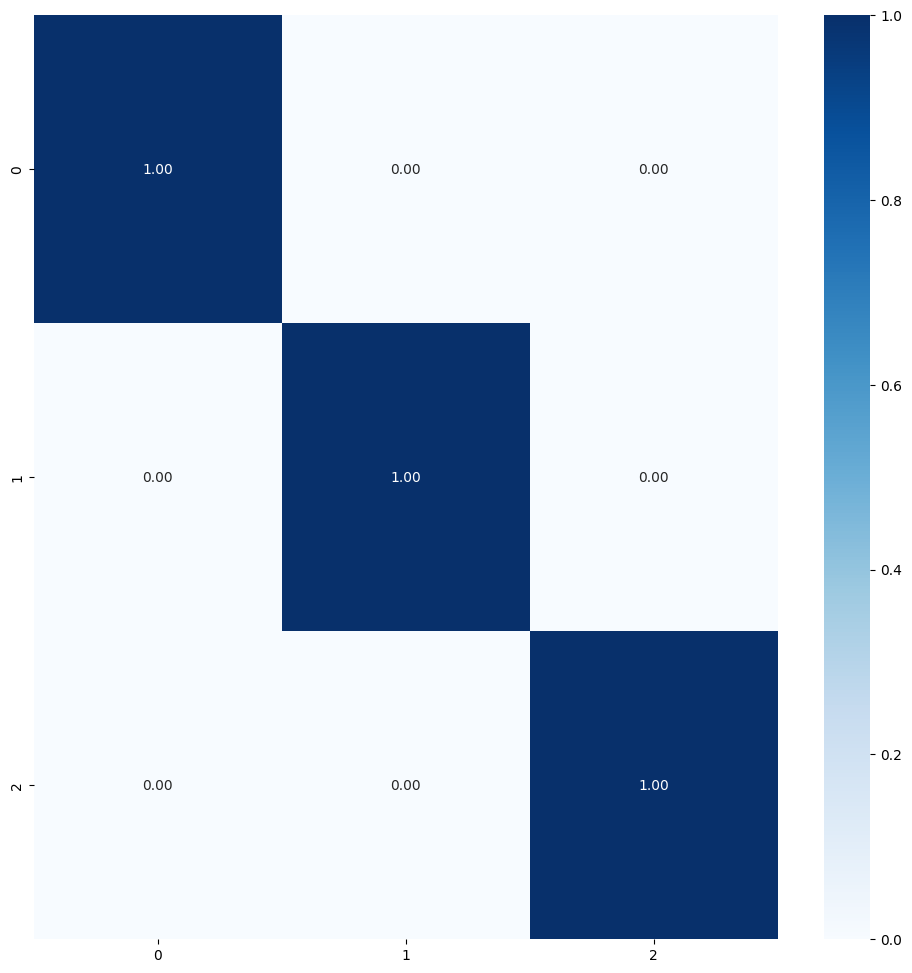


TRAINING AND EVALUATING FOLD 5/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
98/98 [==============================] - 10s 77ms/step - loss: 0.0316 - accuracy: 1.0000 - val_loss: 0.0351 - val_accuracy: 0.9985 - lr: 1.0000e-05
Epoch 2/50
98/98 [==============================] - 7s 68ms/step - loss: 0.0316 - accuracy: 1.0000 - val_loss: 0.0373 - val_accuracy: 0.9985 - lr: 1.0000e-05
Epoch 3/50
98/98 [==============================] - 7s 69ms/step - loss: 0.0316 - accuracy: 1.0000 - val_loss: 0.0372 - val_accuracy: 0.9985 - lr: 1.0000e-05
Epoch 4/50
98/98 [==============================] - 7s 74ms/step - loss: 0.0316 - accuracy: 1.0000 - val_loss: 0.0367 - val_accuracy: 0.9985 - lr: 1.0000e-05
Epoch 5/50
98/98 [==============================] - 7s 68ms/step - loss: 0.0315 - accuracy: 1.0000 - val_loss: 0.0377 - val_accuracy: 0.9985 - lr: 1.0000e-05
Epoch 6/50
98/98 [==============================] - 7s 70ms/step - 

History for fold 5 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15003_5.pkl
99/99 [==============================] - 6s 58ms/step - loss: 0.0315 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.03153783455491066
22/22 [==============================] - 1s 57ms/step - loss: 0.0370 - accuracy: 0.9985
Validation Accuracy: 0.9985185265541077
Validation Log Loss: 0.03698934614658356
22/22 [==============================] - 1s 51ms/step - loss: 0.0315 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.03153865784406662
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                           1

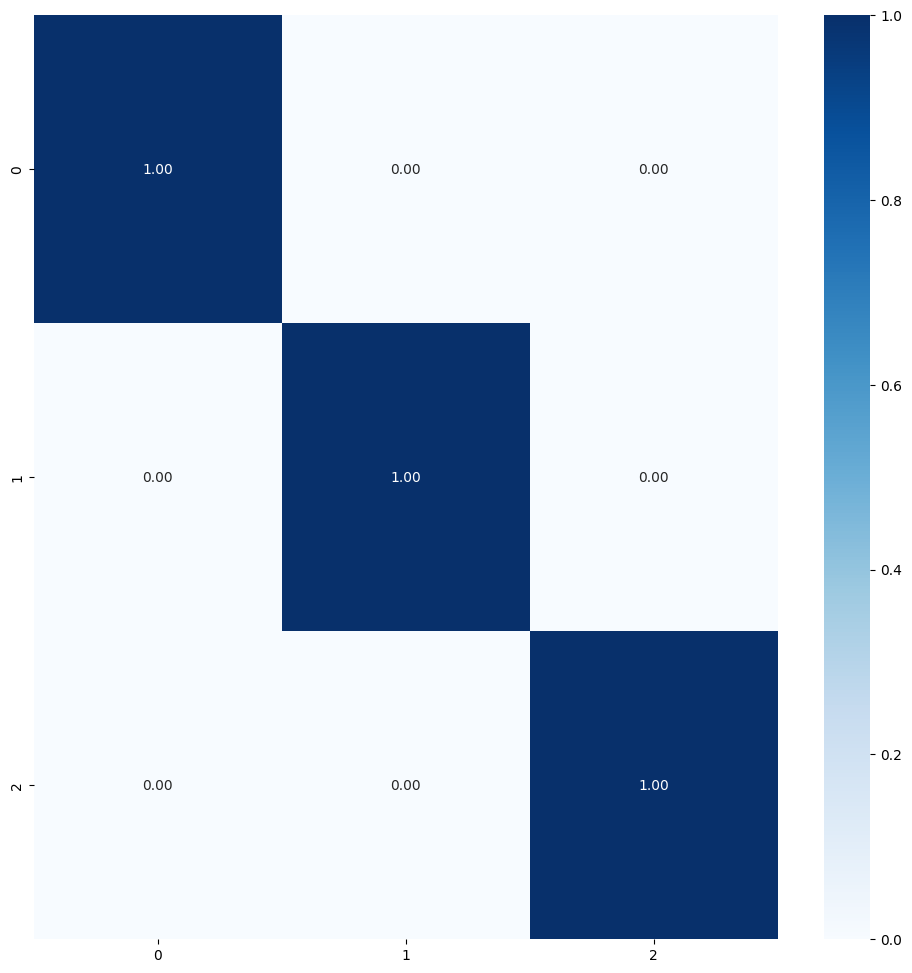


Best fold was 1 with val_accuracy: 0.9985
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.9985119104385376

Test Metrics
test_acc_list: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Test Accuracy with 5-fold: 1.0
test_loss_list: [0.03153898939490318, 0.031538669019937515, 0.03153979405760765, 0.031538695096969604, 0.03153865784406662]
Average Test Log Loss with 5-fold: 0.031538961082696916

Precision List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Precision List with 5-fold: 1.0
Recall List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Recall List with 5-fold: 1.0
F1 Score List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average F1 Score List with 5-fold: 1.0

Metrics List Store

test_acc_list_all = [1.0, 1.0]
test_loss_list_all = [0.10119460225105285, 0.031538961082696916]
precision_list_all = [1.0, 1.0]
recall_list_all = [1.0, 1.0]
f1_score_list_all = [1.0, 1.0]
La carpeta 3 fue eliminada.
CPU times: user 54min 26s, sys: 2min 28s, total: 56min 54s
Wall time: 37min 28s


In [30]:
%%time

num_classes = 3
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/4
name_save_model: MobileNet_tf_15004
Found 4200 images belonging to 4 classes.
Found 900 images belonging to 4 classes.
Found 900 images belonging to 4 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15004_best.h5
Loading pre-trained model...
Model loaded successfully.

Calculating layer importance (once for all folds)...

Calculando importancia con 4200 muestras (100% confianza, ±0% error)
Incluyendo 93 capas (base + personalizadas)


100%|██████████| 4200/4200 [09:16<00:00,  7.55it/s]



Resultados de importancia de capas (incluyendo personalizadas):
----------------------------------------------------------------------
Pos.  | Nombre de Capa                           | Importancia    
----------------------------------------------------------------------
1     | conv_pw_1                                | 0.0000518
2     | conv_dw_1                                | 0.0000503
3     | conv_pw_3                                | 0.0000386
4     | conv_dw_1_bn                             | 0.0000346
5     | conv_pw_2                                | 0.0000239
6     | conv_dw_2_bn                             | 0.0000226
7     | conv_dw_3_bn                             | 0.0000209
8     | conv1_bn                                 | 0.0000192
9     | conv_pw_3_bn                             | 0.0000182
10    | conv_pw_1_bn                             | 0.0000177
11    | conv_dw_3                                | 0.0000175
12    | conv_dw_4_bn                             | 0.00

History for fold 1 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15004_1.pkl
132/132 [==============================] - 8s 58ms/step - loss: 0.0185 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.018496807664632797
29/29 [==============================] - 2s 59ms/step - loss: 0.0445 - accuracy: 0.9967
Validation Accuracy: 0.996666669845581
Validation Log Loss: 0.04452428221702576
29/29 [==============================] - 2s 57ms/step - loss: 0.0372 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.0372462198138237
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 225   0   0]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      1.00       225
           2       1.00      1.00  

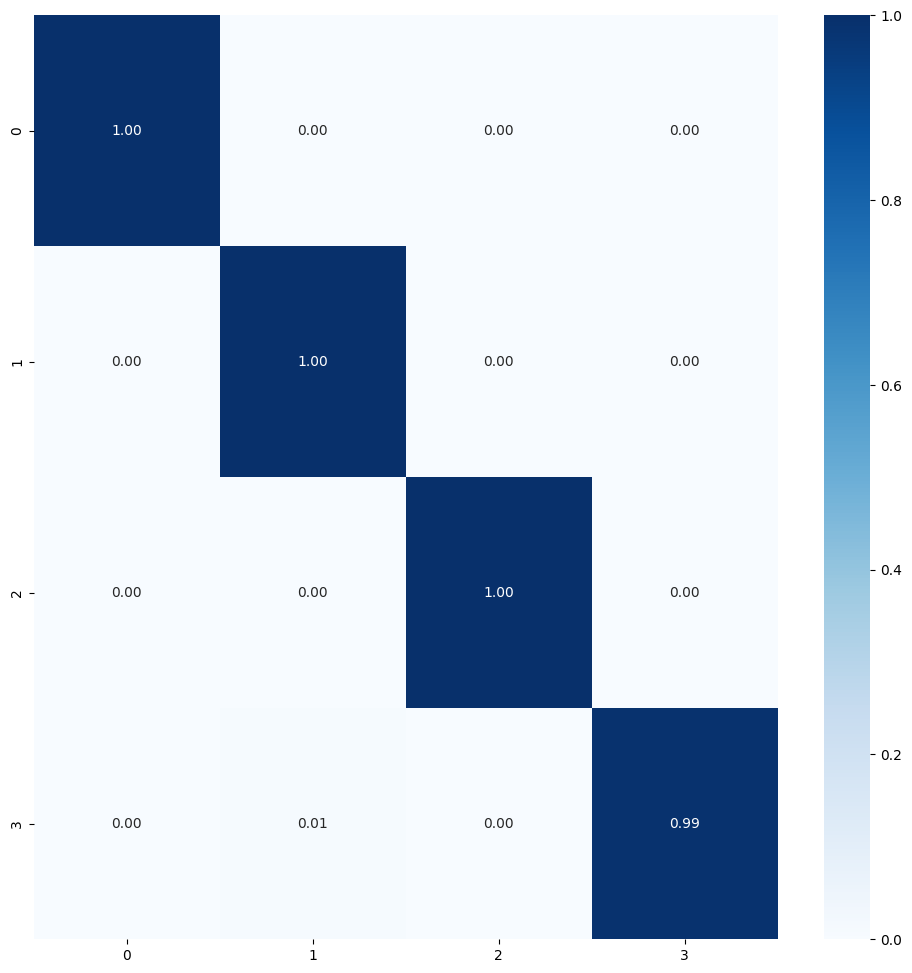


TRAINING AND EVALUATING FOLD 2/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
131/131 [==============================] - 12s 77ms/step - loss: 0.0185 - accuracy: 1.0000 - val_loss: 0.0431 - val_accuracy: 0.9967 - lr: 1.0000e-05
Epoch 2/50
131/131 [==============================] - 10s 74ms/step - loss: 0.0186 - accuracy: 1.0000 - val_loss: 0.0431 - val_accuracy: 0.9967 - lr: 1.0000e-05
Epoch 3/50
131/131 [==============================] - 9s 71ms/step - loss: 0.0185 - accuracy: 1.0000 - val_loss: 0.0427 - val_accuracy: 0.9967 - lr: 1.0000e-05
Epoch 4/50
131/131 [==============================] - 9s 70ms/step - loss: 0.0185 - accuracy: 1.0000 - val_loss: 0.0438 - val_accuracy: 0.9967 - lr: 1.0000e-05
Epoch 5/50
131/131 [==============================] - 9s 69ms/step - loss: 0.0185 - accuracy: 1.0000 - val_loss: 0.0430 - val_accuracy: 0.9967 - lr: 1.0000e-05
Epoch 6/50
131/131 [==============================] - 10

History for fold 2 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15004_2.pkl
132/132 [==============================] - 8s 59ms/step - loss: 0.0185 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.018496409058570862
29/29 [==============================] - 2s 59ms/step - loss: 0.0442 - accuracy: 0.9967
Validation Accuracy: 0.996666669845581
Validation Log Loss: 0.044151581823825836
29/29 [==============================] - 2s 59ms/step - loss: 0.0367 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.036671821027994156
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 225   0   0]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      1.00       225
           2       1.00      1.0

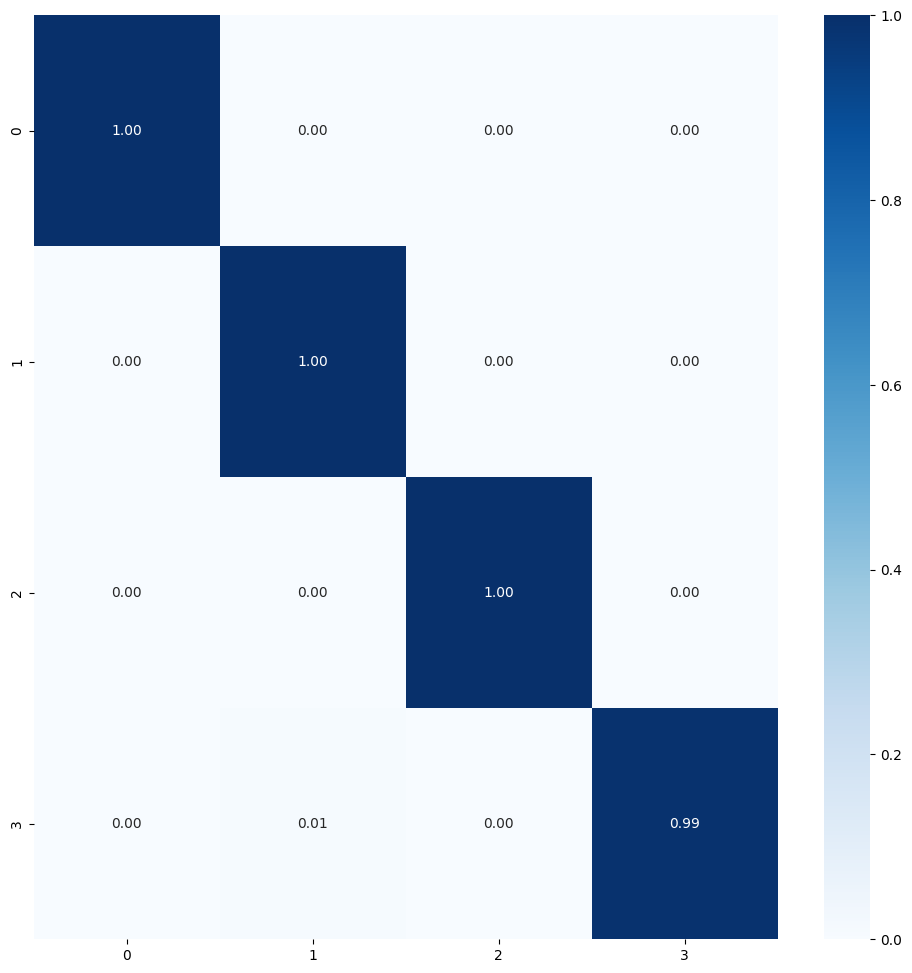


TRAINING AND EVALUATING FOLD 3/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
131/131 [==============================] - 12s 77ms/step - loss: 0.0186 - accuracy: 1.0000 - val_loss: 0.0436 - val_accuracy: 0.9967 - lr: 1.0000e-05
Epoch 2/50
131/131 [==============================] - 9s 71ms/step - loss: 0.0186 - accuracy: 1.0000 - val_loss: 0.0429 - val_accuracy: 0.9967 - lr: 1.0000e-05
Epoch 3/50
131/131 [==============================] - 9s 69ms/step - loss: 0.0185 - accuracy: 1.0000 - val_loss: 0.0434 - val_accuracy: 0.9967 - lr: 1.0000e-05
Epoch 4/50
131/131 [==============================] - 9s 70ms/step - loss: 0.0185 - accuracy: 1.0000 - val_loss: 0.0429 - val_accuracy: 0.9967 - lr: 1.0000e-05
Epoch 5/50
131/131 [==============================] - 9s 70ms/step - loss: 0.0185 - accuracy: 1.0000 - val_loss: 0.0434 - val_accuracy: 0.9967 - lr: 1.0000e-05
Epoch 6/50
131/131 [==============================] - 10s

History for fold 3 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15004_3.pkl
132/132 [==============================] - 7s 56ms/step - loss: 0.0185 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.01849604770541191
29/29 [==============================] - 2s 58ms/step - loss: 0.0441 - accuracy: 0.9967
Validation Accuracy: 0.996666669845581
Validation Log Loss: 0.0440804623067379
29/29 [==============================] - 2s 56ms/step - loss: 0.0374 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.037354953587055206
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 225   0   0]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      1.00       225
           2       1.00      1.00  

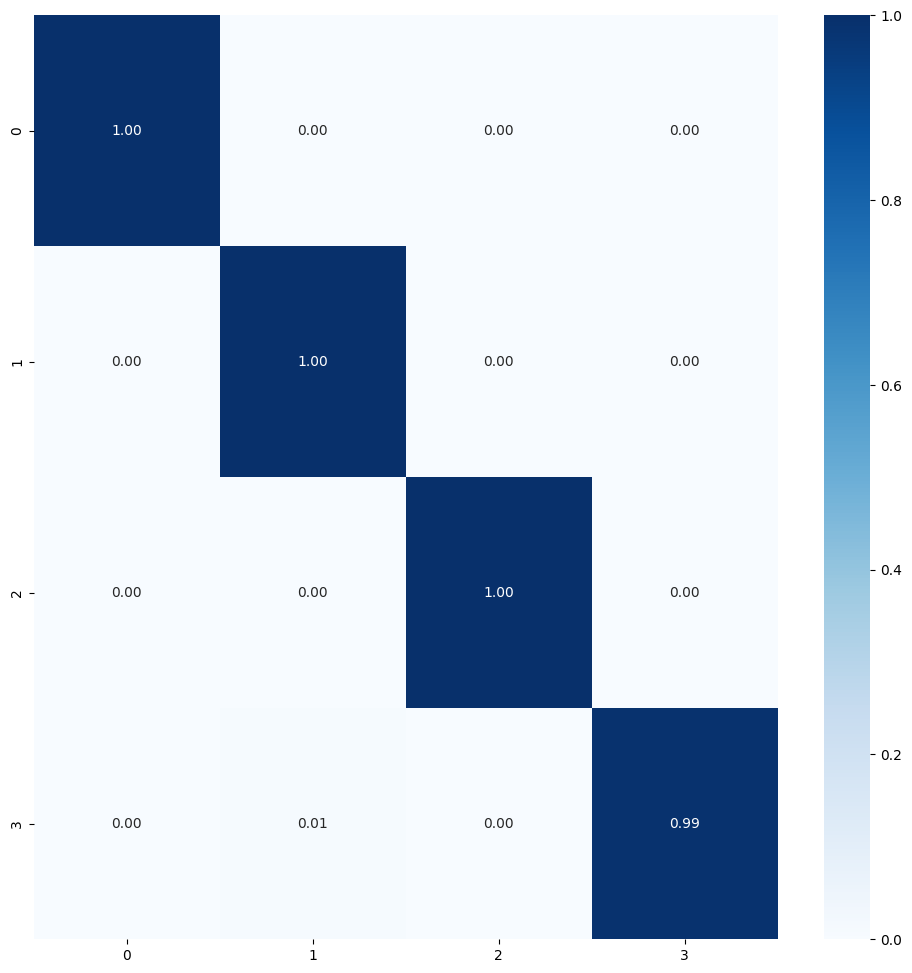


TRAINING AND EVALUATING FOLD 4/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
131/131 [==============================] - 12s 79ms/step - loss: 0.0186 - accuracy: 1.0000 - val_loss: 0.0426 - val_accuracy: 0.9967 - lr: 1.0000e-05
Epoch 2/50
131/131 [==============================] - 10s 77ms/step - loss: 0.0185 - accuracy: 1.0000 - val_loss: 0.0431 - val_accuracy: 0.9967 - lr: 1.0000e-05
Epoch 3/50
131/131 [==============================] - 9s 71ms/step - loss: 0.0185 - accuracy: 1.0000 - val_loss: 0.0431 - val_accuracy: 0.9967 - lr: 1.0000e-05
Epoch 4/50
131/131 [==============================] - 10s 76ms/step - loss: 0.0185 - accuracy: 1.0000 - val_loss: 0.0432 - val_accuracy: 0.9967 - lr: 1.0000e-05
Epoch 5/50
131/131 [==============================] - 9s 71ms/step - loss: 0.0185 - accuracy: 1.0000 - val_loss: 0.0443 - val_accuracy: 0.9967 - lr: 1.0000e-05
Epoch 6/50
131/131 [==============================] - 9

History for fold 4 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15004_4.pkl
132/132 [==============================] - 8s 58ms/step - loss: 0.0185 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.01849704049527645
29/29 [==============================] - 2s 58ms/step - loss: 0.0439 - accuracy: 0.9967
Validation Accuracy: 0.996666669845581
Validation Log Loss: 0.043908413499593735
29/29 [==============================] - 2s 57ms/step - loss: 0.0373 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.03732536733150482
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 225   0   0]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      1.00       225
           2       1.00      1.00 

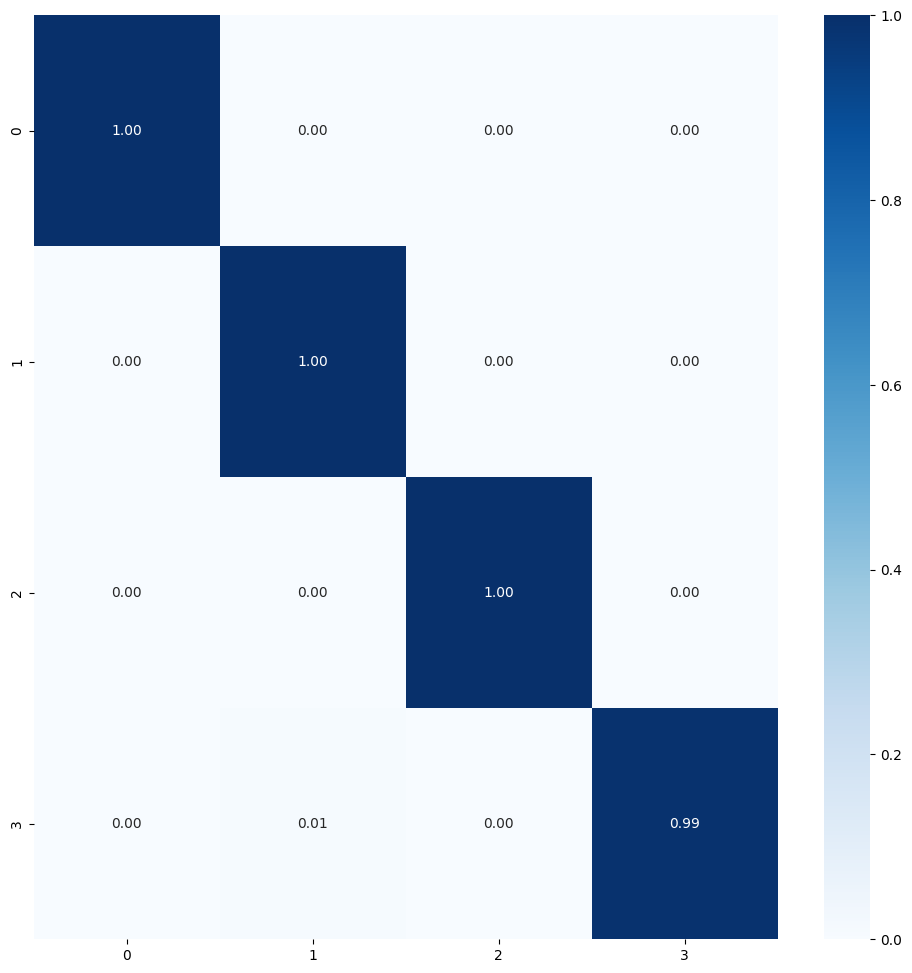


TRAINING AND EVALUATING FOLD 5/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
131/131 [==============================] - 12s 77ms/step - loss: 0.0186 - accuracy: 1.0000 - val_loss: 0.0435 - val_accuracy: 0.9967 - lr: 1.0000e-05
Epoch 2/50
131/131 [==============================] - 9s 70ms/step - loss: 0.0185 - accuracy: 1.0000 - val_loss: 0.0432 - val_accuracy: 0.9967 - lr: 1.0000e-05
Epoch 3/50
131/131 [==============================] - 9s 69ms/step - loss: 0.0185 - accuracy: 1.0000 - val_loss: 0.0431 - val_accuracy: 0.9967 - lr: 1.0000e-05
Epoch 4/50
131/131 [==============================] - 10s 76ms/step - loss: 0.0185 - accuracy: 1.0000 - val_loss: 0.0437 - val_accuracy: 0.9967 - lr: 1.0000e-05
Epoch 5/50
131/131 [==============================] - 9s 72ms/step - loss: 0.0185 - accuracy: 1.0000 - val_loss: 0.0444 - val_accuracy: 0.9967 - lr: 1.0000e-05
Epoch 6/50
131/131 [==============================] - 10

History for fold 5 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15004_5.pkl
132/132 [==============================] - 8s 60ms/step - loss: 0.0185 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.018497874960303307
29/29 [==============================] - 2s 59ms/step - loss: 0.0429 - accuracy: 0.9967
Validation Accuracy: 0.996666669845581
Validation Log Loss: 0.0428854376077652
29/29 [==============================] - 2s 55ms/step - loss: 0.0366 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.03658445179462433
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 225   0   0]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      1.00       225
           2       1.00      1.00  

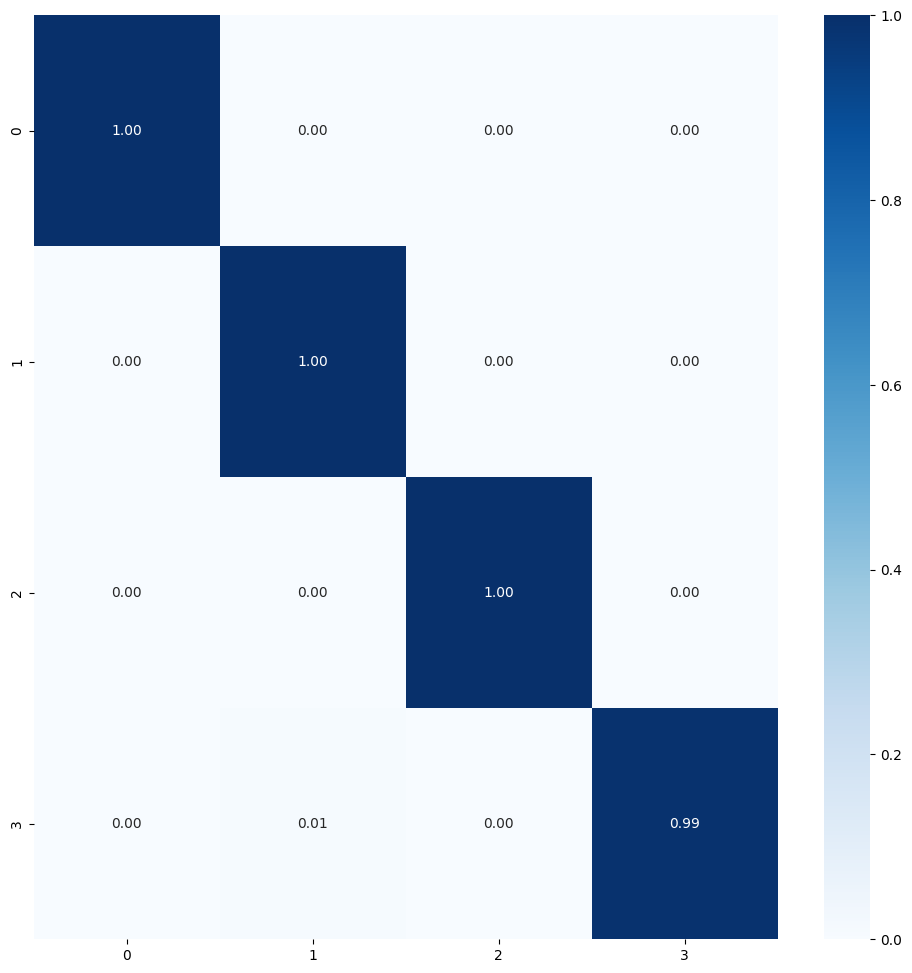


Best fold was 3 with val_accuracy: 0.9978
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.9970982074737549

Test Metrics
test_acc_list: [0.9977777600288391, 0.9977777600288391, 0.9977777600288391, 0.9977777600288391, 0.9977777600288391]
Average Test Accuracy with 5-fold: 0.9977777600288391
test_loss_list: [0.0372462198138237, 0.036671821027994156, 0.037354953587055206, 0.03732536733150482, 0.03658445179462433]
Average Test Log Loss with 5-fold: 0.03703656271100044

Precision List: [0.9977973568281938, 0.9977973568281938, 0.9977973568281938, 0.9977973568281938, 0.9977973568281938]
Average Precision List with 5-fold: 0.9977973568281937
Recall List: [0.9977777777777778, 0.9977777777777778, 0.9977777777777778, 0.9977777777777778, 0.9977777777777778]
Average Recall List with 5-fold: 0.9977777777777778
F1 Score List: [0.9977777338811631, 0.9977777338811631, 0.9977777338811631, 0.9977777338811631, 0.9977777338811631]
Average F1 Score List with 5-fold: 0.997

In [31]:
%%time

num_classes = 4
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/5
name_save_model: MobileNet_tf_15005
Found 5250 images belonging to 5 classes.
Found 1125 images belonging to 5 classes.
Found 1125 images belonging to 5 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15005_best.h5
Loading pre-trained model...
Model loaded successfully.

Calculating layer importance (once for all folds)...

Calculando importancia con 5250 muestras (100% confianza, ±0% error)
Incluyendo 93 capas (base + personalizadas)


100%|██████████| 5250/5250 [11:19<00:00,  7.73it/s]



Resultados de importancia de capas (incluyendo personalizadas):
----------------------------------------------------------------------
Pos.  | Nombre de Capa                           | Importancia    
----------------------------------------------------------------------
1     | conv_pw_1                                | 0.0951261
2     | conv_pw_3                                | 0.0856716
3     | conv_dw_1                                | 0.0690956
4     | conv_dw_1_bn                             | 0.0670038
5     | conv_dw_2_bn                             | 0.0468136
6     | conv_pw_3_bn                             | 0.0464843
7     | conv_pw_2                                | 0.0449725
8     | conv1_bn                                 | 0.0447459
9     | conv_dw_4_bn                             | 0.0442691
10    | conv_dw_3_bn                             | 0.0405267
11    | conv_pw_1_bn                             | 0.0403949
12    | conv_pw_4                                | 0.03

History for fold 1 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15005_1.pkl
165/165 [==============================] - 10s 61ms/step - loss: 0.1305 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.13045205175876617
36/36 [==============================] - 2s 61ms/step - loss: 0.1576 - accuracy: 0.9947
Validation Accuracy: 0.9946666955947876
Validation Log Loss: 0.15755876898765564
36/36 [==============================] - 2s 58ms/step - loss: 0.1632 - accuracy: 0.9947
Test Accuracy: 0.9946666955947876
Test Log Loss: 0.16319318115711212
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 224   0   1   0]
 [  0   0 224   0   1]
 [  0   2   0 223   0]
 [  0   1   1   0 223]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00  

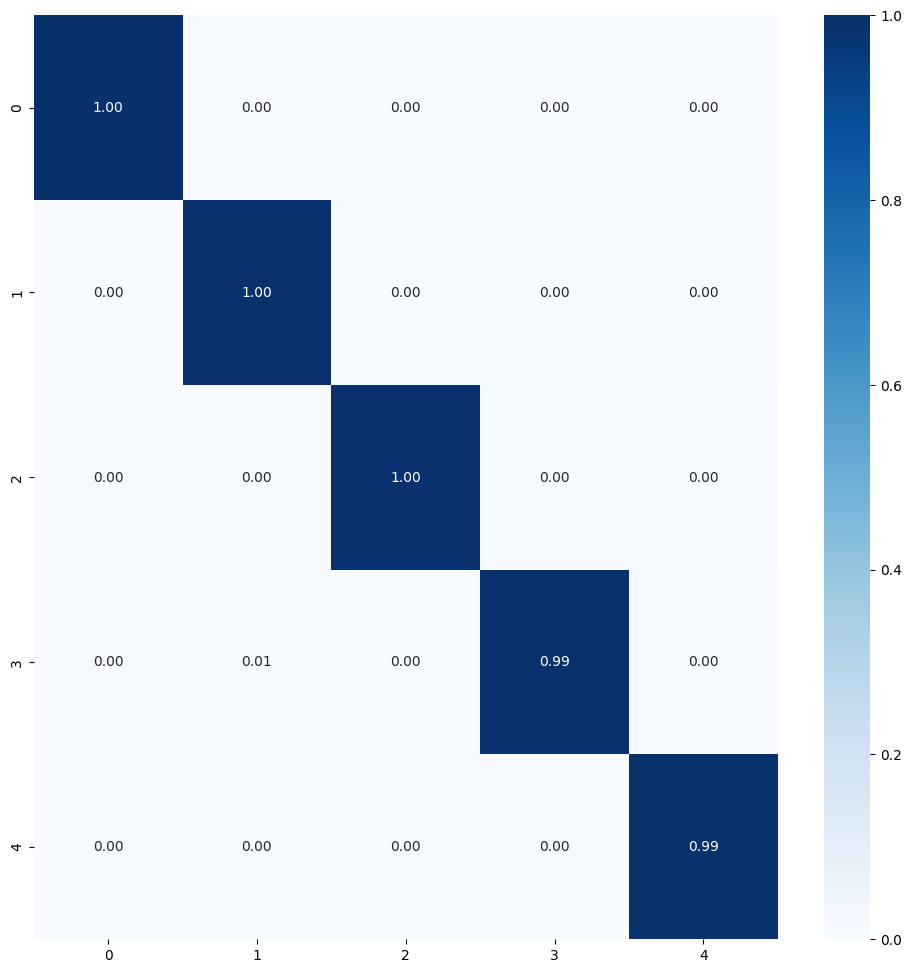


TRAINING AND EVALUATING FOLD 2/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
164/164 [==============================] - 14s 74ms/step - loss: 0.1327 - accuracy: 0.9996 - val_loss: 0.1496 - val_accuracy: 0.9964 - lr: 1.0000e-05
Epoch 2/50
164/164 [==============================] - 11s 70ms/step - loss: 0.1320 - accuracy: 0.9996 - val_loss: 0.1576 - val_accuracy: 0.9946 - lr: 1.0000e-05
Epoch 3/50
164/164 [==============================] - 12s 72ms/step - loss: 0.1336 - accuracy: 0.9990 - val_loss: 0.1572 - val_accuracy: 0.9964 - lr: 1.0000e-05
Epoch 4/50
164/164 [==============================] - 12s 74ms/step - loss: 0.1384 - accuracy: 0.9975 - val_loss: 0.1567 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 5/50
164/164 [==============================] - 12s 73ms/step - loss: 0.1315 - accuracy: 0.9998 - val_loss: 0.1571 - val_accuracy: 0.9946 - lr: 1.0000e-05
Epoch 6/50
164/164 [==============================] -

History for fold 2 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15005_2.pkl
165/165 [==============================] - 10s 61ms/step - loss: 0.1305 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.13046085834503174
36/36 [==============================] - 2s 61ms/step - loss: 0.1578 - accuracy: 0.9947
Validation Accuracy: 0.9946666955947876
Validation Log Loss: 0.1578318327665329
36/36 [==============================] - 2s 60ms/step - loss: 0.1635 - accuracy: 0.9947
Test Accuracy: 0.9946666955947876
Test Log Loss: 0.16349154710769653
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 224   0   1   0]
 [  0   0 224   0   1]
 [  0   2   0 223   0]
 [  0   1   1   0 223]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00   

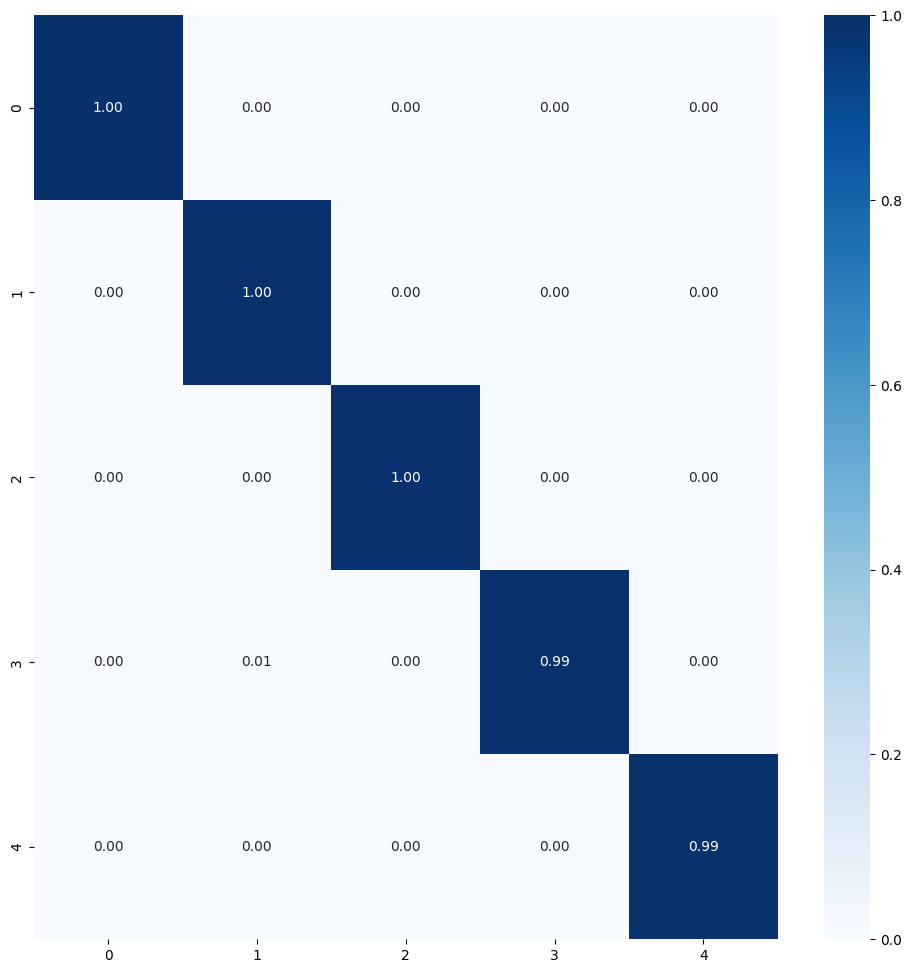


TRAINING AND EVALUATING FOLD 3/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
164/164 [==============================] - 15s 78ms/step - loss: 0.1340 - accuracy: 0.9990 - val_loss: 0.1583 - val_accuracy: 0.9946 - lr: 1.0000e-05
Epoch 2/50
164/164 [==============================] - 12s 74ms/step - loss: 0.1335 - accuracy: 0.9992 - val_loss: 0.1600 - val_accuracy: 0.9937 - lr: 1.0000e-05
Epoch 3/50
164/164 [==============================] - 11s 68ms/step - loss: 0.1321 - accuracy: 0.9994 - val_loss: 0.1585 - val_accuracy: 0.9946 - lr: 1.0000e-05
Epoch 4/50
164/164 [==============================] - 11s 68ms/step - loss: 0.1321 - accuracy: 0.9994 - val_loss: 0.1575 - val_accuracy: 0.9946 - lr: 1.0000e-05
Epoch 5/50
164/164 [==============================] - 12s 73ms/step - loss: 0.1314 - accuracy: 1.0000 - val_loss: 0.1573 - val_accuracy: 0.9946 - lr: 1.0000e-05
Epoch 6/50
164/164 [==============================] -

History for fold 3 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15005_3.pkl
165/165 [==============================] - 10s 57ms/step - loss: 0.1305 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.13046398758888245
36/36 [==============================] - 2s 60ms/step - loss: 0.1562 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.1562112718820572
36/36 [==============================] - 2s 60ms/step - loss: 0.1652 - accuracy: 0.9947
Test Accuracy: 0.9946666955947876
Test Log Loss: 0.16515164077281952
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 224   0   1   0]
 [  0   0 224   0   1]
 [  0   2   0 223   0]
 [  0   1   1   0 223]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00    

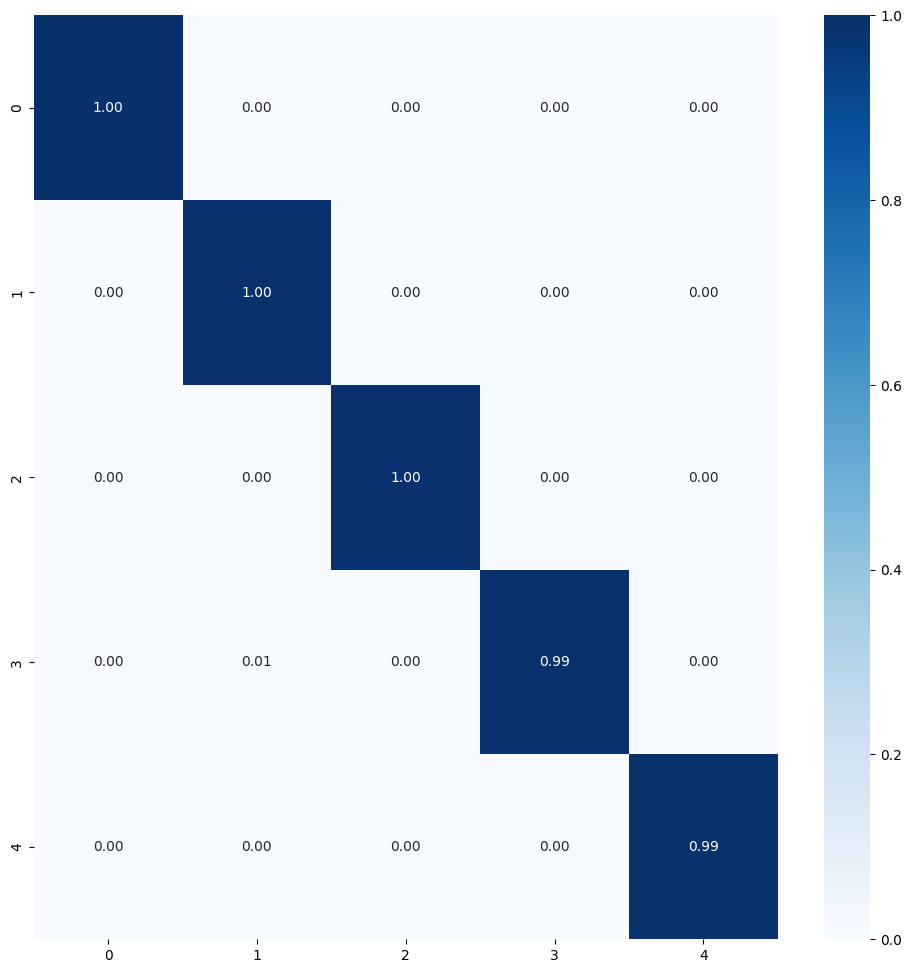


TRAINING AND EVALUATING FOLD 4/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
164/164 [==============================] - 15s 80ms/step - loss: 0.1383 - accuracy: 0.9973 - val_loss: 0.1574 - val_accuracy: 0.9946 - lr: 1.0000e-05
Epoch 2/50
164/164 [==============================] - 12s 72ms/step - loss: 0.1320 - accuracy: 1.0000 - val_loss: 0.1576 - val_accuracy: 0.9946 - lr: 1.0000e-05
Epoch 3/50
164/164 [==============================] - 12s 72ms/step - loss: 0.1314 - accuracy: 0.9998 - val_loss: 0.1572 - val_accuracy: 0.9946 - lr: 1.0000e-05
Epoch 4/50
164/164 [==============================] - 11s 67ms/step - loss: 0.1315 - accuracy: 1.0000 - val_loss: 0.1566 - val_accuracy: 0.9946 - lr: 1.0000e-05
Epoch 5/50
164/164 [==============================] - 12s 71ms/step - loss: 0.1312 - accuracy: 1.0000 - val_loss: 0.1571 - val_accuracy: 0.9946 - lr: 1.0000e-05
Epoch 6/50
164/164 [==============================] -

History for fold 4 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15005_4.pkl
165/165 [==============================] - 10s 59ms/step - loss: 0.1305 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.13046684861183167
36/36 [==============================] - 2s 55ms/step - loss: 0.1571 - accuracy: 0.9947
Validation Accuracy: 0.9946666955947876
Validation Log Loss: 0.1571350395679474
36/36 [==============================] - 2s 60ms/step - loss: 0.1637 - accuracy: 0.9947
Test Accuracy: 0.9946666955947876
Test Log Loss: 0.163710817694664
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 224   0   1   0]
 [  0   0 224   0   1]
 [  0   2   0 223   0]
 [  0   1   1   0 223]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00     

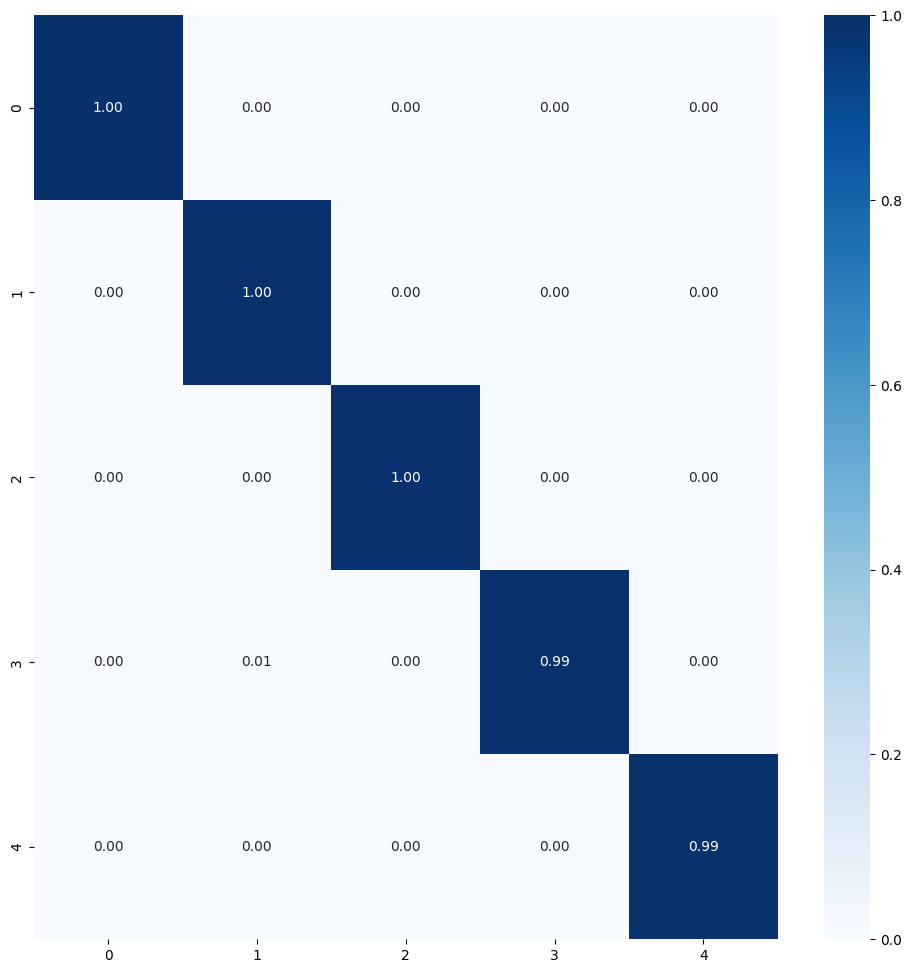


TRAINING AND EVALUATING FOLD 5/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
164/164 [==============================] - 15s 77ms/step - loss: 0.1347 - accuracy: 0.9987 - val_loss: 0.1574 - val_accuracy: 0.9946 - lr: 1.0000e-05
Epoch 2/50
164/164 [==============================] - 12s 72ms/step - loss: 0.1319 - accuracy: 0.9998 - val_loss: 0.1574 - val_accuracy: 0.9946 - lr: 1.0000e-05
Epoch 3/50
164/164 [==============================] - 12s 70ms/step - loss: 0.1318 - accuracy: 0.9998 - val_loss: 0.1584 - val_accuracy: 0.9946 - lr: 1.0000e-05
Epoch 4/50
164/164 [==============================] - 12s 74ms/step - loss: 0.1327 - accuracy: 0.9992 - val_loss: 0.1562 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 5/50
164/164 [==============================] - 12s 72ms/step - loss: 0.1321 - accuracy: 0.9994 - val_loss: 0.1571 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 6/50
164/164 [==============================] -

History for fold 5 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15005_5.pkl
165/165 [==============================] - 10s 59ms/step - loss: 0.1304 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.13044321537017822
36/36 [==============================] - 2s 61ms/step - loss: 0.1579 - accuracy: 0.9938
Validation Accuracy: 0.9937777519226074
Validation Log Loss: 0.15794061124324799
36/36 [==============================] - 2s 60ms/step - loss: 0.1629 - accuracy: 0.9947
Test Accuracy: 0.9946666955947876
Test Log Loss: 0.16286835074424744
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 224   0   1   0]
 [  0   0 224   0   1]
 [  0   2   0 223   0]
 [  0   1   1   0 223]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00  

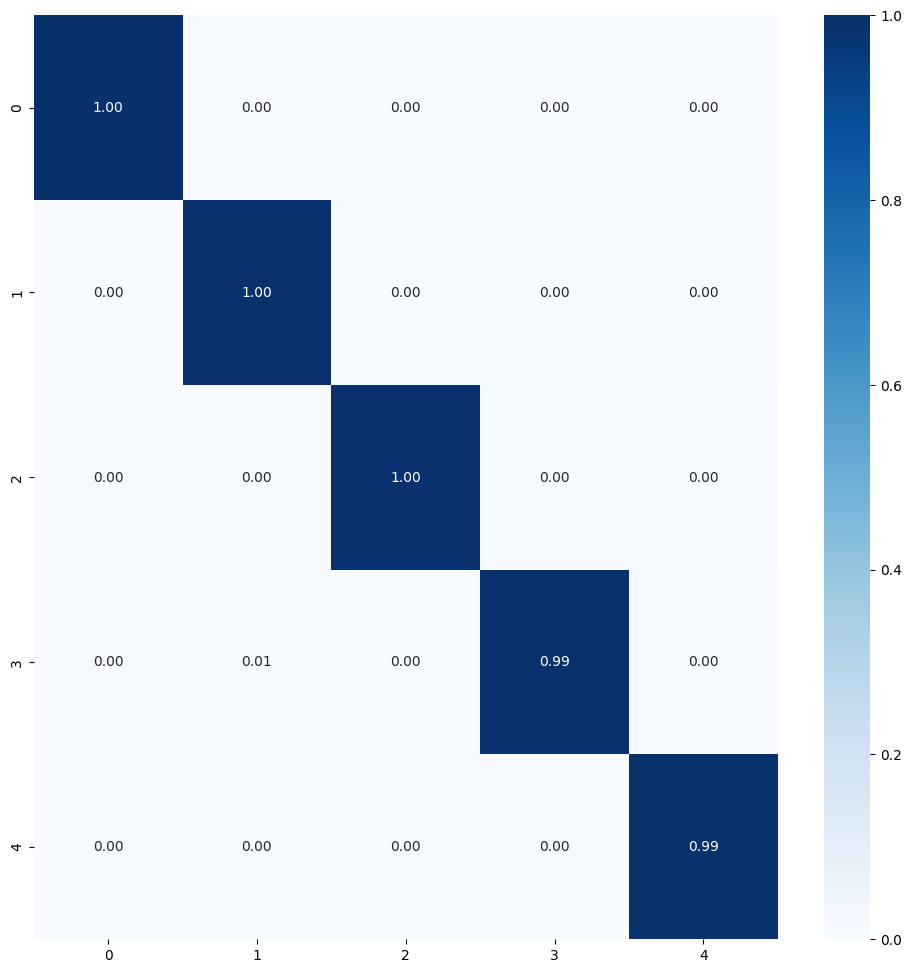


Best fold was 2 with val_accuracy: 0.9964
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.995892858505249

Test Metrics
test_acc_list: [0.9946666955947876, 0.9946666955947876, 0.9946666955947876, 0.9946666955947876, 0.9946666955947876]
Average Test Accuracy with 5-fold: 0.9946666955947876
test_loss_list: [0.16319318115711212, 0.16349154710769653, 0.16515164077281952, 0.163710817694664, 0.16286835074424744]
Average Test Log Loss with 5-fold: 0.16368310749530793

Precision List: [0.9946822250192294, 0.9946822250192294, 0.9946822250192294, 0.9946822250192294, 0.9946822250192294]
Average Precision List with 5-fold: 0.9946822250192294
Recall List: [0.9946666666666667, 0.9946666666666667, 0.9946666666666667, 0.9946666666666667, 0.9946666666666667]
Average Recall List with 5-fold: 0.9946666666666667
F1 Score List: [0.9946685938160404, 0.9946685938160404, 0.9946685938160404, 0.9946685938160404, 0.9946685938160404]
Average F1 Score List with 5-fold: 0.9946685

In [32]:
%%time

num_classes = 5
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/6
name_save_model: MobileNet_tf_15006
Found 6300 images belonging to 6 classes.
Found 1350 images belonging to 6 classes.
Found 1350 images belonging to 6 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15006_best.h5
Loading pre-trained model...
Model loaded successfully.

Calculating layer importance (once for all folds)...

Calculando importancia con 6300 muestras (100% confianza, ±0% error)
Incluyendo 93 capas (base + personalizadas)


100%|██████████| 6300/6300 [14:02<00:00,  7.48it/s]



Resultados de importancia de capas (incluyendo personalizadas):
----------------------------------------------------------------------
Pos.  | Nombre de Capa                           | Importancia    
----------------------------------------------------------------------
1     | conv_pw_1                                | 0.0261496
2     | conv_dw_1                                | 0.0233169
3     | conv_pw_3                                | 0.0231685
4     | conv_dw_1_bn                             | 0.0180338
5     | conv_dw_2_bn                             | 0.0128415
6     | conv_pw_2                                | 0.0128342
7     | conv_pw_3_bn                             | 0.0117803
8     | conv_dw_3_bn                             | 0.0109534
9     | conv_dw_4_bn                             | 0.0107876
10    | conv1_bn                                 | 0.0103366
11    | conv_pw_1_bn                             | 0.0101895
12    | conv_pw_4                                | 0.00

History for fold 1 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15006_1.pkl
197/197 [==============================] - 12s 61ms/step - loss: 0.0222 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.02217022515833378
43/43 [==============================] - 3s 61ms/step - loss: 0.0534 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.05340190604329109
43/43 [==============================] - 3s 59ms/step - loss: 0.0677 - accuracy: 0.9941
Test Accuracy: 0.9940740466117859
Test Log Loss: 0.06766575574874878
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 223   2   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0   0 224   0   1]
 [  0   2   0   0 223   0]
 [  0   1   0   2   0 222]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.0

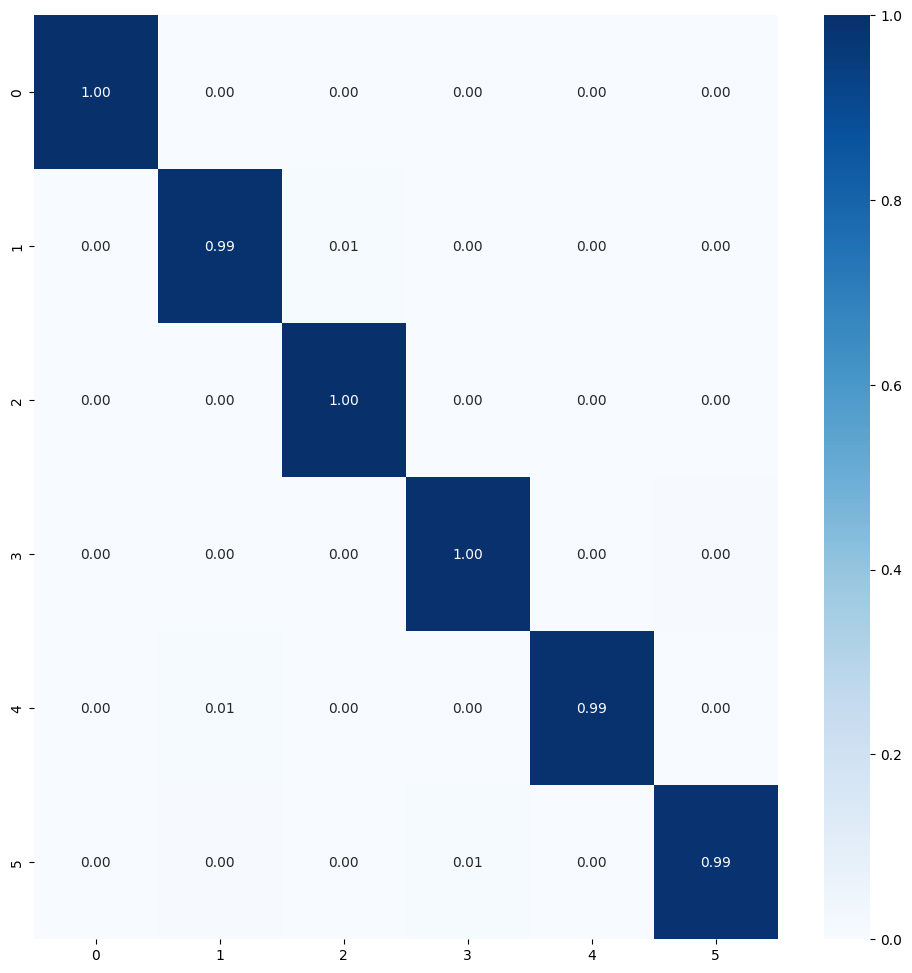


TRAINING AND EVALUATING FOLD 2/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
196/196 [==============================] - 17s 78ms/step - loss: 0.0246 - accuracy: 0.9997 - val_loss: 0.0531 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 2/50
196/196 [==============================] - 15s 74ms/step - loss: 0.0247 - accuracy: 0.9994 - val_loss: 0.0524 - val_accuracy: 0.9948 - lr: 1.0000e-05
Epoch 3/50
196/196 [==============================] - 15s 74ms/step - loss: 0.0244 - accuracy: 0.9995 - val_loss: 0.0525 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 4/50
196/196 [==============================] - 14s 74ms/step - loss: 0.0235 - accuracy: 0.9998 - val_loss: 0.0523 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 5/50
196/196 [==============================] - 14s 71ms/step - loss: 0.0229 - accuracy: 1.0000 - val_loss: 0.0525 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 6/50
196/196 [==============================] -

History for fold 2 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15006_2.pkl
197/197 [==============================] - 12s 60ms/step - loss: 0.0222 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.02215934358537197
43/43 [==============================] - 2s 55ms/step - loss: 0.0540 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.05395481362938881
43/43 [==============================] - 3s 59ms/step - loss: 0.0661 - accuracy: 0.9941
Test Accuracy: 0.9940740466117859
Test Log Loss: 0.06610962748527527
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 223   2   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0   0 224   0   1]
 [  0   2   0   0 223   0]
 [  0   1   0   2   0 222]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.0

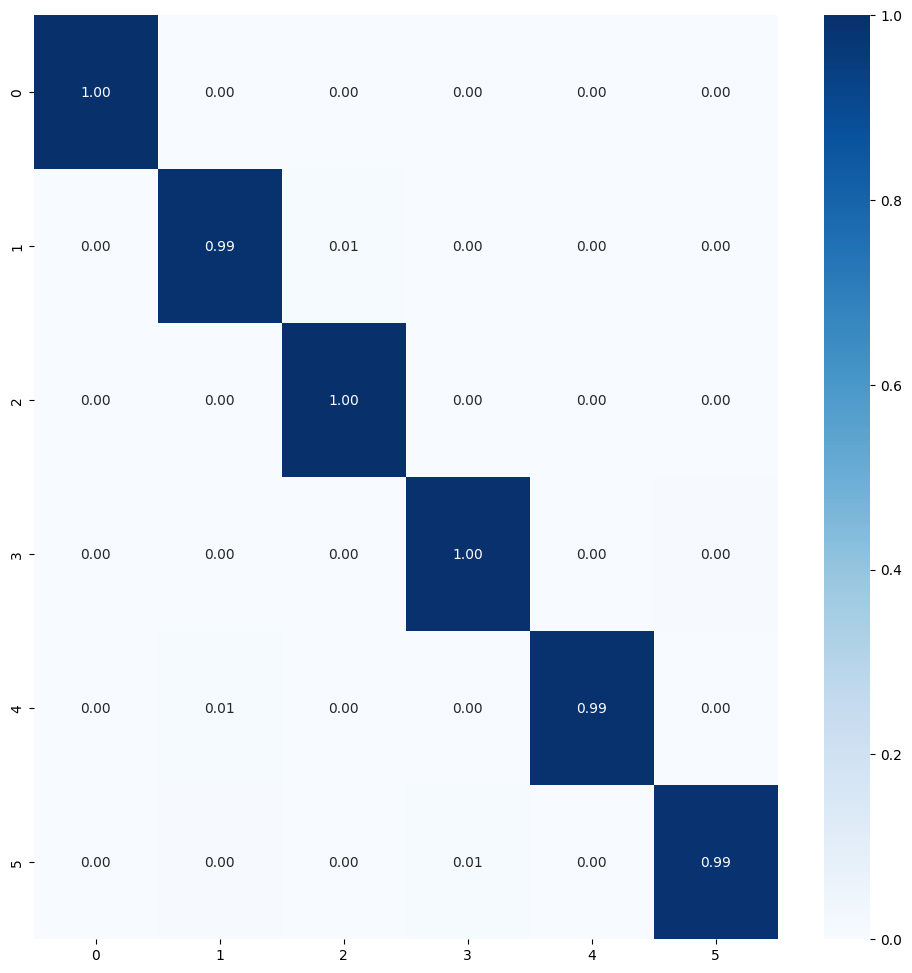


TRAINING AND EVALUATING FOLD 3/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
196/196 [==============================] - 16s 72ms/step - loss: 0.0246 - accuracy: 0.9997 - val_loss: 0.0557 - val_accuracy: 0.9940 - lr: 1.0000e-05
Epoch 2/50
196/196 [==============================] - 13s 66ms/step - loss: 0.0287 - accuracy: 0.9979 - val_loss: 0.0603 - val_accuracy: 0.9918 - lr: 1.0000e-05
Epoch 3/50
196/196 [==============================] - 15s 74ms/step - loss: 0.0244 - accuracy: 0.9995 - val_loss: 0.0532 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 4/50
196/196 [==============================] - 14s 74ms/step - loss: 0.0238 - accuracy: 0.9997 - val_loss: 0.0534 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 5/50
196/196 [==============================] - 14s 73ms/step - loss: 0.0232 - accuracy: 0.9998 - val_loss: 0.0503 - val_accuracy: 0.9963 - lr: 1.0000e-05
Epoch 6/50
196/196 [==============================] -

History for fold 3 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15006_3.pkl
197/197 [==============================] - 12s 62ms/step - loss: 0.0221 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.022144494578242302
43/43 [==============================] - 3s 61ms/step - loss: 0.0531 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.05305960029363632
43/43 [==============================] - 3s 61ms/step - loss: 0.0670 - accuracy: 0.9941
Test Accuracy: 0.9940740466117859
Test Log Loss: 0.06703996658325195
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 223   2   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0   0 224   0   1]
 [  0   2   0   0 223   0]
 [  0   1   0   2   0 222]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.

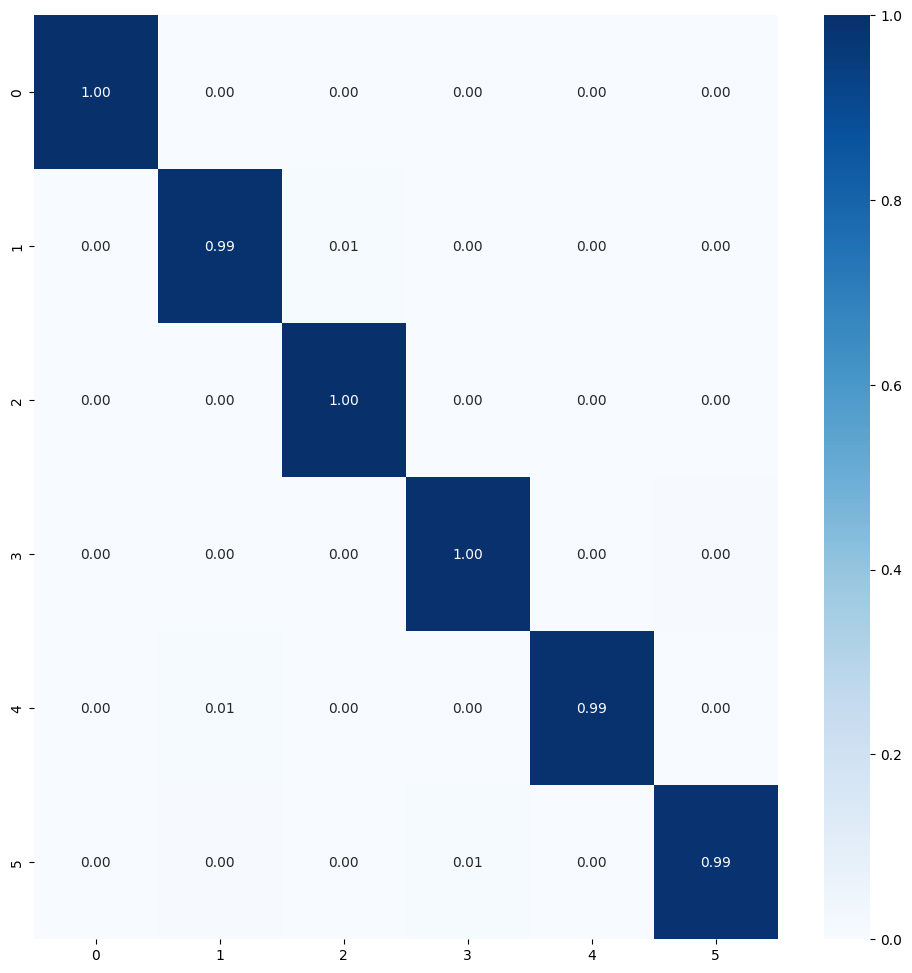


TRAINING AND EVALUATING FOLD 4/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
196/196 [==============================] - 17s 76ms/step - loss: 0.0247 - accuracy: 0.9995 - val_loss: 0.0503 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 2/50
196/196 [==============================] - 15s 77ms/step - loss: 0.0233 - accuracy: 1.0000 - val_loss: 0.0521 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 3/50
196/196 [==============================] - 14s 73ms/step - loss: 0.0236 - accuracy: 0.9997 - val_loss: 0.0525 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 4/50
196/196 [==============================] - 14s 71ms/step - loss: 0.0237 - accuracy: 0.9995 - val_loss: 0.0511 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 5/50
196/196 [==============================] - 14s 73ms/step - loss: 0.0232 - accuracy: 0.9998 - val_loss: 0.0506 - val_accuracy: 0.9963 - lr: 1.0000e-05
Epoch 6/50
196/196 [==============================] -

History for fold 4 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15006_4.pkl
197/197 [==============================] - 12s 60ms/step - loss: 0.0222 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.02216423489153385
43/43 [==============================] - 3s 62ms/step - loss: 0.0531 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.05314288288354874
43/43 [==============================] - 3s 60ms/step - loss: 0.0669 - accuracy: 0.9941
Test Accuracy: 0.9940740466117859
Test Log Loss: 0.06688012182712555
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 223   2   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0   0 224   0   1]
 [  0   2   0   0 223   0]
 [  0   1   0   2   0 222]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.0

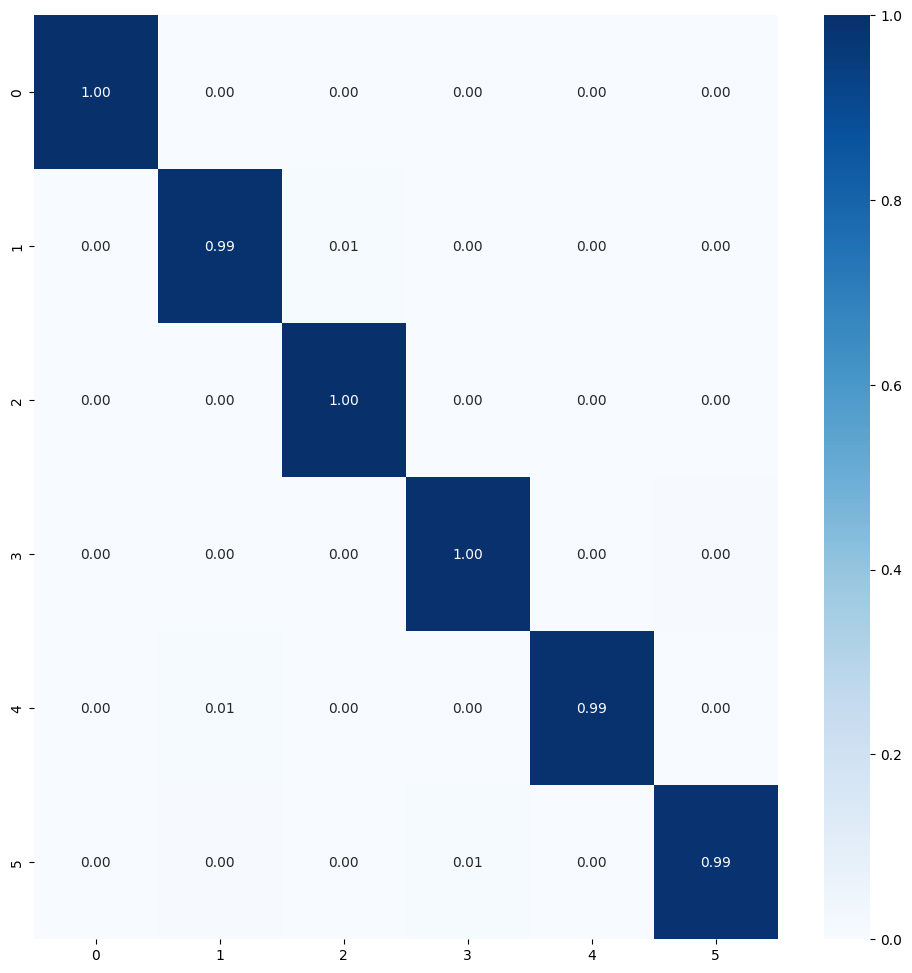


TRAINING AND EVALUATING FOLD 5/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
196/196 [==============================] - 17s 78ms/step - loss: 0.0249 - accuracy: 0.9994 - val_loss: 0.0507 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 2/50
196/196 [==============================] - 14s 71ms/step - loss: 0.0230 - accuracy: 0.9998 - val_loss: 0.0517 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 3/50
196/196 [==============================] - 15s 74ms/step - loss: 0.0231 - accuracy: 0.9998 - val_loss: 0.0582 - val_accuracy: 0.9918 - lr: 1.0000e-05
Epoch 4/50
196/196 [==============================] - 14s 72ms/step - loss: 0.0267 - accuracy: 0.9989 - val_loss: 0.0536 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 5/50
196/196 [==============================] - 15s 78ms/step - loss: 0.0237 - accuracy: 0.9997 - val_loss: 0.0530 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 6/50
196/196 [==============================] -

History for fold 5 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15006_5.pkl
197/197 [==============================] - 11s 57ms/step - loss: 0.0222 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.02215960994362831
43/43 [==============================] - 3s 60ms/step - loss: 0.0533 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.05327598750591278
43/43 [==============================] - 3s 60ms/step - loss: 0.0670 - accuracy: 0.9941
Test Accuracy: 0.9940740466117859
Test Log Loss: 0.06700776517391205
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 223   2   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0   0 224   0   1]
 [  0   2   0   0 223   0]
 [  0   1   0   2   0 222]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.0

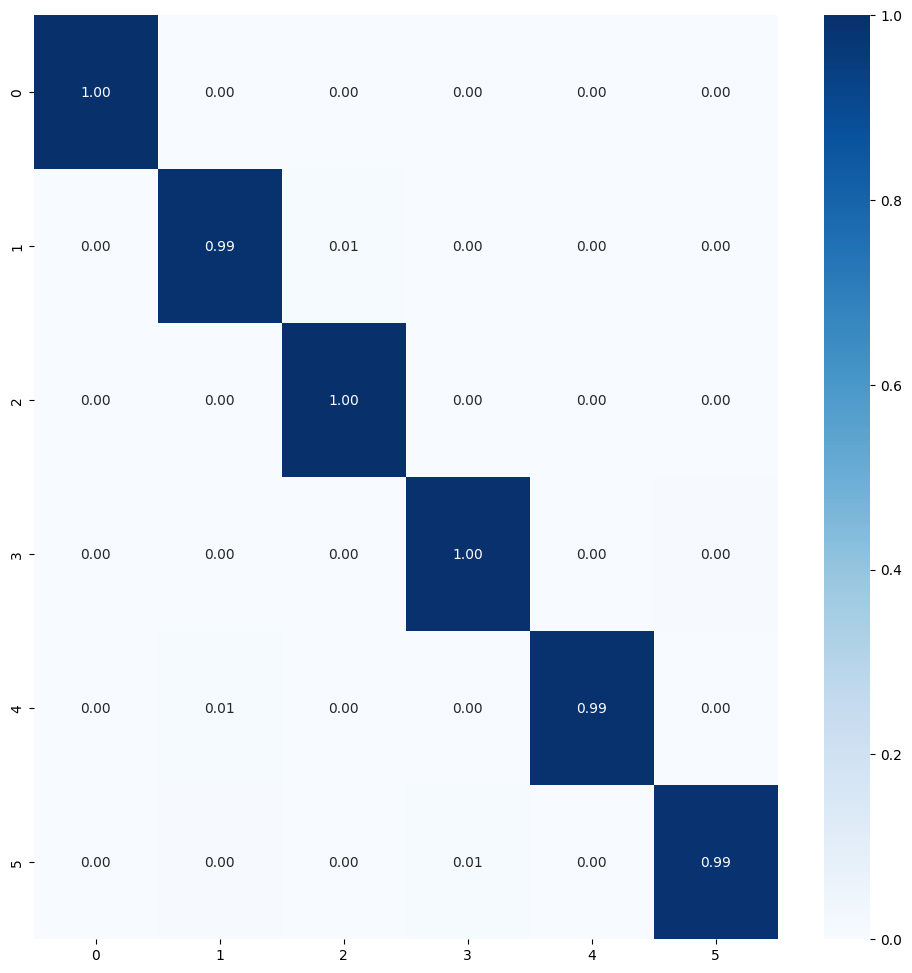


Best fold was 1 with val_accuracy: 0.9963
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.996279776096344

Test Metrics
test_acc_list: [0.9940740466117859, 0.9940740466117859, 0.9940740466117859, 0.9940740466117859, 0.9940740466117859]
Average Test Accuracy with 5-fold: 0.9940740466117859
test_loss_list: [0.06766575574874878, 0.06610962748527527, 0.06703996658325195, 0.06688012182712555, 0.06700776517391205]
Average Test Log Loss with 5-fold: 0.06694064736366272

Precision List: [0.9940968714291216, 0.9940968714291216, 0.9940968714291216, 0.9940968714291216, 0.9940968714291216]
Average Precision List with 5-fold: 0.9940968714291216
Recall List: [0.994074074074074, 0.994074074074074, 0.994074074074074, 0.994074074074074, 0.994074074074074]
Average Recall List with 5-fold: 0.994074074074074
F1 Score List: [0.994074000815718, 0.994074000815718, 0.994074000815718, 0.994074000815718, 0.994074000815718]
Average F1 Score List with 5-fold: 0.994074000815718


In [33]:
%%time

num_classes = 6
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/6
name_save_model: MobileNet_tf_15006
Found 6300 images belonging to 6 classes.
Found 1350 images belonging to 6 classes.
Found 1350 images belonging to 6 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15006_best.h5
Loading pre-trained model...


2025-07-14 11:28:26.475799: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22449 MB memory:  -> device: 0, name: NVIDIA RTX A5500, pci bus id: 0000:1a:00.0, compute capability: 8.6


Model loaded successfully.

Calculating layer importance (once for all folds)...

✅ Capas a descongelar (últimas 7 + top 3 importantes):

Últimas 7 capas del modelo:
  1. global_average_pooling2d_22
  2. dense_66
  3. batch_normalization_22
  4. dropout_44
  5. dense_67
  6. dropout_45
  7. dense_68

Total capas a entrenar: 7

TRAINING AND EVALUATING FOLD 1/5...


Capas configuradas como entrenables:
- global_average_pooling2d_22
- dense_66
- batch_normalization_22
- dropout_44
- dense_67
- dropout_45
- dense_68
Total: 7/93 capas entrenables
Epoch 1/50


2025-07-14 11:28:30.593089: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2025-07-14 11:28:32.162389: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f83ec2185c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-07-14 11:28:32.162417: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A5500, Compute Capability 8.6
2025-07-14 11:28:32.168468: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1752492512.294777     423 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


196/196 [==============================] - 19s 75ms/step - loss: 3.3324 - accuracy: 0.2176 - val_loss: 0.0594 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 2/50
196/196 [==============================] - 14s 73ms/step - loss: 2.6242 - accuracy: 0.2593 - val_loss: 0.0581 - val_accuracy: 0.9963 - lr: 1.0000e-05
Epoch 3/50
196/196 [==============================] - 15s 75ms/step - loss: 2.1879 - accuracy: 0.3084 - val_loss: 0.0553 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 4/50
196/196 [==============================] - 14s 69ms/step - loss: 1.9032 - accuracy: 0.3496 - val_loss: 0.0516 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 5/50
196/196 [==============================] - 15s 76ms/step - loss: 1.6927 - accuracy: 0.3928 - val_loss: 0.0455 - val_accuracy: 0.9963 - lr: 1.0000e-05
Epoch 6/50
196/196 [==============================] - 14s 72ms/step - loss: 1.5235 - accuracy: 0.4422 - val_loss: 0.0511 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 7/50
196/196 [=========================

History for fold 1 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15006_1.pkl
197/197 [==============================] - 12s 59ms/step - loss: 0.0601 - accuracy: 0.9968
Train Accuracy: 0.9968253970146179
Train Log Loss: 0.060053300112485886
43/43 [==============================] - 3s 60ms/step - loss: 0.0838 - accuracy: 0.9941
Validation Accuracy: 0.9940740466117859
Validation Log Loss: 0.08376771956682205
43/43 [==============================] - 3s 58ms/step - loss: 0.0892 - accuracy: 0.9926
Test Accuracy: 0.9925925731658936
Test Log Loss: 0.08918983489274979
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 223   2   0   0   0]
 [  1   0 222   0   0   2]
 [  0   0   0 224   0   1]
 [  0   2   0   0 223   0]
 [  0   1   0   1   0 223]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0   

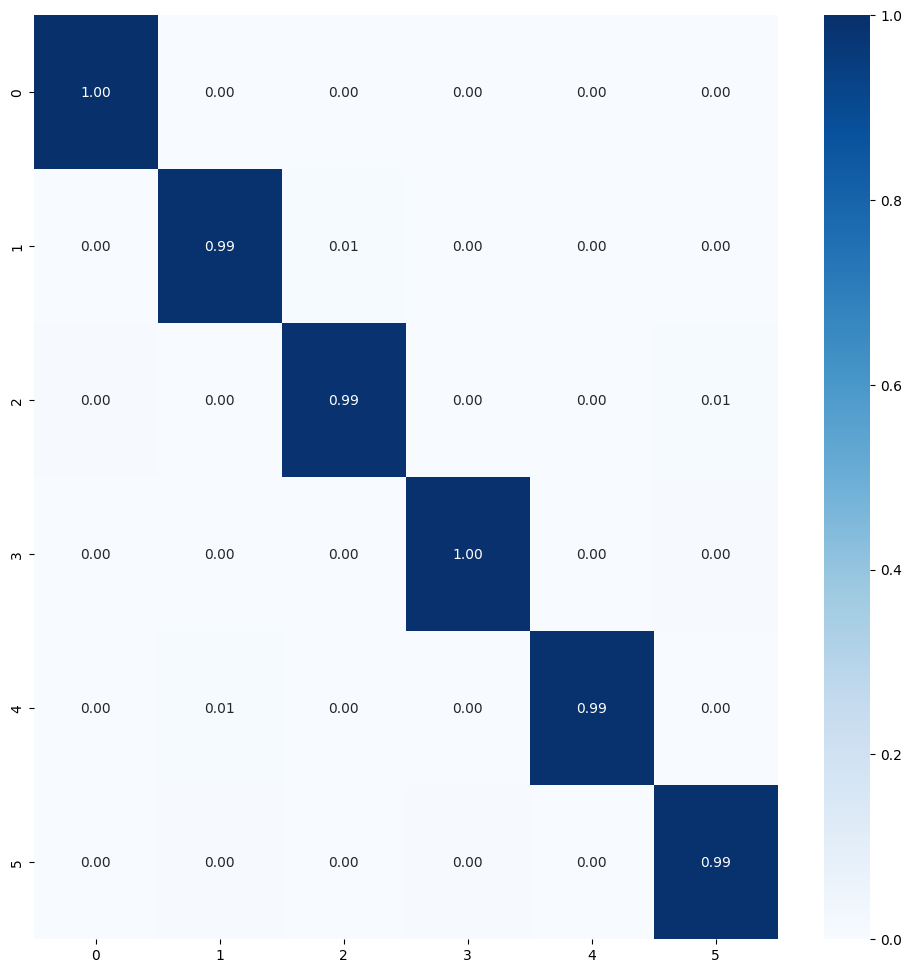


TRAINING AND EVALUATING FOLD 2/5...


Capas configuradas como entrenables:
- global_average_pooling2d_22
- dense_66
- batch_normalization_22
- dropout_44
- dense_67
- dropout_45
- dense_68
Total: 7/93 capas entrenables
Epoch 1/50
196/196 [==============================] - 18s 79ms/step - loss: 3.3524 - accuracy: 0.2175 - val_loss: 0.0565 - val_accuracy: 0.9963 - lr: 1.0000e-05
Epoch 2/50
196/196 [==============================] - 14s 73ms/step - loss: 2.6244 - accuracy: 0.2580 - val_loss: 0.0577 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 3/50
196/196 [==============================] - 15s 76ms/step - loss: 2.2011 - accuracy: 0.3062 - val_loss: 0.0542 - val_accuracy: 0.9948 - lr: 1.0000e-05
Epoch 4/50
196/196 [==============================] - 15s 76ms/step - loss: 1.9331 - accuracy: 0.3385 - val_loss: 0.0511 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 5/50
196/196 [==============================] - 15s 74ms/step - loss: 1.7077 - accuracy: 0.3867 - val_loss: 0.0500 - val_accuracy:

History for fold 2 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15006_2.pkl
197/197 [==============================] - 12s 62ms/step - loss: 0.0634 - accuracy: 0.9978
Train Accuracy: 0.9977777600288391
Train Log Loss: 0.06337197124958038
43/43 [==============================] - 3s 61ms/step - loss: 0.0864 - accuracy: 0.9911
Validation Accuracy: 0.9911110997200012
Validation Log Loss: 0.0864090546965599
43/43 [==============================] - 3s 62ms/step - loss: 0.0926 - accuracy: 0.9926
Test Accuracy: 0.9925925731658936
Test Log Loss: 0.09261049330234528
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 223   2   0   0   0]
 [  1   0 222   0   0   2]
 [  0   0   0 224   0   1]
 [  0   2   0   0 223   0]
 [  0   1   0   1   0 223]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0     

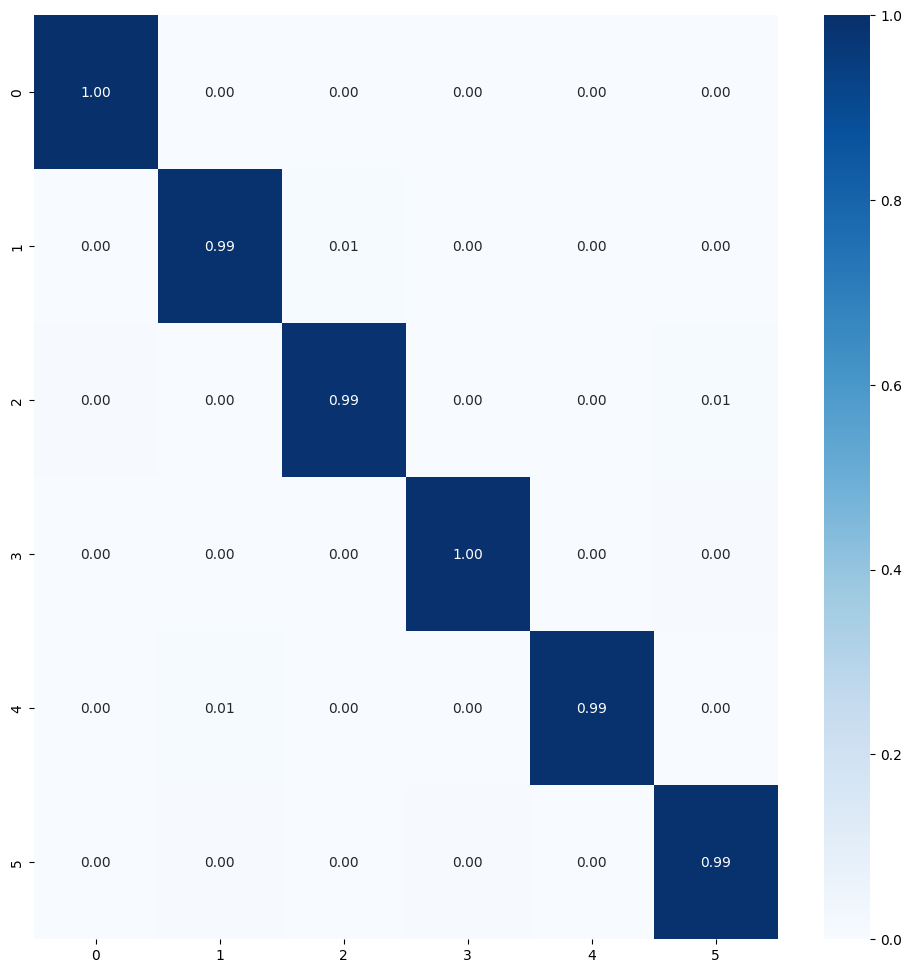


TRAINING AND EVALUATING FOLD 3/5...


Capas configuradas como entrenables:
- global_average_pooling2d_22
- dense_66
- batch_normalization_22
- dropout_44
- dense_67
- dropout_45
- dense_68
Total: 7/93 capas entrenables
Epoch 1/50
196/196 [==============================] - 18s 78ms/step - loss: 3.3563 - accuracy: 0.2170 - val_loss: 0.0574 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 2/50
196/196 [==============================] - 13s 67ms/step - loss: 2.6369 - accuracy: 0.2648 - val_loss: 0.0584 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 3/50
196/196 [==============================] - 14s 74ms/step - loss: 2.1878 - accuracy: 0.3079 - val_loss: 0.0559 - val_accuracy: 0.9948 - lr: 1.0000e-05
Epoch 4/50
196/196 [==============================] - 15s 75ms/step - loss: 1.9072 - accuracy: 0.3473 - val_loss: 0.0504 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 5/50
196/196 [==============================] - 14s 73ms/step - loss: 1.7014 - accuracy: 0.3867 - val_loss: 0.0419 - val_accuracy:

History for fold 3 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15006_3.pkl
197/197 [==============================] - 12s 63ms/step - loss: 0.0574 - accuracy: 0.9981
Train Accuracy: 0.9980952143669128
Train Log Loss: 0.057364676147699356
43/43 [==============================] - 3s 60ms/step - loss: 0.0811 - accuracy: 0.9933
Validation Accuracy: 0.9933333396911621
Validation Log Loss: 0.08110225200653076
43/43 [==============================] - 3s 61ms/step - loss: 0.0860 - accuracy: 0.9926
Test Accuracy: 0.9925925731658936
Test Log Loss: 0.08595792204141617
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 223   2   0   0   0]
 [  1   0 222   0   0   2]
 [  0   0   0 224   0   1]
 [  0   2   0   0 223   0]
 [  0   1   0   1   0 223]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0   

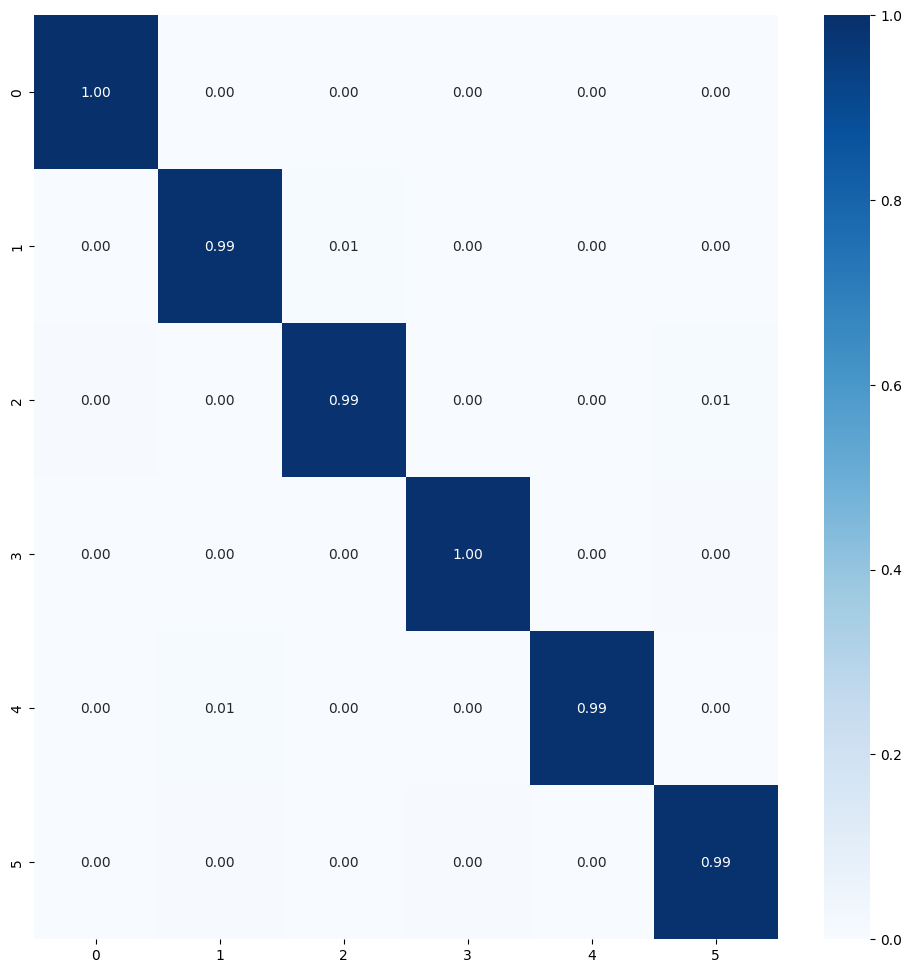


TRAINING AND EVALUATING FOLD 4/5...


Capas configuradas como entrenables:
- global_average_pooling2d_22
- dense_66
- batch_normalization_22
- dropout_44
- dense_67
- dropout_45
- dense_68
Total: 7/93 capas entrenables
Epoch 1/50
196/196 [==============================] - 18s 77ms/step - loss: 3.3315 - accuracy: 0.2160 - val_loss: 0.0590 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 2/50
196/196 [==============================] - 14s 73ms/step - loss: 2.6318 - accuracy: 0.2545 - val_loss: 0.0588 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 3/50
196/196 [==============================] - 15s 74ms/step - loss: 2.1863 - accuracy: 0.3170 - val_loss: 0.0555 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 4/50
196/196 [==============================] - 15s 75ms/step - loss: 1.9220 - accuracy: 0.3462 - val_loss: 0.0434 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 5/50
196/196 [==============================] - 15s 74ms/step - loss: 1.7056 - accuracy: 0.3914 - val_loss: 0.0498 - val_accuracy:

History for fold 4 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15006_4.pkl
197/197 [==============================] - 12s 59ms/step - loss: 0.0496 - accuracy: 0.9987
Train Accuracy: 0.9987301826477051
Train Log Loss: 0.0495930053293705
43/43 [==============================] - 3s 59ms/step - loss: 0.0737 - accuracy: 0.9941
Validation Accuracy: 0.9940740466117859
Validation Log Loss: 0.07367364317178726
43/43 [==============================] - 3s 60ms/step - loss: 0.0749 - accuracy: 0.9933
Test Accuracy: 0.9933333396911621
Test Log Loss: 0.07490542531013489
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 223   2   0   0   0]
 [  0   0 223   0   0   2]
 [  0   0   0 224   0   1]
 [  0   2   0   0 223   0]
 [  0   1   0   1   0 223]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0     

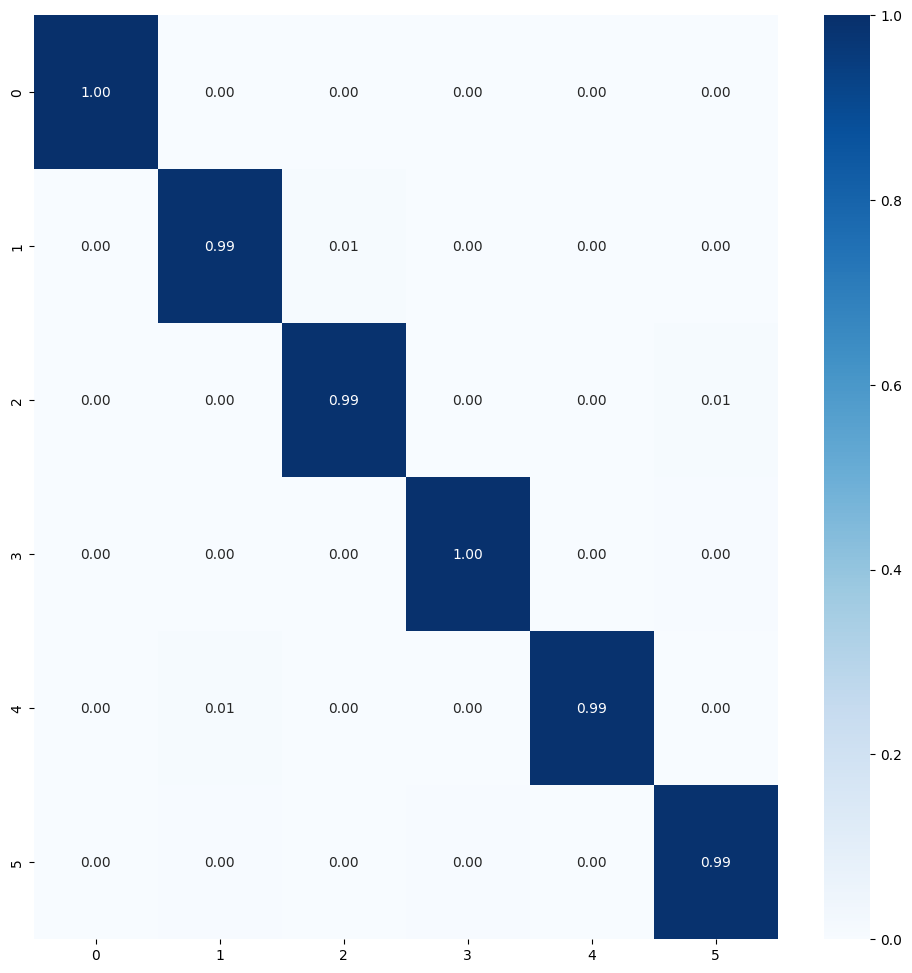


TRAINING AND EVALUATING FOLD 5/5...


Capas configuradas como entrenables:
- global_average_pooling2d_22
- dense_66
- batch_normalization_22
- dropout_44
- dense_67
- dropout_45
- dense_68
Total: 7/93 capas entrenables
Epoch 1/50
196/196 [==============================] - 18s 77ms/step - loss: 3.3466 - accuracy: 0.2138 - val_loss: 0.0584 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 2/50
196/196 [==============================] - 15s 75ms/step - loss: 2.6259 - accuracy: 0.2656 - val_loss: 0.0556 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 3/50
196/196 [==============================] - 15s 75ms/step - loss: 2.1913 - accuracy: 0.3087 - val_loss: 0.0552 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 4/50
196/196 [==============================] - 13s 68ms/step - loss: 1.9100 - accuracy: 0.3505 - val_loss: 0.0504 - val_accuracy: 0.9963 - lr: 1.0000e-05
Epoch 5/50
196/196 [==============================] - 15s 75ms/step - loss: 1.7049 - accuracy: 0.3906 - val_loss: 0.0500 - val_accuracy:

History for fold 5 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15006_5.pkl
197/197 [==============================] - 12s 63ms/step - loss: 0.0629 - accuracy: 0.9971
Train Accuracy: 0.9971428513526917
Train Log Loss: 0.06290043145418167
43/43 [==============================] - 3s 59ms/step - loss: 0.0863 - accuracy: 0.9911
Validation Accuracy: 0.9911110997200012
Validation Log Loss: 0.08632946759462357
43/43 [==============================] - 3s 62ms/step - loss: 0.0912 - accuracy: 0.9926
Test Accuracy: 0.9925925731658936
Test Log Loss: 0.09124958515167236
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 223   2   0   0   0]
 [  1   0 222   0   0   2]
 [  0   0   0 224   0   1]
 [  0   2   0   0 223   0]
 [  0   1   0   1   0 223]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0    

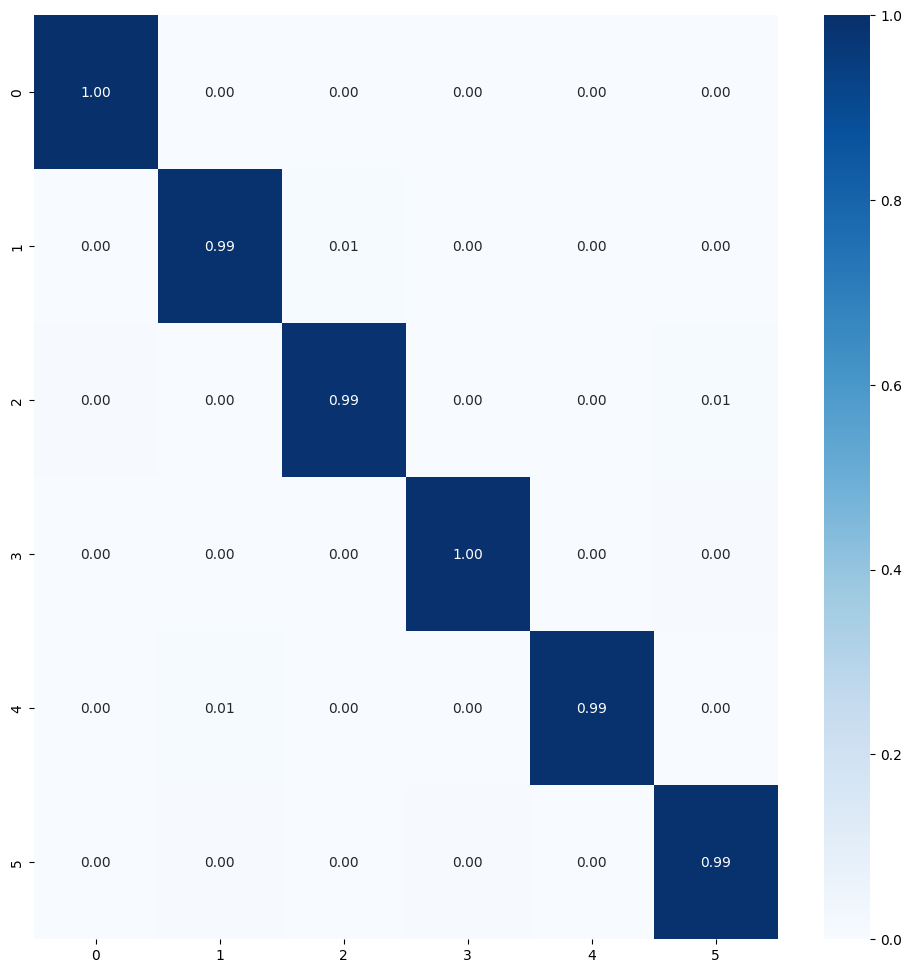


Best fold was 1 with val_accuracy: 0.9963
Average training accuracy in 5-fold: 0.9253031373023987
Average validation precision in 5-fold: 0.9961309671401978

Test Metrics
test_acc_list: [0.9925925731658936, 0.9925925731658936, 0.9925925731658936, 0.9933333396911621, 0.9925925731658936]
Average Test Accuracy with 5-fold: 0.9927407264709472
test_loss_list: [0.08918983489274979, 0.09261049330234528, 0.08595792204141617, 0.07490542531013489, 0.09124958515167236]
Average Test Log Loss with 5-fold: 0.0867826521396637

Precision List: [0.9926089221332584, 0.9926089221332584, 0.9926089221332584, 0.9933529990167158, 0.9926089221332584]
Average Precision List with 5-fold: 0.9927577375099499
Recall List: [0.9925925925925928, 0.9925925925925928, 0.9925925925925928, 0.9933333333333335, 0.9925925925925928]
Average Recall List with 5-fold: 0.9927407407407409
F1 Score List: [0.9925941947463012, 0.9925941947463012, 0.9925941947463012, 0.9933382386583607, 0.9925941947463012]
Average F1 Score List with 

In [18]:
# %%time
# # Ejecucion con solo 7 capas finales
# num_classes = 6
# test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
#     num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
#     recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/7
name_save_model: MobileNet_tf_15007
Found 7350 images belonging to 7 classes.
Found 1575 images belonging to 7 classes.
Found 1575 images belonging to 7 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15007_best.h5
Loading pre-trained model...
Model loaded successfully.

Calculating layer importance (once for all folds)...

Calculando importancia con 7350 muestras (100% confianza, ±0% error)
Incluyendo 93 capas (base + personalizadas)


100%|██████████| 7350/7350 [15:50<00:00,  7.74it/s]



Resultados de importancia de capas (incluyendo personalizadas):
----------------------------------------------------------------------
Pos.  | Nombre de Capa                           | Importancia    
----------------------------------------------------------------------
1     | conv_pw_1                                | 0.0000889
2     | conv_pw_3                                | 0.0000802
3     | conv_dw_1                                | 0.0000665
4     | conv_dw_1_bn                             | 0.0000557
5     | conv_pw_2                                | 0.0000463
6     | conv_dw_2_bn                             | 0.0000439
7     | conv_pw_3_bn                             | 0.0000409
8     | conv_dw_3_bn                             | 0.0000395
9     | conv_dw_4_bn                             | 0.0000380
10    | conv_pw_1_bn                             | 0.0000358
11    | conv1_bn                                 | 0.0000356
12    | conv_pw_4                                | 0.00

History for fold 1 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15007_1.pkl
230/230 [==============================] - 14s 59ms/step - loss: 0.0132 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.013241257518529892
50/50 [==============================] - 3s 58ms/step - loss: 0.0581 - accuracy: 0.9937
Validation Accuracy: 0.9936507940292358
Validation Log Loss: 0.058117423206567764
50/50 [==============================] - 3s 59ms/step - loss: 0.0548 - accuracy: 0.9943
Test Accuracy: 0.9942857027053833
Test Log Loss: 0.054842717945575714
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   0   0   0   1]
 [  0   0 224   1   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0   0 224   0   1]
 [  0   0   2   0   0 223   0]
 [  0   0   1   0   3   0 221]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
         

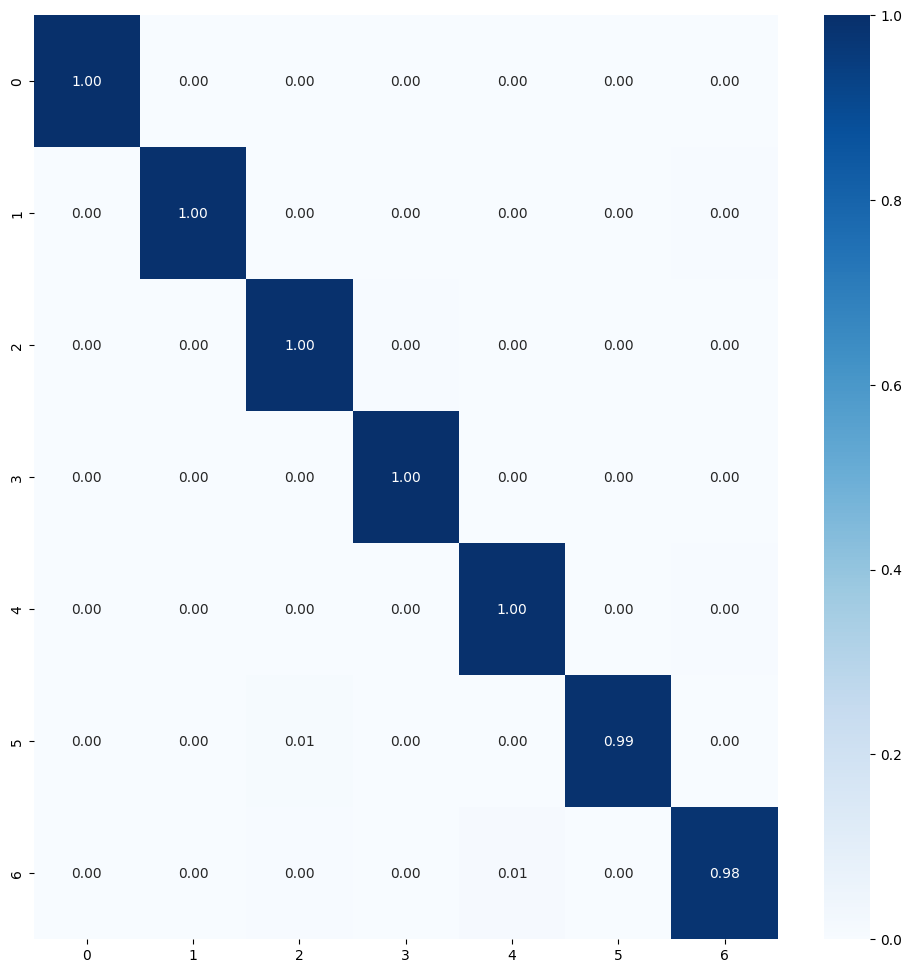


TRAINING AND EVALUATING FOLD 2/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
229/229 [==============================] - 19s 75ms/step - loss: 0.0136 - accuracy: 0.9999 - val_loss: 0.0557 - val_accuracy: 0.9943 - lr: 1.0000e-05
Epoch 2/50
229/229 [==============================] - 16s 70ms/step - loss: 0.0134 - accuracy: 1.0000 - val_loss: 0.0567 - val_accuracy: 0.9936 - lr: 1.0000e-05
Epoch 3/50
229/229 [==============================] - 17s 73ms/step - loss: 0.0133 - accuracy: 1.0000 - val_loss: 0.0566 - val_accuracy: 0.9936 - lr: 1.0000e-05
Epoch 4/50
229/229 [==============================] - 17s 72ms/step - loss: 0.0134 - accuracy: 1.0000 - val_loss: 0.0550 - val_accuracy: 0.9936 - lr: 1.0000e-05
Epoch 5/50
229/229 [==============================] - 16s 71ms/step - loss: 0.0133 - accuracy: 1.0000 - val_loss: 0.0544 - val_accuracy: 0.9936 - lr: 1.0000e-05
Epoch 6/50
229/229 [==============================] -

History for fold 2 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15007_2.pkl
230/230 [==============================] - 14s 60ms/step - loss: 0.0132 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.013234535232186317
50/50 [==============================] - 3s 61ms/step - loss: 0.0553 - accuracy: 0.9937
Validation Accuracy: 0.9936507940292358
Validation Log Loss: 0.055303581058979034
50/50 [==============================] - 3s 60ms/step - loss: 0.0546 - accuracy: 0.9949
Test Accuracy: 0.9949206113815308
Test Log Loss: 0.05456143245100975
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   0   0   0   1]
 [  0   0 225   0   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0   0 224   0   1]
 [  0   0   2   0   0 223   0]
 [  0   0   1   0   3   0 221]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
          

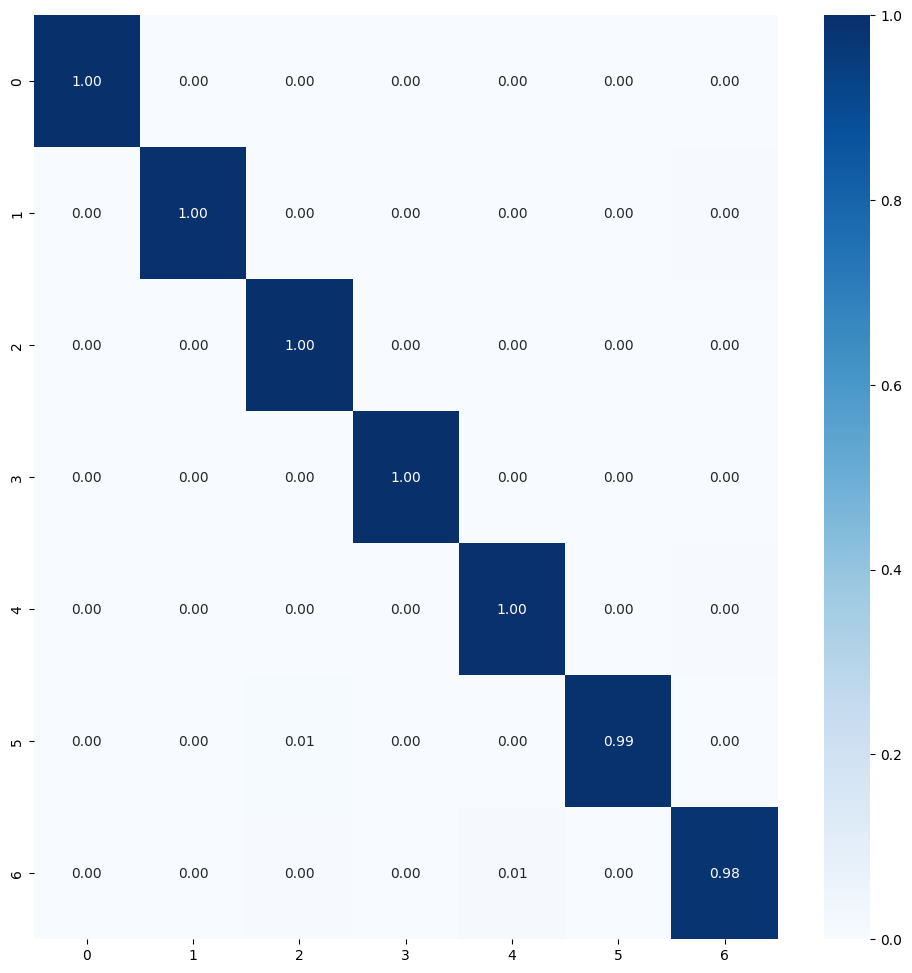


TRAINING AND EVALUATING FOLD 3/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
229/229 [==============================] - 20s 77ms/step - loss: 0.0135 - accuracy: 1.0000 - val_loss: 0.0557 - val_accuracy: 0.9936 - lr: 1.0000e-05
Epoch 2/50
229/229 [==============================] - 17s 74ms/step - loss: 0.0133 - accuracy: 1.0000 - val_loss: 0.0541 - val_accuracy: 0.9936 - lr: 1.0000e-05
Epoch 3/50
229/229 [==============================] - 16s 71ms/step - loss: 0.0133 - accuracy: 1.0000 - val_loss: 0.0539 - val_accuracy: 0.9936 - lr: 1.0000e-05
Epoch 4/50
229/229 [==============================] - 16s 71ms/step - loss: 0.0133 - accuracy: 1.0000 - val_loss: 0.0533 - val_accuracy: 0.9936 - lr: 1.0000e-05
Epoch 5/50
229/229 [==============================] - 17s 73ms/step - loss: 0.0134 - accuracy: 1.0000 - val_loss: 0.0504 - val_accuracy: 0.9943 - lr: 1.0000e-05
Epoch 6/50
229/229 [==============================] -

History for fold 3 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15007_3.pkl
230/230 [==============================] - 13s 57ms/step - loss: 0.0132 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.013227983377873898
50/50 [==============================] - 3s 49ms/step - loss: 0.0561 - accuracy: 0.9937
Validation Accuracy: 0.9936507940292358
Validation Log Loss: 0.056078262627124786
50/50 [==============================] - 3s 58ms/step - loss: 0.0540 - accuracy: 0.9943
Test Accuracy: 0.9942857027053833
Test Log Loss: 0.05402597039937973
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   0   0   0   1]
 [  0   0 224   1   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0   0 224   0   1]
 [  0   0   2   0   0 223   0]
 [  0   0   1   0   3   0 221]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
          

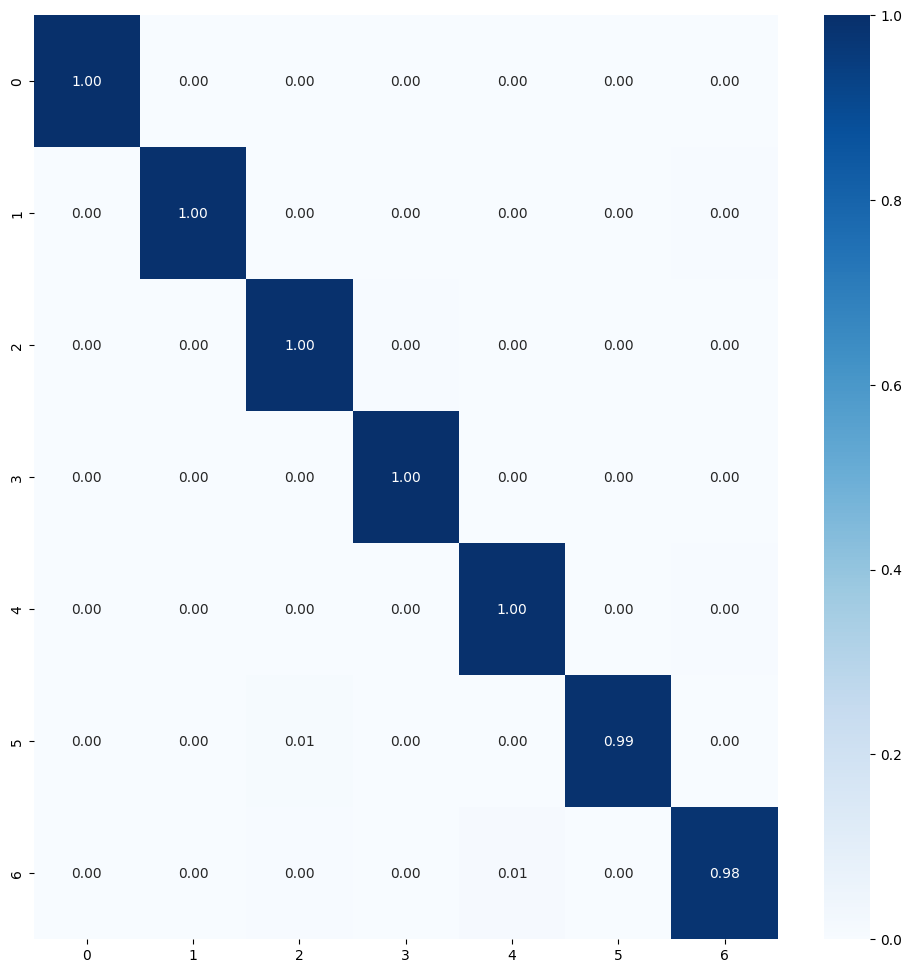


TRAINING AND EVALUATING FOLD 4/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
229/229 [==============================] - 19s 76ms/step - loss: 0.0134 - accuracy: 1.0000 - val_loss: 0.0535 - val_accuracy: 0.9943 - lr: 1.0000e-05
Epoch 2/50
229/229 [==============================] - 17s 73ms/step - loss: 0.0133 - accuracy: 1.0000 - val_loss: 0.0530 - val_accuracy: 0.9936 - lr: 1.0000e-05
Epoch 3/50
229/229 [==============================] - 17s 73ms/step - loss: 0.0153 - accuracy: 0.9989 - val_loss: 0.0556 - val_accuracy: 0.9936 - lr: 1.0000e-05
Epoch 4/50
229/229 [==============================] - 16s 70ms/step - loss: 0.0142 - accuracy: 0.9999 - val_loss: 0.0566 - val_accuracy: 0.9936 - lr: 1.0000e-05
Epoch 5/50
229/229 [==============================] - 16s 68ms/step - loss: 0.0134 - accuracy: 1.0000 - val_loss: 0.0563 - val_accuracy: 0.9936 - lr: 1.0000e-05
Epoch 6/50
229/229 [==============================] -

History for fold 4 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15007_4.pkl
230/230 [==============================] - 13s 57ms/step - loss: 0.0132 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.013224344700574875
50/50 [==============================] - 3s 59ms/step - loss: 0.0545 - accuracy: 0.9937
Validation Accuracy: 0.9936507940292358
Validation Log Loss: 0.054525043815374374
50/50 [==============================] - 3s 60ms/step - loss: 0.0539 - accuracy: 0.9949
Test Accuracy: 0.9949206113815308
Test Log Loss: 0.05394073575735092
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   0   0   0   1]
 [  0   0 224   1   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0   0 224   0   1]
 [  0   0   2   0   0 223   0]
 [  0   0   1   0   2   0 222]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
          

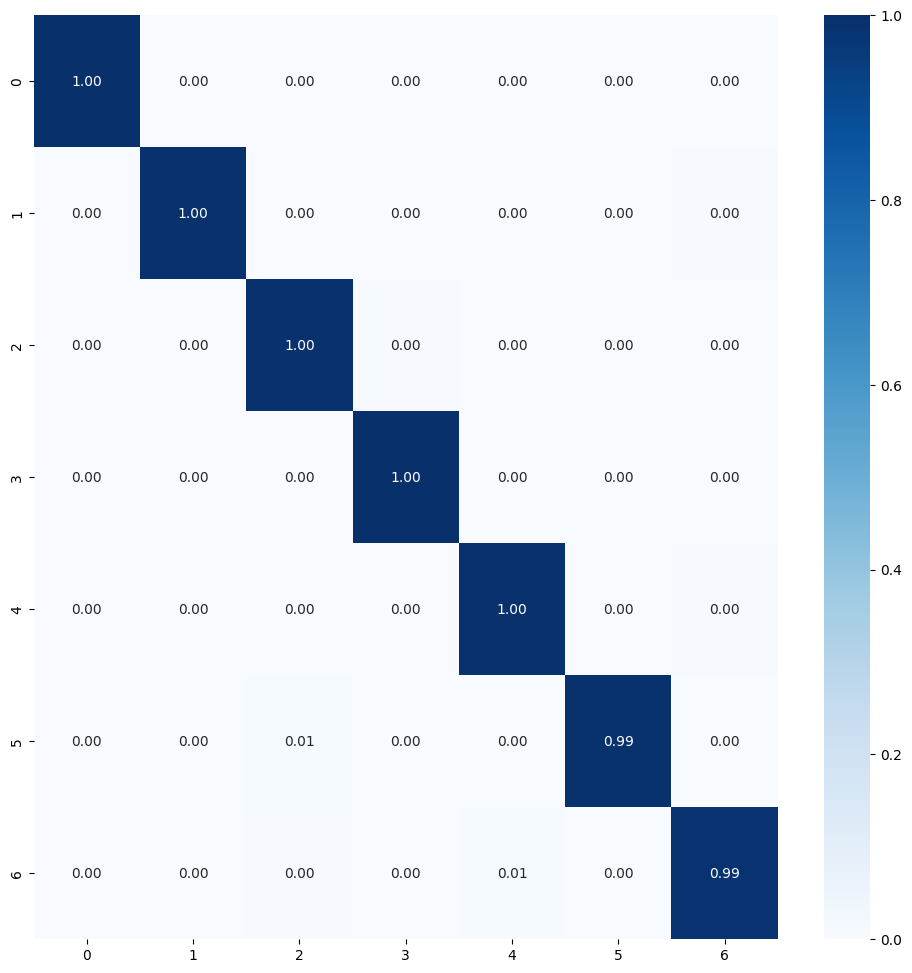


TRAINING AND EVALUATING FOLD 5/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
229/229 [==============================] - 20s 77ms/step - loss: 0.0138 - accuracy: 0.9999 - val_loss: 0.0688 - val_accuracy: 0.9911 - lr: 1.0000e-05
Epoch 2/50
229/229 [==============================] - 16s 71ms/step - loss: 0.0143 - accuracy: 0.9996 - val_loss: 0.0584 - val_accuracy: 0.9936 - lr: 1.0000e-05
Epoch 3/50
229/229 [==============================] - 17s 72ms/step - loss: 0.0134 - accuracy: 1.0000 - val_loss: 0.0562 - val_accuracy: 0.9936 - lr: 1.0000e-05
Epoch 4/50
229/229 [==============================] - 16s 71ms/step - loss: 0.0134 - accuracy: 1.0000 - val_loss: 0.0561 - val_accuracy: 0.9936 - lr: 1.0000e-05
Epoch 5/50
229/229 [==============================] - 17s 72ms/step - loss: 0.0134 - accuracy: 1.0000 - val_loss: 0.0549 - val_accuracy: 0.9936 - lr: 1.0000e-05
Epoch 6/50
229/229 [==============================] -

History for fold 5 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15007_5.pkl
230/230 [==============================] - 14s 60ms/step - loss: 0.0132 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.013221371918916702
50/50 [==============================] - 3s 62ms/step - loss: 0.0558 - accuracy: 0.9937
Validation Accuracy: 0.9936507940292358
Validation Log Loss: 0.055812638252973557
50/50 [==============================] - 3s 58ms/step - loss: 0.0556 - accuracy: 0.9943
Test Accuracy: 0.9942857027053833
Test Log Loss: 0.05556086078286171
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   0   0   0   1]
 [  0   0 224   1   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0   0 224   0   1]
 [  0   0   2   0   0 223   0]
 [  0   0   1   0   3   0 221]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
          

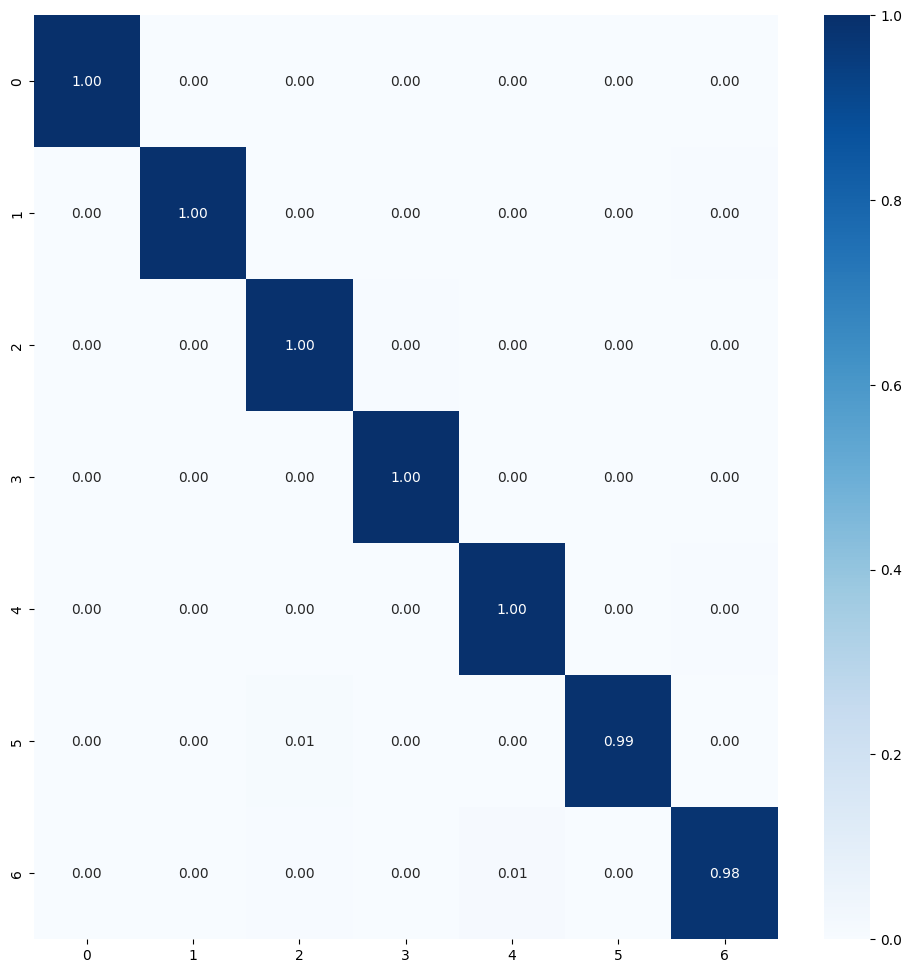


Best fold was 1 with val_accuracy: 0.9943
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.9942601919174194

Test Metrics
test_acc_list: [0.9942857027053833, 0.9949206113815308, 0.9942857027053833, 0.9949206113815308, 0.9942857027053833]
Average Test Accuracy with 5-fold: 0.9945396661758423
test_loss_list: [0.054842717945575714, 0.05456143245100975, 0.05402597039937973, 0.05394073575735092, 0.05556086078286171]
Average Test Log Loss with 5-fold: 0.054586343467235565

Precision List: [0.9943106990445418, 0.9949510909095499, 0.9943106990445418, 0.9949401761796295, 0.9943106990445418]
Average Precision List with 5-fold: 0.994564672844561
Recall List: [0.9942857142857143, 0.994920634920635, 0.9942857142857143, 0.9949206349206349, 0.9942857142857143]
Average Recall List with 5-fold: 0.9945396825396825
F1 Score List: [0.994285610815169, 0.9949205159388911, 0.994285610815169, 0.9949219926013535, 0.994285610815169]
Average F1 Score List with 5-fold: 0.9945398

In [34]:
%%time

num_classes = 7
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/8
name_save_model: MobileNet_tf_15008
Found 8400 images belonging to 8 classes.
Found 1800 images belonging to 8 classes.
Found 1800 images belonging to 8 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15008_best.h5
Loading pre-trained model...
Model loaded successfully.

Calculating layer importance (once for all folds)...

Calculando importancia con 8400 muestras (100% confianza, ±0% error)
Incluyendo 93 capas (base + personalizadas)


100%|██████████| 8400/8400 [18:16<00:00,  7.66it/s]



Resultados de importancia de capas (incluyendo personalizadas):
----------------------------------------------------------------------
Pos.  | Nombre de Capa                           | Importancia    
----------------------------------------------------------------------
1     | conv_pw_1                                | 0.0004702
2     | conv_pw_3                                | 0.0004166
3     | conv_dw_1                                | 0.0003752
4     | conv_dw_1_bn                             | 0.0002995
5     | conv_dw_2_bn                             | 0.0002340
6     | conv_pw_2                                | 0.0002333
7     | conv_pw_3_bn                             | 0.0002112
8     | conv_dw_3_bn                             | 0.0001984
9     | conv_dw_4_bn                             | 0.0001929
10    | conv_pw_1_bn                             | 0.0001795
11    | conv_pw_4                                | 0.0001777
12    | conv1_bn                                 | 0.00

History for fold 1 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15008_1.pkl
263/263 [==============================] - 16s 61ms/step - loss: 0.0110 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.010992610827088356
57/57 [==============================] - 3s 60ms/step - loss: 0.0430 - accuracy: 0.9950
Validation Accuracy: 0.9950000047683716
Validation Log Loss: 0.043035976588726044
57/57 [==============================] - 4s 59ms/step - loss: 0.0436 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.04362427443265915
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [  0 224   0   0   0   0   0   1]
 [  0   0 224   0   1   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0]
 [  0   0   0   0   0 225   0   0]
 [  0   0   2   0   0   0 223   0]
 [  0   0   1   0   0   3   0 221]]
True labels: 1800

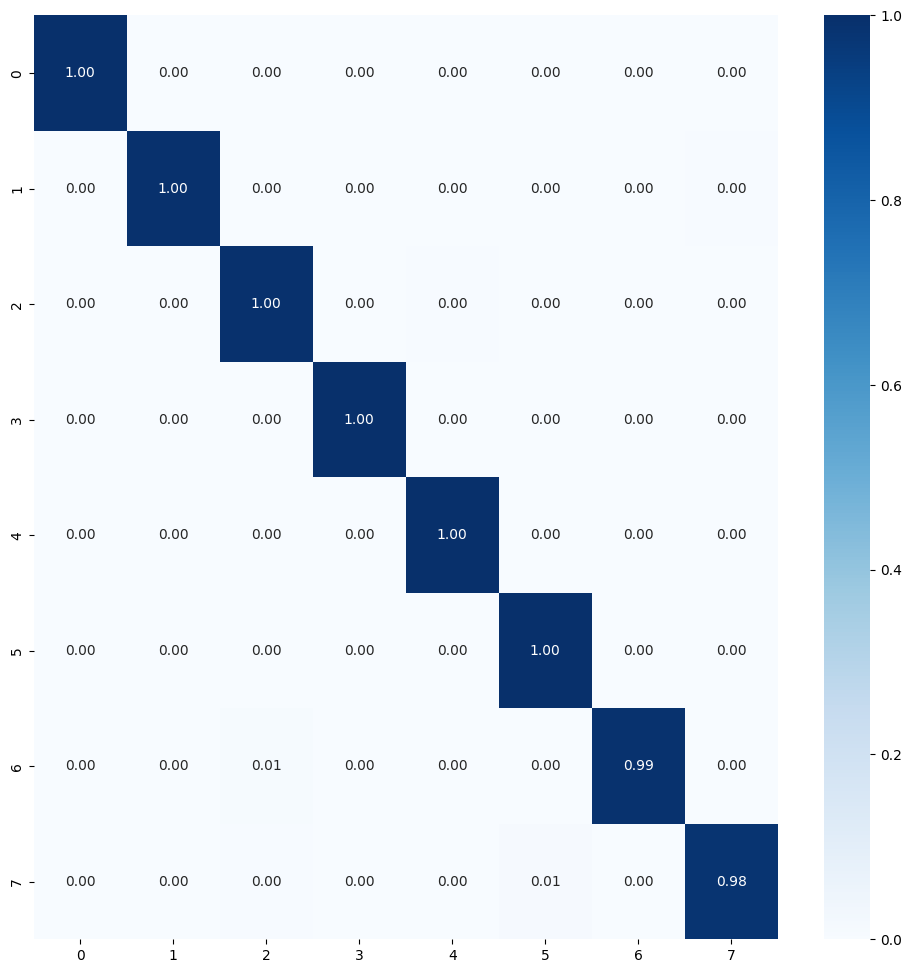


TRAINING AND EVALUATING FOLD 2/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
262/262 [==============================] - 26s 91ms/step - loss: 0.0112 - accuracy: 1.0000 - val_loss: 0.0468 - val_accuracy: 0.9944 - lr: 1.0000e-05
Epoch 2/50
262/262 [==============================] - 18s 68ms/step - loss: 0.0128 - accuracy: 0.9996 - val_loss: 0.0448 - val_accuracy: 0.9950 - lr: 1.0000e-05
Epoch 3/50
262/262 [==============================] - 20s 75ms/step - loss: 0.0111 - accuracy: 1.0000 - val_loss: 0.0449 - val_accuracy: 0.9950 - lr: 1.0000e-05
Epoch 4/50
262/262 [==============================] - 20s 76ms/step - loss: 0.0112 - accuracy: 1.0000 - val_loss: 0.0446 - val_accuracy: 0.9950 - lr: 1.0000e-05
Epoch 5/50
262/262 [==============================] - 19s 73ms/step - loss: 0.0111 - accuracy: 1.0000 - val_loss: 0.0442 - val_accuracy: 0.9950 - lr: 1.0000e-05
Epoch 6/50
262/262 [==============================] -

History for fold 2 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15008_2.pkl
263/263 [==============================] - 16s 60ms/step - loss: 0.0110 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.010986870154738426
57/57 [==============================] - 3s 59ms/step - loss: 0.0431 - accuracy: 0.9950
Validation Accuracy: 0.9950000047683716
Validation Log Loss: 0.04314080625772476
57/57 [==============================] - 4s 60ms/step - loss: 0.0443 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.044304948300123215
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [  0 224   0   0   0   0   0   1]
 [  0   0 224   0   1   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0]
 [  0   0   0   0   0 225   0   0]
 [  0   0   2   0   0   0 223   0]
 [  0   0   1   0   0   3   0 221]]
True labels: 1800

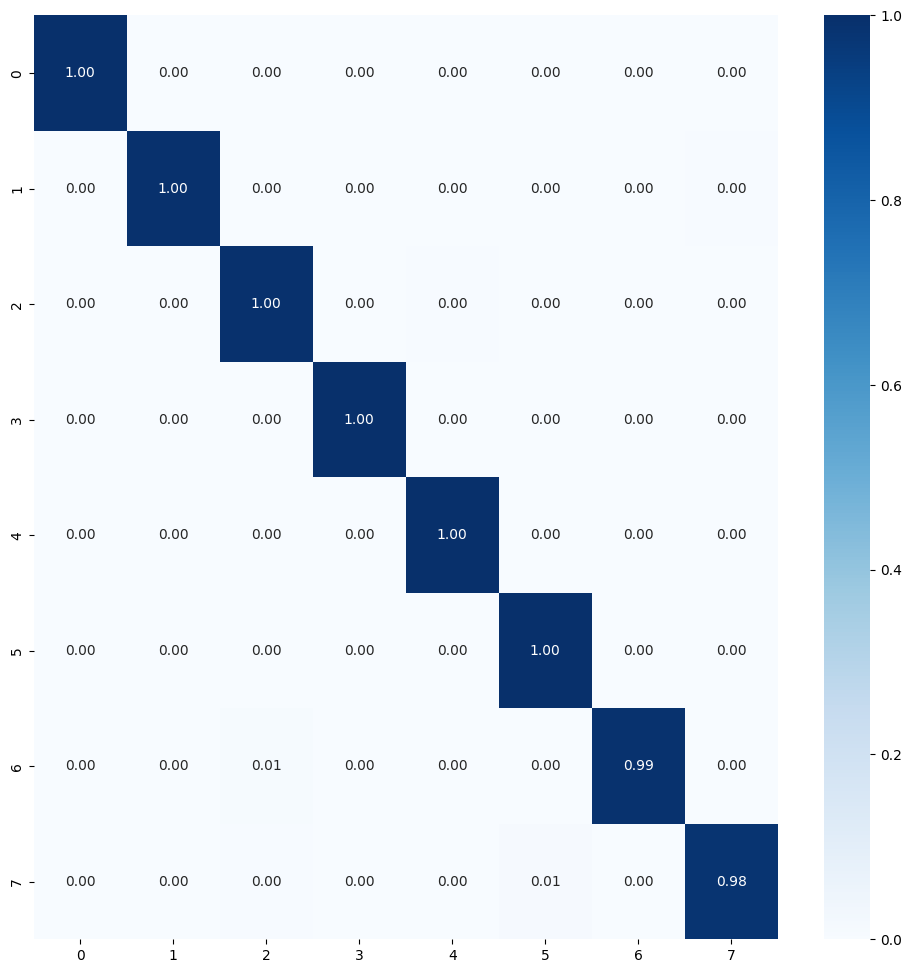


TRAINING AND EVALUATING FOLD 3/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
262/262 [==============================] - 22s 75ms/step - loss: 0.0114 - accuracy: 1.0000 - val_loss: 0.0429 - val_accuracy: 0.9950 - lr: 1.0000e-05
Epoch 2/50
262/262 [==============================] - 19s 71ms/step - loss: 0.0111 - accuracy: 1.0000 - val_loss: 0.0431 - val_accuracy: 0.9950 - lr: 1.0000e-05
Epoch 3/50
262/262 [==============================] - 19s 72ms/step - loss: 0.0112 - accuracy: 1.0000 - val_loss: 0.0438 - val_accuracy: 0.9950 - lr: 1.0000e-05
Epoch 4/50
262/262 [==============================] - 19s 73ms/step - loss: 0.0112 - accuracy: 1.0000 - val_loss: 0.0412 - val_accuracy: 0.9950 - lr: 1.0000e-05
Epoch 5/50
262/262 [==============================] - 19s 72ms/step - loss: 0.0112 - accuracy: 1.0000 - val_loss: 0.0435 - val_accuracy: 0.9950 - lr: 1.0000e-05
Epoch 6/50
262/262 [==============================] -

History for fold 3 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15008_3.pkl
263/263 [==============================] - 16s 61ms/step - loss: 0.0110 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.01099984347820282
57/57 [==============================] - 3s 53ms/step - loss: 0.0431 - accuracy: 0.9950
Validation Accuracy: 0.9950000047683716
Validation Log Loss: 0.04305869713425636
57/57 [==============================] - 4s 61ms/step - loss: 0.0433 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.04333743453025818
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [  0 224   0   0   0   0   0   1]
 [  0   0 224   0   1   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0]
 [  0   0   0   0   0 225   0   0]
 [  0   0   2   0   0   0 223   0]
 [  0   0   1   0   0   3   0 221]]
True labels: 1800
P

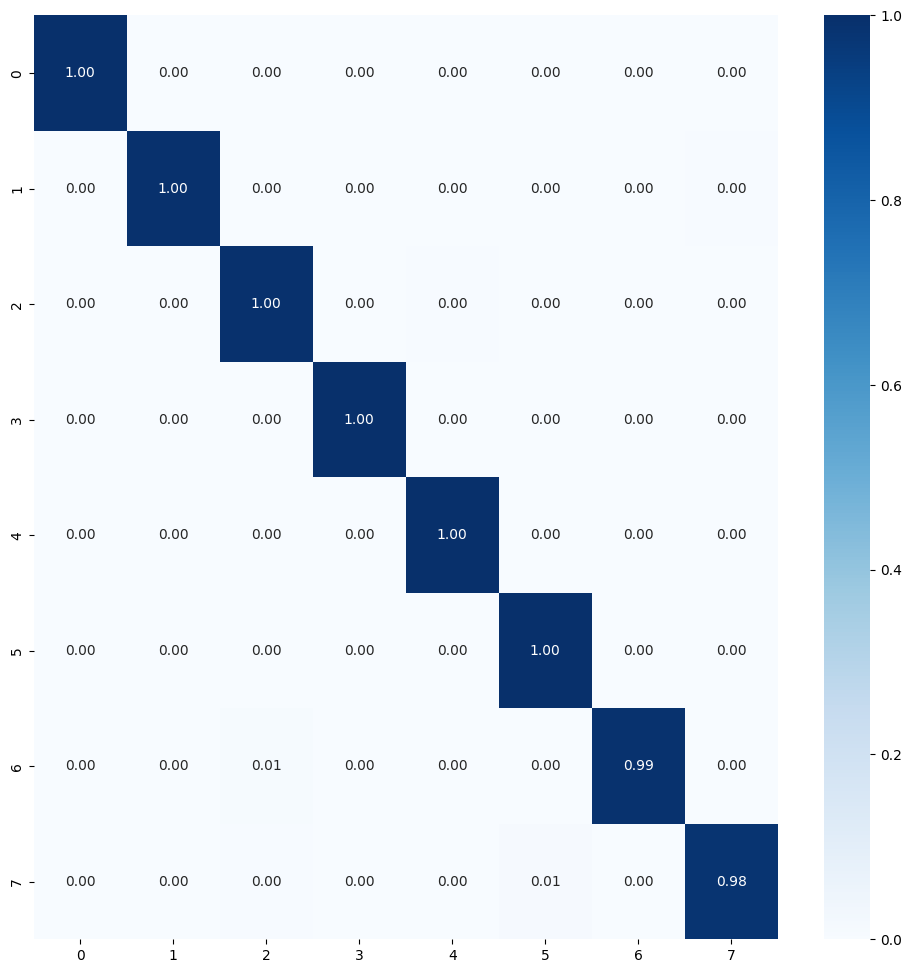


TRAINING AND EVALUATING FOLD 4/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
262/262 [==============================] - 22s 78ms/step - loss: 0.0113 - accuracy: 1.0000 - val_loss: 0.0440 - val_accuracy: 0.9950 - lr: 1.0000e-05
Epoch 2/50
262/262 [==============================] - 19s 74ms/step - loss: 0.0112 - accuracy: 1.0000 - val_loss: 0.0476 - val_accuracy: 0.9939 - lr: 1.0000e-05
Epoch 3/50
262/262 [==============================] - 19s 71ms/step - loss: 0.0113 - accuracy: 1.0000 - val_loss: 0.0415 - val_accuracy: 0.9950 - lr: 1.0000e-05
Epoch 4/50
262/262 [==============================] - 19s 74ms/step - loss: 0.0112 - accuracy: 1.0000 - val_loss: 0.0456 - val_accuracy: 0.9944 - lr: 1.0000e-05
Epoch 5/50
262/262 [==============================] - 19s 71ms/step - loss: 0.0111 - accuracy: 1.0000 - val_loss: 0.0382 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 6/50
262/262 [==============================] -

History for fold 4 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15008_4.pkl
263/263 [==============================] - 16s 62ms/step - loss: 0.0110 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.010997727513313293
57/57 [==============================] - 4s 62ms/step - loss: 0.0429 - accuracy: 0.9950
Validation Accuracy: 0.9950000047683716
Validation Log Loss: 0.04293039068579674
57/57 [==============================] - 3s 58ms/step - loss: 0.0430 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.043024927377700806
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [  0 224   0   0   0   0   0   1]
 [  0   0 224   0   1   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0]
 [  0   0   0   0   0 225   0   0]
 [  0   0   2   0   0   0 223   0]
 [  0   0   1   0   0   3   0 221]]
True labels: 1800

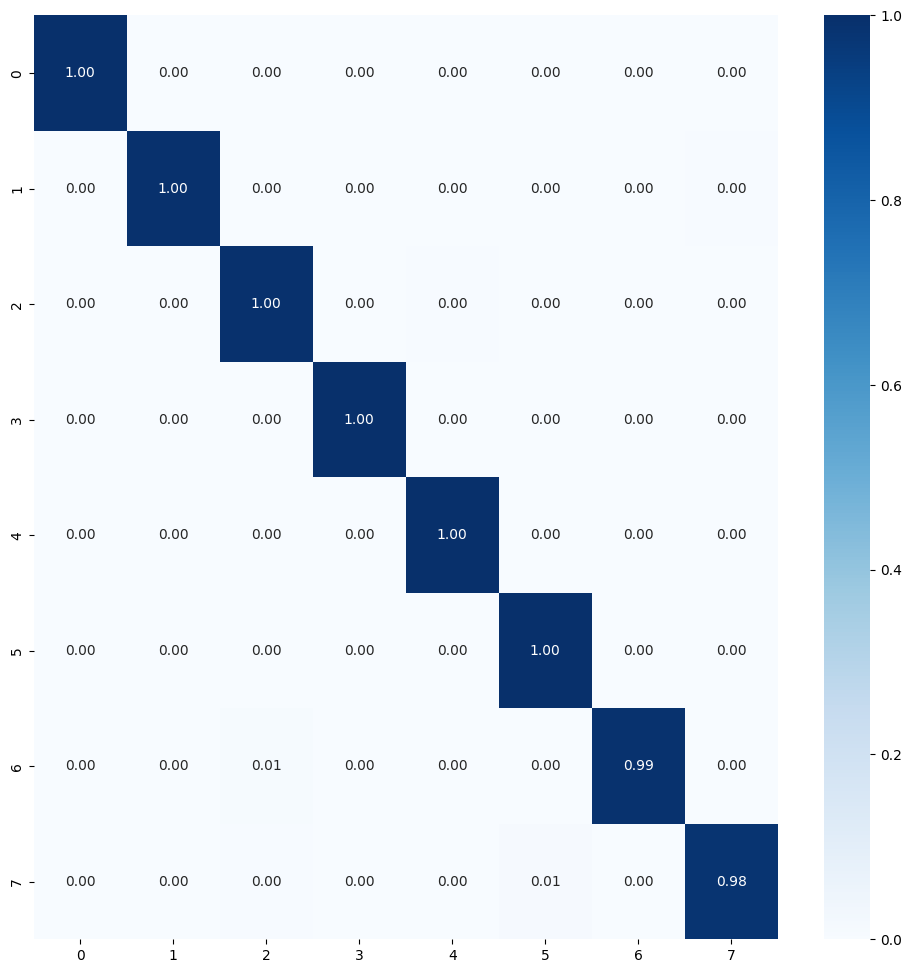


TRAINING AND EVALUATING FOLD 5/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
262/262 [==============================] - 22s 77ms/step - loss: 0.0112 - accuracy: 1.0000 - val_loss: 0.0456 - val_accuracy: 0.9944 - lr: 1.0000e-05
Epoch 2/50
262/262 [==============================] - 19s 73ms/step - loss: 0.0112 - accuracy: 1.0000 - val_loss: 0.0428 - val_accuracy: 0.9950 - lr: 1.0000e-05
Epoch 3/50
262/262 [==============================] - 19s 72ms/step - loss: 0.0132 - accuracy: 0.9992 - val_loss: 0.0424 - val_accuracy: 0.9950 - lr: 1.0000e-05
Epoch 4/50
262/262 [==============================] - 20s 75ms/step - loss: 0.0112 - accuracy: 1.0000 - val_loss: 0.0432 - val_accuracy: 0.9950 - lr: 1.0000e-05
Epoch 5/50
262/262 [==============================] - 21s 79ms/step - loss: 0.0112 - accuracy: 1.0000 - val_loss: 0.0434 - val_accuracy: 0.9950 - lr: 1.0000e-05
Epoch 6/50
262/262 [==============================] -

History for fold 5 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15008_5.pkl
263/263 [==============================] - 16s 59ms/step - loss: 0.0110 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.010989140719175339
57/57 [==============================] - 4s 60ms/step - loss: 0.0431 - accuracy: 0.9950
Validation Accuracy: 0.9950000047683716
Validation Log Loss: 0.0430576354265213
57/57 [==============================] - 4s 60ms/step - loss: 0.0440 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.043974827975034714
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [  0 224   0   0   0   0   0   1]
 [  0   0 224   0   1   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0]
 [  0   0   0   0   0 225   0   0]
 [  0   0   2   0   0   0 223   0]
 [  0   0   1   0   0   3   0 221]]
True labels: 1800


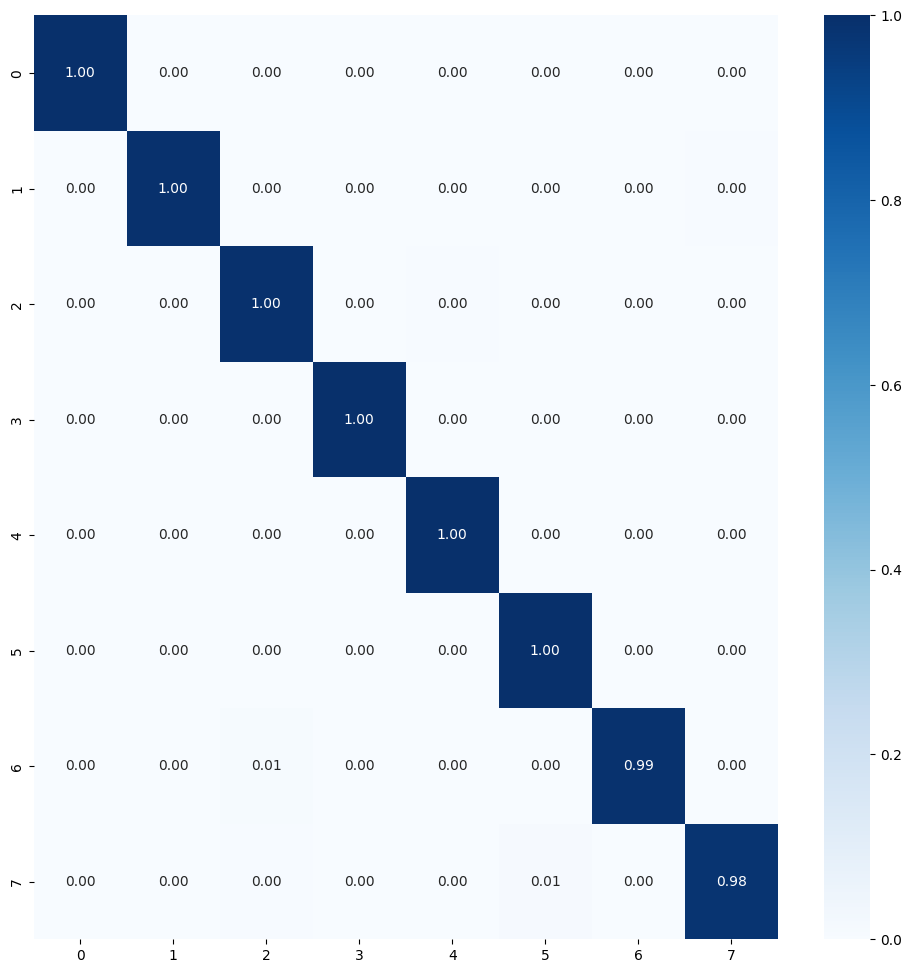


Best fold was 1 with val_accuracy: 0.9961
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.9956473350524903

Test Metrics
test_acc_list: [0.995555579662323, 0.995555579662323, 0.995555579662323, 0.995555579662323, 0.995555579662323]
Average Test Accuracy with 5-fold: 0.995555579662323
test_loss_list: [0.04362427443265915, 0.044304948300123215, 0.04333743453025818, 0.043024927377700806, 0.043974827975034714]
Average Test Log Loss with 5-fold: 0.043653282523155215

Precision List: [0.9955871203708444, 0.9955871203708444, 0.9955871203708444, 0.9955871203708444, 0.9955871203708444]
Average Precision List with 5-fold: 0.9955871203708444
Recall List: [0.9955555555555555, 0.9955555555555555, 0.9955555555555555, 0.9955555555555555, 0.9955555555555555]
Average Recall List with 5-fold: 0.9955555555555555
F1 Score List: [0.9955541864360313, 0.9955541864360313, 0.9955541864360313, 0.9955541864360313, 0.9955541864360313]
Average F1 Score List with 5-fold: 0.995554

In [35]:
%%time

num_classes = 8
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/9
name_save_model: MobileNet_tf_15009
Found 9450 images belonging to 9 classes.
Found 2025 images belonging to 9 classes.
Found 2025 images belonging to 9 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15009_best.h5
Loading pre-trained model...
Model loaded successfully.

Calculating layer importance (once for all folds)...

Calculando importancia con 9450 muestras (100% confianza, ±0% error)
Incluyendo 93 capas (base + personalizadas)


100%|██████████| 9450/9450 [21:20<00:00,  7.38it/s]



Resultados de importancia de capas (incluyendo personalizadas):
----------------------------------------------------------------------
Pos.  | Nombre de Capa                           | Importancia    
----------------------------------------------------------------------
1     | conv_pw_1                                | 0.0008404
2     | conv_dw_1                                | 0.0007927
3     | conv_pw_3                                | 0.0007436
4     | conv_dw_1_bn                             | 0.0006340
5     | conv_pw_2                                | 0.0003988
6     | conv_dw_2_bn                             | 0.0003907
7     | conv_pw_3_bn                             | 0.0003873
8     | conv_dw_4_bn                             | 0.0003580
9     | conv_dw_3_bn                             | 0.0003479
10    | conv1_bn                                 | 0.0003380
11    | conv_pw_4                                | 0.0003310
12    | conv_pw_1_bn                             | 0.00

History for fold 1 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15009_1.pkl
296/296 [==============================] - 19s 63ms/step - loss: 0.0080 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.00804138369858265
64/64 [==============================] - 4s 59ms/step - loss: 0.0375 - accuracy: 0.9951
Validation Accuracy: 0.9950617551803589
Validation Log Loss: 0.03745388984680176
64/64 [==============================] - 4s 60ms/step - loss: 0.0359 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.03594779223203659
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1]
 [  0   0   0 225   0   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0]
 [  0   0   0   0   0   0 224   0   1]
 [  0   0  

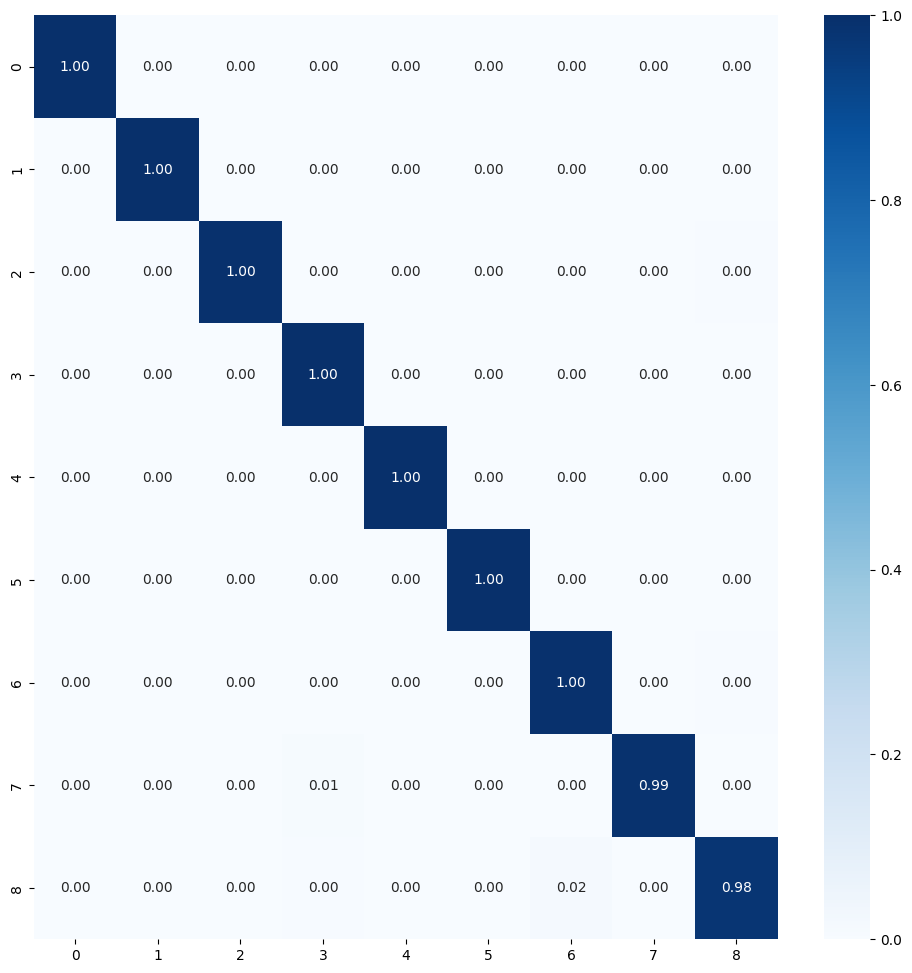


TRAINING AND EVALUATING FOLD 2/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
295/295 [==============================] - 24s 74ms/step - loss: 0.0091 - accuracy: 0.9997 - val_loss: 0.0377 - val_accuracy: 0.9950 - lr: 1.0000e-05
Epoch 2/50
295/295 [==============================] - 22s 73ms/step - loss: 0.0103 - accuracy: 0.9994 - val_loss: 0.0372 - val_accuracy: 0.9960 - lr: 1.0000e-05
Epoch 3/50
295/295 [==============================] - 22s 74ms/step - loss: 0.0083 - accuracy: 0.9999 - val_loss: 0.0355 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 4/50
295/295 [==============================] - 21s 72ms/step - loss: 0.0089 - accuracy: 0.9998 - val_loss: 0.0355 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 5/50
295/295 [==============================] - 20s 69ms/step - loss: 0.0082 - accuracy: 1.0000 - val_loss: 0.0360 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 6/50
295/295 [==============================] -

History for fold 2 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15009_2.pkl
296/296 [==============================] - 17s 58ms/step - loss: 0.0080 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.008042633533477783
64/64 [==============================] - 4s 60ms/step - loss: 0.0379 - accuracy: 0.9951
Validation Accuracy: 0.9950617551803589
Validation Log Loss: 0.03792634233832359
64/64 [==============================] - 4s 59ms/step - loss: 0.0351 - accuracy: 0.9960
Test Accuracy: 0.9960494041442871
Test Log Loss: 0.03505687415599823
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1]
 [  0   0   0 225   0   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0]
 [  0   0   0   0   0   0 224   0   1]
 [  0   0

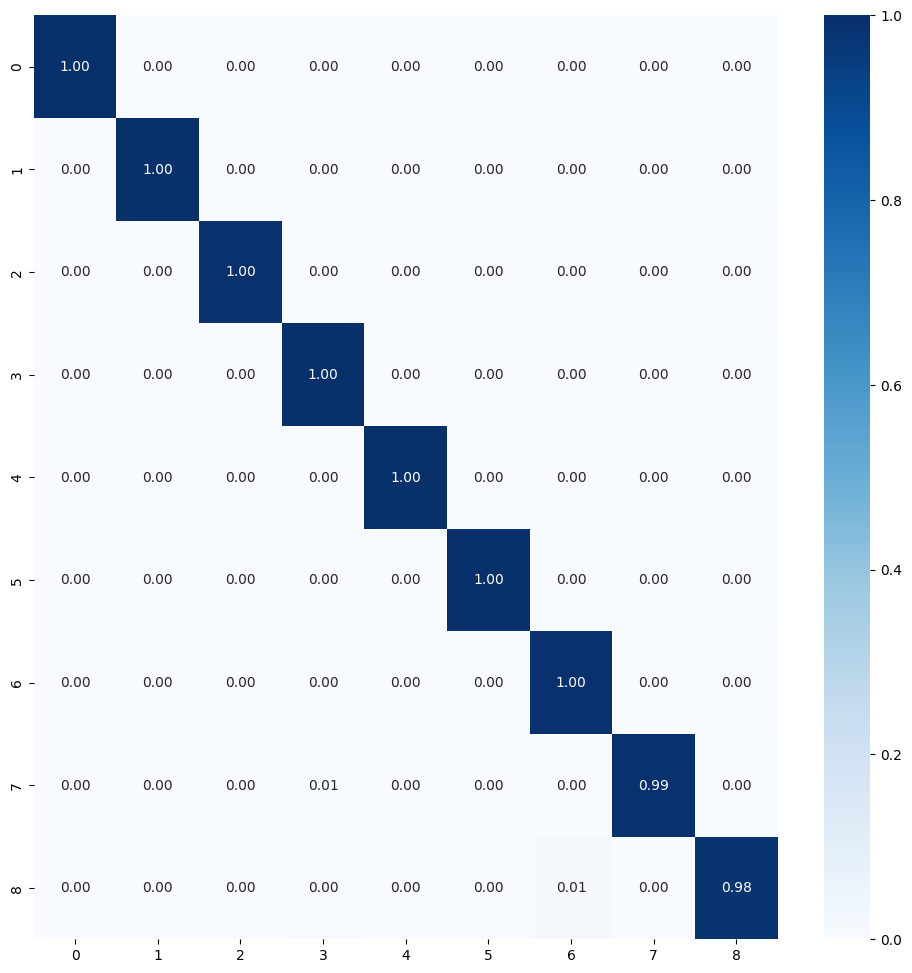


TRAINING AND EVALUATING FOLD 3/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
295/295 [==============================] - 25s 72ms/step - loss: 0.0100 - accuracy: 0.9993 - val_loss: 0.0369 - val_accuracy: 0.9950 - lr: 1.0000e-05
Epoch 2/50
295/295 [==============================] - 21s 72ms/step - loss: 0.0083 - accuracy: 1.0000 - val_loss: 0.0369 - val_accuracy: 0.9950 - lr: 1.0000e-05
Epoch 3/50
295/295 [==============================] - 21s 72ms/step - loss: 0.0082 - accuracy: 1.0000 - val_loss: 0.0368 - val_accuracy: 0.9950 - lr: 1.0000e-05
Epoch 4/50
295/295 [==============================] - 19s 66ms/step - loss: 0.0082 - accuracy: 1.0000 - val_loss: 0.0364 - val_accuracy: 0.9950 - lr: 1.0000e-05
Epoch 5/50
295/295 [==============================] - 21s 72ms/step - loss: 0.0082 - accuracy: 1.0000 - val_loss: 0.0369 - val_accuracy: 0.9950 - lr: 1.0000e-05
Epoch 6/50
295/295 [==============================] -

History for fold 3 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15009_3.pkl
296/296 [==============================] - 18s 61ms/step - loss: 0.0080 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.008039940148591995
64/64 [==============================] - 7s 107ms/step - loss: 0.0379 - accuracy: 0.9951
Validation Accuracy: 0.9950617551803589
Validation Log Loss: 0.0378560870885849
64/64 [==============================] - 3s 52ms/step - loss: 0.0356 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.035649992525577545
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1]
 [  0   0   0 225   0   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0]
 [  0   0   0   0   0   0 224   0   1]
 [  0   0

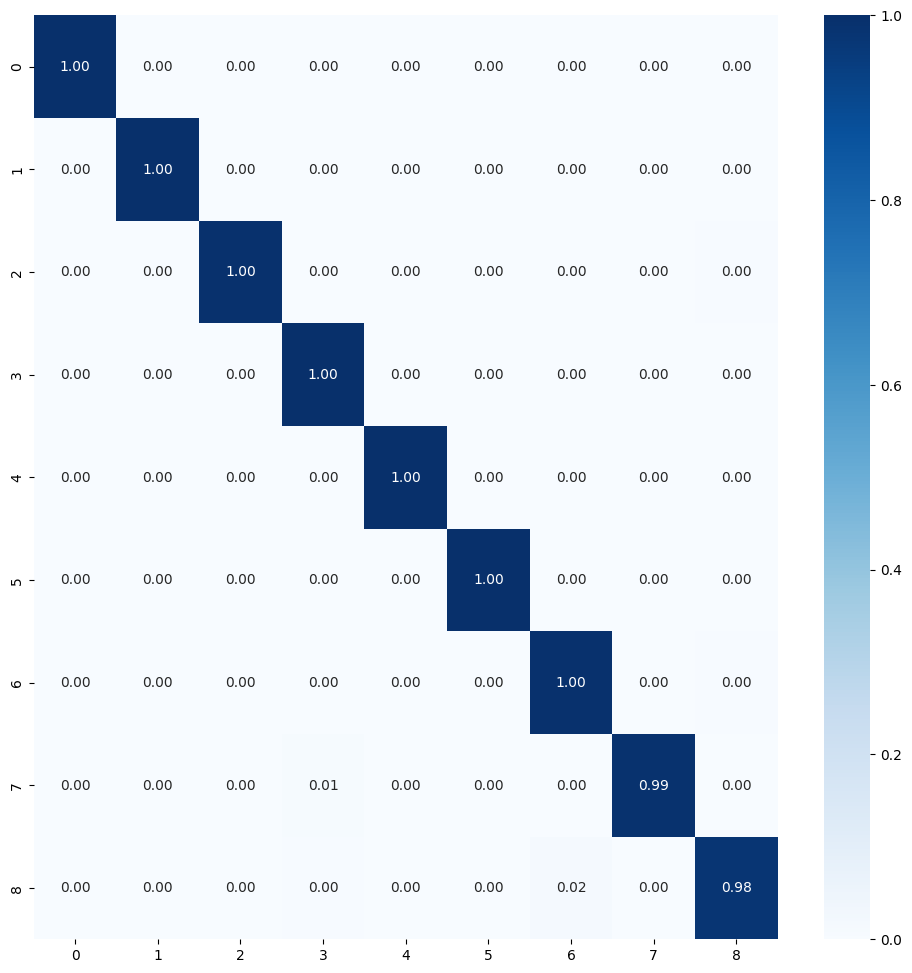


TRAINING AND EVALUATING FOLD 4/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
295/295 [==============================] - 25s 77ms/step - loss: 0.0088 - accuracy: 0.9998 - val_loss: 0.0356 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 2/50
295/295 [==============================] - 24s 82ms/step - loss: 0.0089 - accuracy: 0.9997 - val_loss: 0.0349 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 3/50
295/295 [==============================] - 22s 73ms/step - loss: 0.0083 - accuracy: 1.0000 - val_loss: 0.0365 - val_accuracy: 0.9950 - lr: 1.0000e-05
Epoch 4/50
295/295 [==============================] - 22s 74ms/step - loss: 0.0082 - accuracy: 1.0000 - val_loss: 0.0364 - val_accuracy: 0.9950 - lr: 1.0000e-05
Epoch 5/50
295/295 [==============================] - 21s 72ms/step - loss: 0.0082 - accuracy: 1.0000 - val_loss: 0.0358 - val_accuracy: 0.9950 - lr: 1.0000e-05
Epoch 6/50
295/295 [==============================] -

History for fold 4 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15009_4.pkl
296/296 [==============================] - 17s 58ms/step - loss: 0.0081 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.008051780052483082
64/64 [==============================] - 4s 59ms/step - loss: 0.0385 - accuracy: 0.9946
Validation Accuracy: 0.9945679306983948
Validation Log Loss: 0.03854060173034668
64/64 [==============================] - 4s 61ms/step - loss: 0.0350 - accuracy: 0.9960
Test Accuracy: 0.9960494041442871
Test Log Loss: 0.034973420202732086
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1]
 [  0   0   0 225   0   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0]
 [  0   0   0   0   0   0 225   0   0]
 [  0   

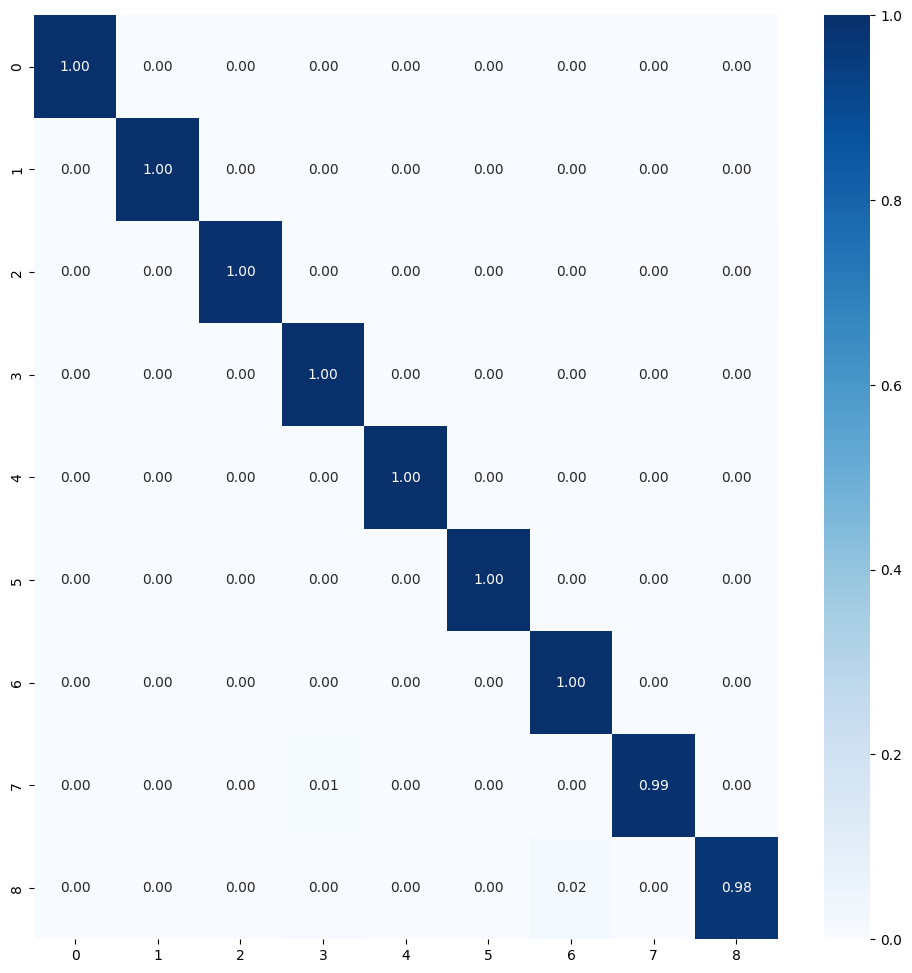


TRAINING AND EVALUATING FOLD 5/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
295/295 [==============================] - 25s 78ms/step - loss: 0.0086 - accuracy: 0.9999 - val_loss: 0.0376 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 2/50
295/295 [==============================] - 22s 74ms/step - loss: 0.0082 - accuracy: 1.0000 - val_loss: 0.0326 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 3/50
295/295 [==============================] - 21s 73ms/step - loss: 0.0102 - accuracy: 0.9994 - val_loss: 0.0370 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 4/50
295/295 [==============================] - 22s 73ms/step - loss: 0.0087 - accuracy: 0.9999 - val_loss: 0.0364 - val_accuracy: 0.9955 - lr: 1.0000e-05
Epoch 5/50
295/295 [==============================] - 21s 71ms/step - loss: 0.0083 - accuracy: 1.0000 - val_loss: 0.0379 - val_accuracy: 0.9950 - lr: 1.0000e-05
Epoch 6/50
295/295 [==============================] -

History for fold 5 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_15009_5.pkl
296/296 [==============================] - 17s 58ms/step - loss: 0.0080 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.00803955364972353
64/64 [==============================] - 4s 61ms/step - loss: 0.0376 - accuracy: 0.9951
Validation Accuracy: 0.9950617551803589
Validation Log Loss: 0.03762767091393471
64/64 [==============================] - 4s 58ms/step - loss: 0.0350 - accuracy: 0.9960
Test Accuracy: 0.9960494041442871
Test Log Loss: 0.03497088700532913
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1]
 [  0   0   0 225   0   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0]
 [  0   0   0   0   0   0 225   0   0]
 [  0   0 

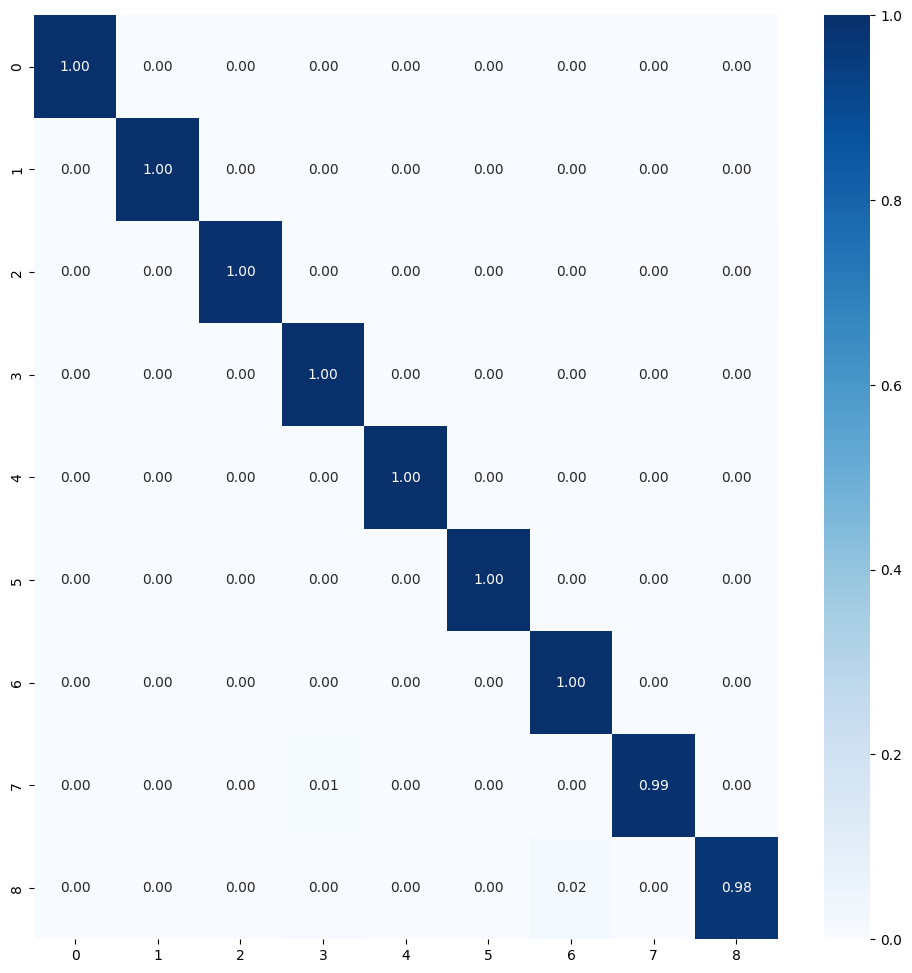


Best fold was 1 with val_accuracy: 0.9960
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.9958333492279052

Test Metrics
test_acc_list: [0.995555579662323, 0.9960494041442871, 0.995555579662323, 0.9960494041442871, 0.9960494041442871]
Average Test Accuracy with 5-fold: 0.9958518743515015
test_loss_list: [0.03594779223203659, 0.03505687415599823, 0.035649992525577545, 0.034973420202732086, 0.03497088700532913]
Average Test Log Loss with 5-fold: 0.03531979322433472

Precision List: [0.995587692956114, 0.9960730707074278, 0.995587692956114, 0.9960944410530037, 0.9960944410530037]
Average Precision List with 5-fold: 0.9958874677451327
Recall List: [0.9955555555555556, 0.9960493827160496, 0.9955555555555556, 0.9960493827160494, 0.9960493827160494]
Average Recall List with 5-fold: 0.9958518518518519
F1 Score List: [0.9955542825984587, 0.996049290174693, 0.9955542825984587, 0.9960469487501986, 0.9960469487501986]
Average F1 Score List with 5-fold: 0.9958503

In [36]:
%%time

num_classes = 9
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/10
name_save_model: MobileNet_tf_150010
Found 10500 images belonging to 10 classes.
Found 2250 images belonging to 10 classes.
Found 2250 images belonging to 10 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150010_best.h5
Loading pre-trained model...
Model loaded successfully.

Calculating layer importance (once for all folds)...

Calculando importancia con 10500 muestras (100% confianza, ±0% error)
Incluyendo 93 capas (base + personalizadas)


100%|██████████| 10500/10500 [22:54<00:00,  7.64it/s]



Resultados de importancia de capas (incluyendo personalizadas):
----------------------------------------------------------------------
Pos.  | Nombre de Capa                           | Importancia    
----------------------------------------------------------------------
1     | conv_pw_1                                | 0.0643220
2     | conv_pw_3                                | 0.0559791
3     | conv_dw_1                                | 0.0475976
4     | conv_dw_1_bn                             | 0.0398559
5     | conv_pw_2                                | 0.0359689
6     | conv_dw_2_bn                             | 0.0313630
7     | conv_pw_3_bn                             | 0.0277420
8     | conv_dw_3_bn                             | 0.0262378
9     | conv1_bn                                 | 0.0261003
10    | conv_dw_4_bn                             | 0.0260812
11    | conv_pw_1_bn                             | 0.0255630
12    | conv_pw_4                                | 0.02

History for fold 1 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150010_1.pkl
329/329 [==============================] - 21s 63ms/step - loss: 0.0399 - accuracy: 0.9999
Train Accuracy: 0.9999047517776489
Train Log Loss: 0.03990872576832771
71/71 [==============================] - 4s 59ms/step - loss: 0.1931 - accuracy: 0.9711
Validation Accuracy: 0.9711111187934875
Validation Log Loss: 0.1931070238351822
71/71 [==============================] - 4s 56ms/step - loss: 0.1747 - accuracy: 0.9733
Test Accuracy: 0.9733333587646484
Test Log Loss: 0.1747092753648758
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1]
 [  0   0   0 223   0   0   0   0   0   2]
 [  0   0   0   0 218   0   0   0   0   7]
 [  0   0   0   0   0 224   0   0   0   

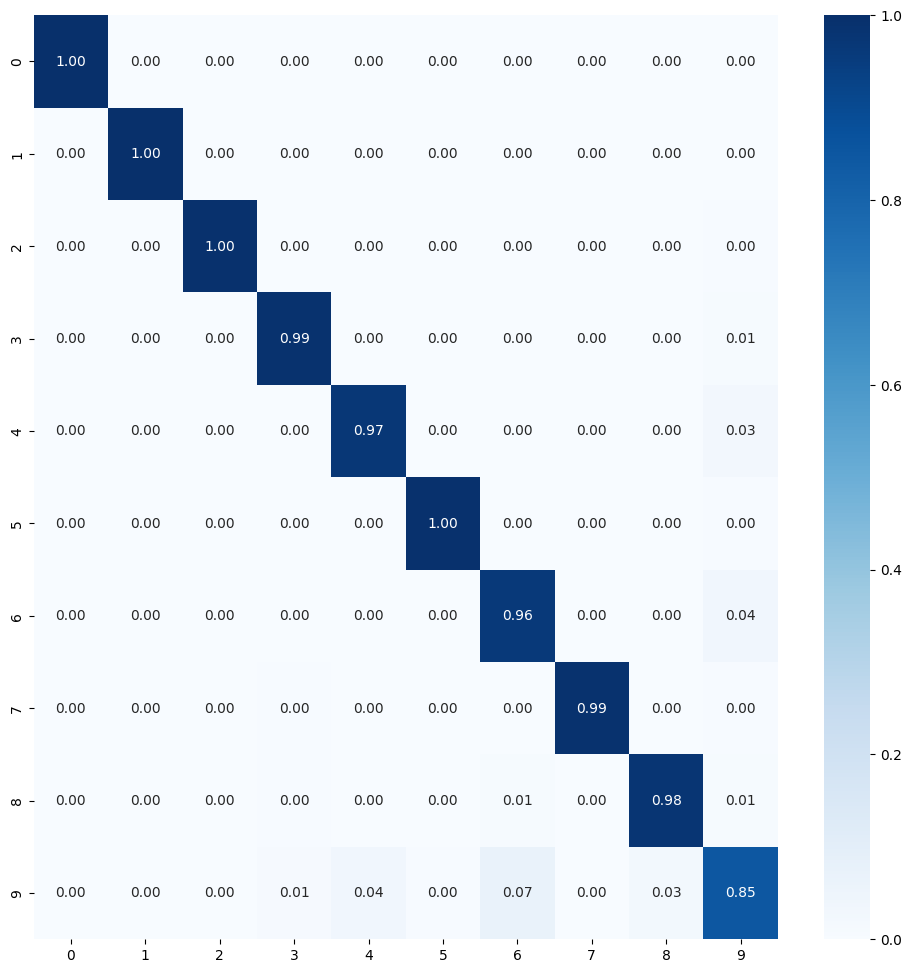


TRAINING AND EVALUATING FOLD 2/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
328/328 [==============================] - 27s 77ms/step - loss: 0.0472 - accuracy: 0.9981 - val_loss: 0.1944 - val_accuracy: 0.9692 - lr: 1.0000e-05
Epoch 2/50
328/328 [==============================] - 25s 76ms/step - loss: 0.0437 - accuracy: 0.9986 - val_loss: 0.1971 - val_accuracy: 0.9692 - lr: 1.0000e-05
Epoch 3/50
328/328 [==============================] - 23s 70ms/step - loss: 0.0465 - accuracy: 0.9979 - val_loss: 0.2047 - val_accuracy: 0.9710 - lr: 1.0000e-05
Epoch 4/50
328/328 [==============================] - 23s 71ms/step - loss: 0.0452 - accuracy: 0.9984 - val_loss: 0.1950 - val_accuracy: 0.9701 - lr: 1.0000e-05
Epoch 5/50
328/328 [==============================] - 23s 70ms/step - loss: 0.0435 - accuracy: 0.9992 - val_loss: 0.1977 - val_accuracy: 0.9719 - lr: 1.0000e-05
Epoch 6/50
328/328 [==============================] -

History for fold 2 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150010_2.pkl
329/329 [==============================] - 20s 61ms/step - loss: 0.0400 - accuracy: 0.9998
Train Accuracy: 0.9998095035552979
Train Log Loss: 0.03997776284813881
71/71 [==============================] - 4s 57ms/step - loss: 0.1928 - accuracy: 0.9711
Validation Accuracy: 0.9711111187934875
Validation Log Loss: 0.1928023397922516
71/71 [==============================] - 4s 60ms/step - loss: 0.1765 - accuracy: 0.9733
Test Accuracy: 0.9733333587646484
Test Log Loss: 0.17652447521686554
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1]
 [  0   0   0 223   0   0   0   0   0   2]
 [  0   0   0   0 218   0   0   0   0   7]
 [  0   0   0   0   0 223   0   0   0  

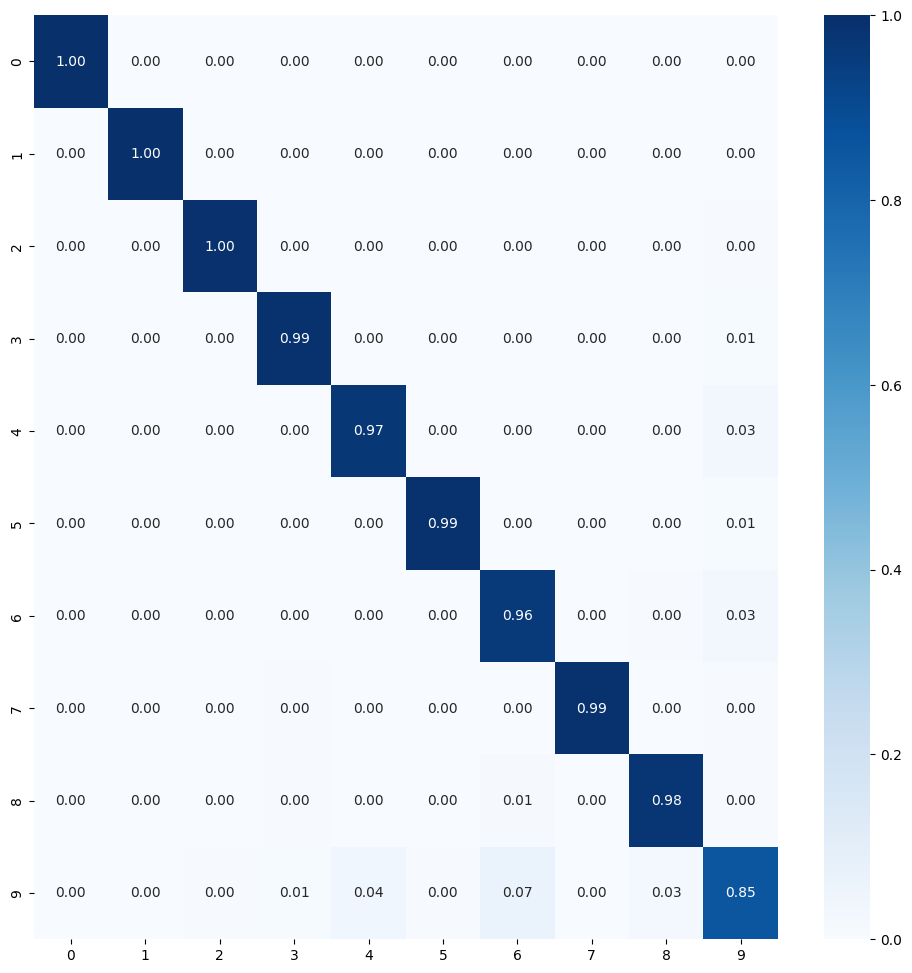


TRAINING AND EVALUATING FOLD 3/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
328/328 [==============================] - 27s 74ms/step - loss: 0.0476 - accuracy: 0.9976 - val_loss: 0.2065 - val_accuracy: 0.9696 - lr: 1.0000e-05
Epoch 2/50
328/328 [==============================] - 23s 71ms/step - loss: 0.0455 - accuracy: 0.9989 - val_loss: 0.1970 - val_accuracy: 0.9705 - lr: 1.0000e-05
Epoch 3/50
328/328 [==============================] - 24s 72ms/step - loss: 0.0441 - accuracy: 0.9988 - val_loss: 0.1995 - val_accuracy: 0.9714 - lr: 1.0000e-05
Epoch 4/50
328/328 [==============================] - 23s 71ms/step - loss: 0.0544 - accuracy: 0.9959 - val_loss: 0.1954 - val_accuracy: 0.9692 - lr: 1.0000e-05
Epoch 5/50
328/328 [==============================] - 23s 70ms/step - loss: 0.0445 - accuracy: 0.9991 - val_loss: 0.1958 - val_accuracy: 0.9705 - lr: 1.0000e-05
Epoch 6/50
328/328 [==============================] -

History for fold 3 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150010_3.pkl
329/329 [==============================] - 19s 58ms/step - loss: 0.0400 - accuracy: 0.9998
Train Accuracy: 0.9998095035552979
Train Log Loss: 0.0399617925286293
71/71 [==============================] - 4s 57ms/step - loss: 0.1911 - accuracy: 0.9707
Validation Accuracy: 0.9706666469573975
Validation Log Loss: 0.19105824828147888
71/71 [==============================] - 4s 59ms/step - loss: 0.1755 - accuracy: 0.9738
Test Accuracy: 0.9737777709960938
Test Log Loss: 0.17553691565990448
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1]
 [  0   0   0 223   0   0   0   0   0   2]
 [  0   0   0   0 218   0   0   0   0   7]
 [  0   0   0   0   0 224   0   0   0  

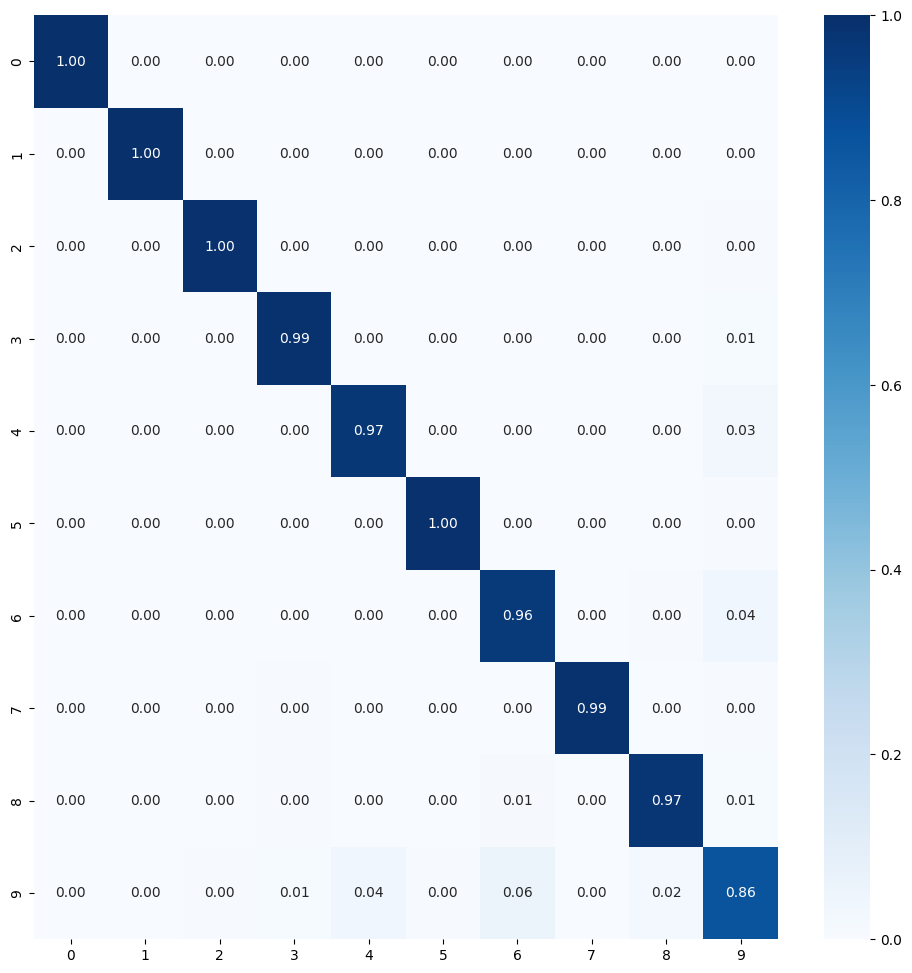


TRAINING AND EVALUATING FOLD 4/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
328/328 [==============================] - 27s 75ms/step - loss: 0.0459 - accuracy: 0.9985 - val_loss: 0.2006 - val_accuracy: 0.9665 - lr: 1.0000e-05
Epoch 2/50
328/328 [==============================] - 25s 76ms/step - loss: 0.0456 - accuracy: 0.9980 - val_loss: 0.1976 - val_accuracy: 0.9688 - lr: 1.0000e-05
Epoch 3/50
328/328 [==============================] - 23s 70ms/step - loss: 0.0438 - accuracy: 0.9989 - val_loss: 0.1985 - val_accuracy: 0.9719 - lr: 1.0000e-05
Epoch 4/50
328/328 [==============================] - 25s 76ms/step - loss: 0.0431 - accuracy: 0.9994 - val_loss: 0.1988 - val_accuracy: 0.9696 - lr: 1.0000e-05
Epoch 5/50
328/328 [==============================] - 24s 72ms/step - loss: 0.0426 - accuracy: 0.9995 - val_loss: 0.1970 - val_accuracy: 0.9705 - lr: 1.0000e-05
Epoch 6/50
328/328 [==============================] -

History for fold 4 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150010_4.pkl
329/329 [==============================] - 20s 61ms/step - loss: 0.0399 - accuracy: 0.9998
Train Accuracy: 0.9998095035552979
Train Log Loss: 0.039946820586919785
71/71 [==============================] - 4s 60ms/step - loss: 0.1920 - accuracy: 0.9720
Validation Accuracy: 0.972000002861023
Validation Log Loss: 0.1919732242822647
71/71 [==============================] - 5s 61ms/step - loss: 0.1767 - accuracy: 0.9733
Test Accuracy: 0.9733333587646484
Test Log Loss: 0.17670488357543945
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1]
 [  0   0   0 223   0   0   0   0   0   2]
 [  0   0   0   0 218   0   0   0   0   7]
 [  0   0   0   0   0 223   0   0   0  

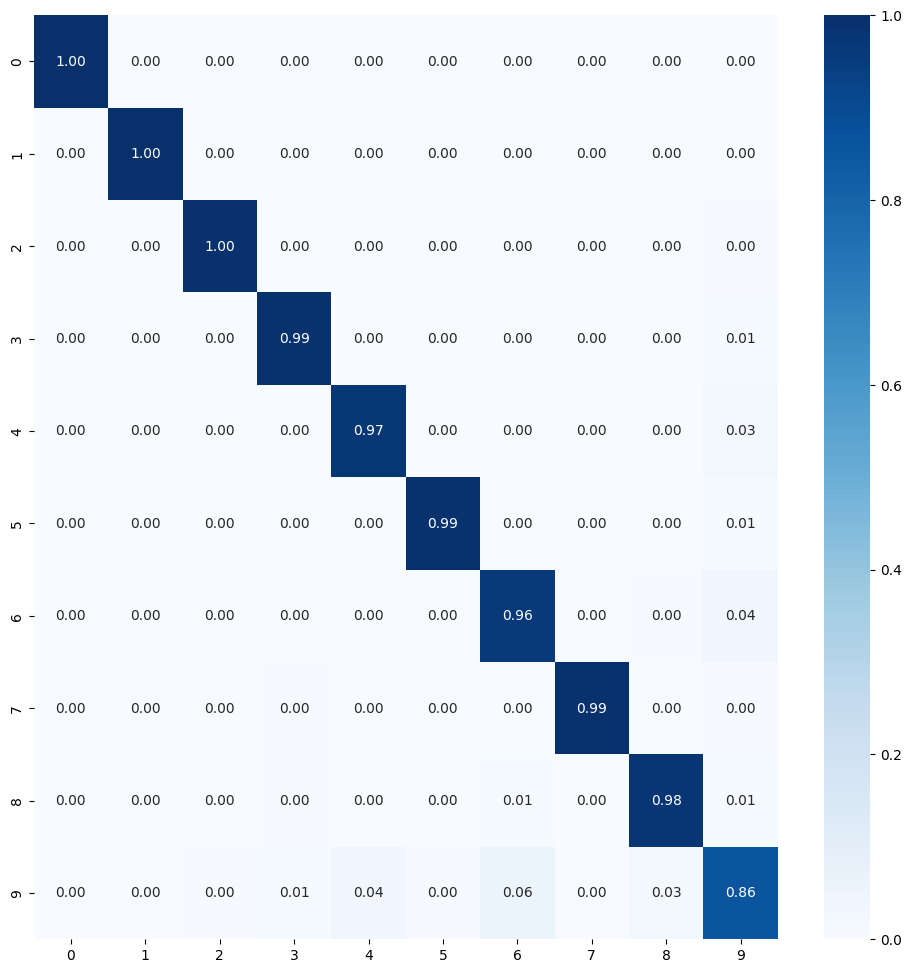


TRAINING AND EVALUATING FOLD 5/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
328/328 [==============================] - 27s 76ms/step - loss: 0.0472 - accuracy: 0.9980 - val_loss: 0.2054 - val_accuracy: 0.9710 - lr: 1.0000e-05
Epoch 2/50
328/328 [==============================] - 24s 74ms/step - loss: 0.0508 - accuracy: 0.9968 - val_loss: 0.2024 - val_accuracy: 0.9701 - lr: 1.0000e-05
Epoch 3/50
328/328 [==============================] - 24s 73ms/step - loss: 0.0438 - accuracy: 0.9991 - val_loss: 0.1986 - val_accuracy: 0.9719 - lr: 1.0000e-05
Epoch 4/50
328/328 [==============================] - 24s 74ms/step - loss: 0.0428 - accuracy: 0.9995 - val_loss: 0.1986 - val_accuracy: 0.9719 - lr: 1.0000e-05
Epoch 5/50
328/328 [==============================] - 24s 74ms/step - loss: 0.0427 - accuracy: 0.9994 - val_loss: 0.1941 - val_accuracy: 0.9714 - lr: 1.0000e-05
Epoch 6/50
328/328 [==============================] -

History for fold 5 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150010_5.pkl
329/329 [==============================] - 20s 60ms/step - loss: 0.0399 - accuracy: 0.9999
Train Accuracy: 0.9999047517776489
Train Log Loss: 0.03992745280265808
71/71 [==============================] - 4s 60ms/step - loss: 0.1917 - accuracy: 0.9711
Validation Accuracy: 0.9711111187934875
Validation Log Loss: 0.19168724119663239
71/71 [==============================] - 4s 59ms/step - loss: 0.1750 - accuracy: 0.9729
Test Accuracy: 0.9728888869285583
Test Log Loss: 0.175044447183609
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1]
 [  0   0   0 223   0   0   0   0   0   2]
 [  0   0   0   0 218   0   0   0   0   7]
 [  0   0   0   0   0 223   0   0   0   

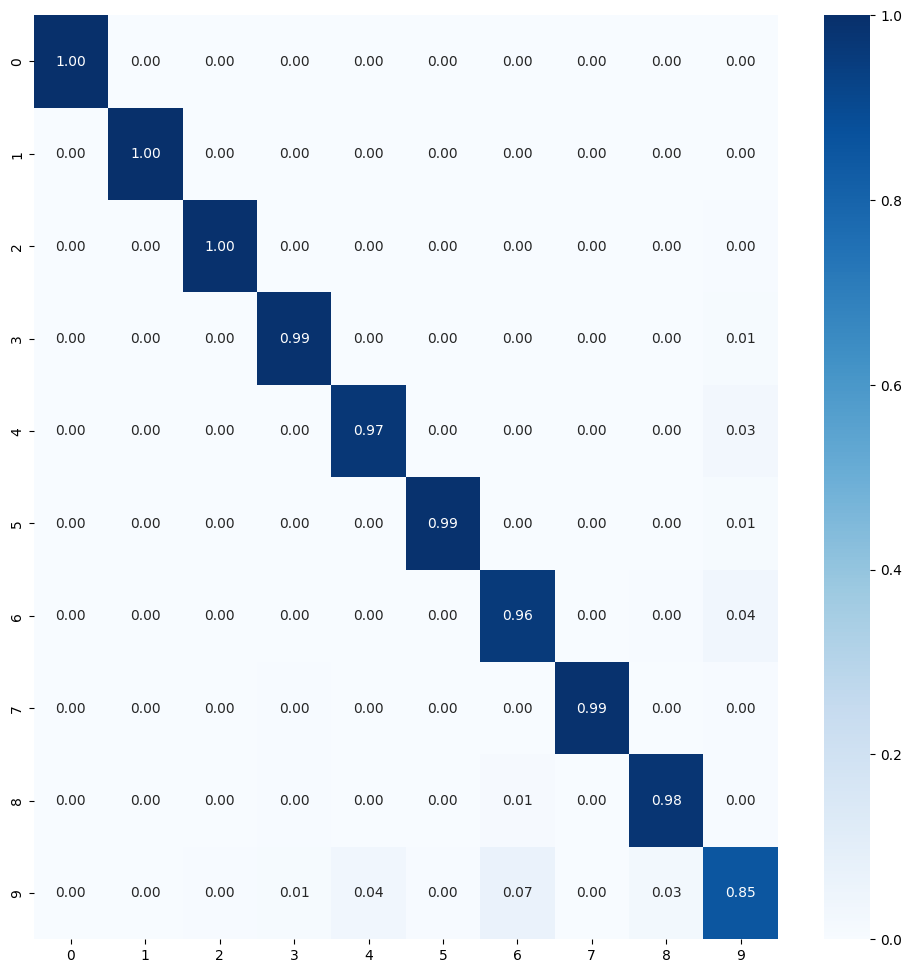


Best fold was 1 with val_accuracy: 0.9741
Average training accuracy in 5-fold: 0.999904453754425
Average validation precision in 5-fold: 0.9730357170104981

Test Metrics
test_acc_list: [0.9733333587646484, 0.9733333587646484, 0.9737777709960938, 0.9733333587646484, 0.9728888869285583]
Average Test Accuracy with 5-fold: 0.9733333468437195
test_loss_list: [0.1747092753648758, 0.17652447521686554, 0.17553691565990448, 0.17670488357543945, 0.175044447183609]
Average Test Log Loss with 5-fold: 0.17570399940013887

Precision List: [0.9731796698681908, 0.9732047595996413, 0.9736611843739091, 0.9731787891250179, 0.9727508074732205]
Average Precision List with 5-fold: 0.9731950420879958
Recall List: [0.9733333333333333, 0.9733333333333334, 0.9737777777777777, 0.9733333333333334, 0.9728888888888889]
Average Recall List with 5-fold: 0.9733333333333334
F1 Score List: [0.9731386271902981, 0.973151791264846, 0.973649643409599, 0.9731906174537794, 0.9727219055559004]
Average F1 Score List with 5-fol

In [37]:
%%time

num_classes = 10
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/11
name_save_model: MobileNet_tf_150011
Found 11550 images belonging to 11 classes.
Found 2475 images belonging to 11 classes.
Found 2475 images belonging to 11 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150011_best.h5
Loading pre-trained model...
Model loaded successfully.

Calculating layer importance (once for all folds)...

Calculando importancia con 11550 muestras (100% confianza, ±0% error)
Incluyendo 93 capas (base + personalizadas)


100%|██████████| 11550/11550 [25:07<00:00,  7.66it/s]



Resultados de importancia de capas (incluyendo personalizadas):
----------------------------------------------------------------------
Pos.  | Nombre de Capa                           | Importancia    
----------------------------------------------------------------------
1     | conv_pw_1                                | 0.0278747
2     | conv_dw_1                                | 0.0229879
3     | conv_pw_3                                | 0.0221918
4     | conv_dw_1_bn                             | 0.0166152
5     | conv_pw_2                                | 0.0142917
6     | conv_dw_2_bn                             | 0.0131785
7     | conv_pw_3_bn                             | 0.0108678
8     | conv_pw_1_bn                             | 0.0106764
9     | conv_dw_3_bn                             | 0.0106455
10    | conv1_bn                                 | 0.0106372
11    | conv_dw_4_bn                             | 0.0099390
12    | conv_pw_4                                | 0.00

History for fold 1 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150011_1.pkl
361/361 [==============================] - 19s 52ms/step - loss: 0.0605 - accuracy: 0.9973
Train Accuracy: 0.9973160028457642
Train Log Loss: 0.0604989118874073
78/78 [==============================] - 5s 61ms/step - loss: 0.2711 - accuracy: 0.9495
Validation Accuracy: 0.9494949579238892
Validation Log Loss: 0.27105119824409485
78/78 [==============================] - 5s 60ms/step - loss: 0.2584 - accuracy: 0.9523
Test Accuracy: 0.9523232579231262
Test Log Loss: 0.25840556621551514
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1   0]
 [  0   0   0 218   1   1   1   1   0   0   3]
 [  0   0   0   0 199   9   0   0   0   0  17]
 [  0

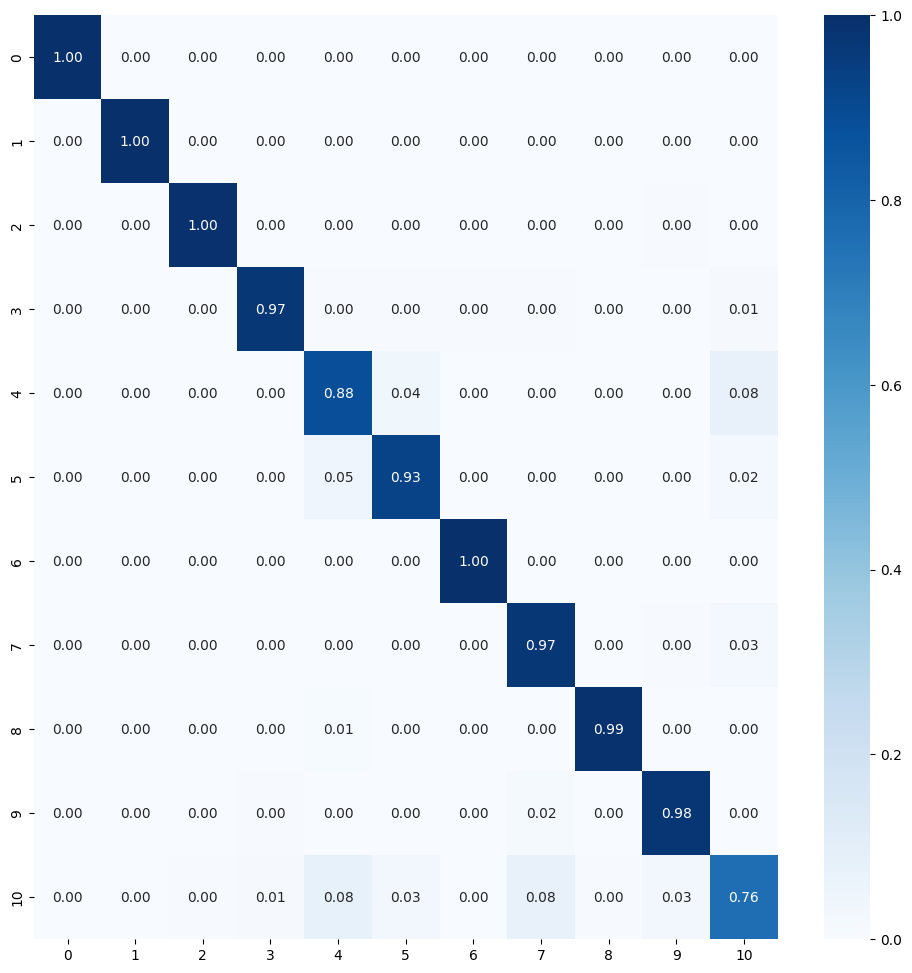


TRAINING AND EVALUATING FOLD 2/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
360/360 [==============================] - 30s 76ms/step - loss: 0.0678 - accuracy: 0.9951 - val_loss: 0.2777 - val_accuracy: 0.9472 - lr: 1.0000e-05
Epoch 2/50
360/360 [==============================] - 26s 73ms/step - loss: 0.0660 - accuracy: 0.9957 - val_loss: 0.2774 - val_accuracy: 0.9468 - lr: 1.0000e-05
Epoch 3/50
360/360 [==============================] - 26s 73ms/step - loss: 0.0668 - accuracy: 0.9957 - val_loss: 0.2727 - val_accuracy: 0.9493 - lr: 1.0000e-05
Epoch 4/50
360/360 [==============================] - 28s 76ms/step - loss: 0.0659 - accuracy: 0.9957 - val_loss: 0.2777 - val_accuracy: 0.9485 - lr: 1.0000e-05
Epoch 5/50
360/360 [==============================] - 26s 72ms/step - loss: 0.0664 - accuracy: 0.9954 - val_loss: 0.2700 - val_accuracy: 0.9481 - lr: 1.0000e-05
Epoch 6/50
360/360 [==============================] -

History for fold 2 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150011_2.pkl
361/361 [==============================] - 22s 61ms/step - loss: 0.0605 - accuracy: 0.9974
Train Accuracy: 0.9974026083946228
Train Log Loss: 0.06046546250581741
78/78 [==============================] - 6s 72ms/step - loss: 0.2715 - accuracy: 0.9503
Validation Accuracy: 0.9503030180931091
Validation Log Loss: 0.2715087831020355
78/78 [==============================] - 5s 62ms/step - loss: 0.2578 - accuracy: 0.9531
Test Accuracy: 0.9531313180923462
Test Log Loss: 0.25784456729888916
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1   0]
 [  0   0   0 218   1   1   1   1   0   0   3]
 [  0   0   0   0 200   9   0   0   0   0  16]
 [  0

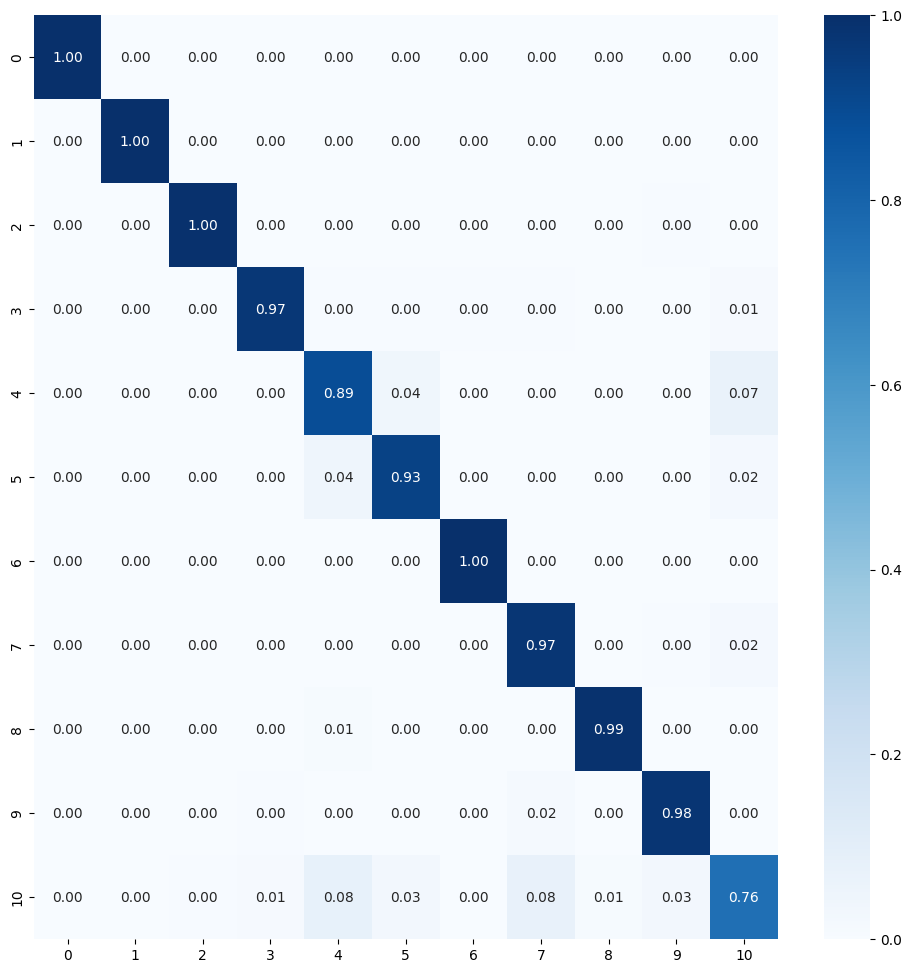


TRAINING AND EVALUATING FOLD 3/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
360/360 [==============================] - 29s 75ms/step - loss: 0.0675 - accuracy: 0.9948 - val_loss: 0.2791 - val_accuracy: 0.9464 - lr: 1.0000e-05
Epoch 2/50
360/360 [==============================] - 26s 73ms/step - loss: 0.0670 - accuracy: 0.9951 - val_loss: 0.2739 - val_accuracy: 0.9460 - lr: 1.0000e-05
Epoch 3/50
360/360 [==============================] - 26s 73ms/step - loss: 0.0659 - accuracy: 0.9954 - val_loss: 0.2772 - val_accuracy: 0.9468 - lr: 1.0000e-05
Epoch 4/50
360/360 [==============================] - 27s 74ms/step - loss: 0.0662 - accuracy: 0.9956 - val_loss: 0.2795 - val_accuracy: 0.9460 - lr: 1.0000e-05
Epoch 5/50
360/360 [==============================] - 26s 71ms/step - loss: 0.0652 - accuracy: 0.9957 - val_loss: 0.2747 - val_accuracy: 0.9472 - lr: 1.0000e-05
Epoch 6/50
360/360 [==============================] -

History for fold 3 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150011_3.pkl
361/361 [==============================] - 22s 60ms/step - loss: 0.0604 - accuracy: 0.9975
Train Accuracy: 0.9974891543388367
Train Log Loss: 0.06043855473399162
78/78 [==============================] - 5s 59ms/step - loss: 0.2723 - accuracy: 0.9491
Validation Accuracy: 0.9490908980369568
Validation Log Loss: 0.27229464054107666
78/78 [==============================] - 5s 59ms/step - loss: 0.2589 - accuracy: 0.9523
Test Accuracy: 0.9523232579231262
Test Log Loss: 0.25889065861701965
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1   0]
 [  0   0   0 218   1   1   1   1   0   0   3]
 [  0   0   0   0 200   9   0   0   0   0  16]
 [  

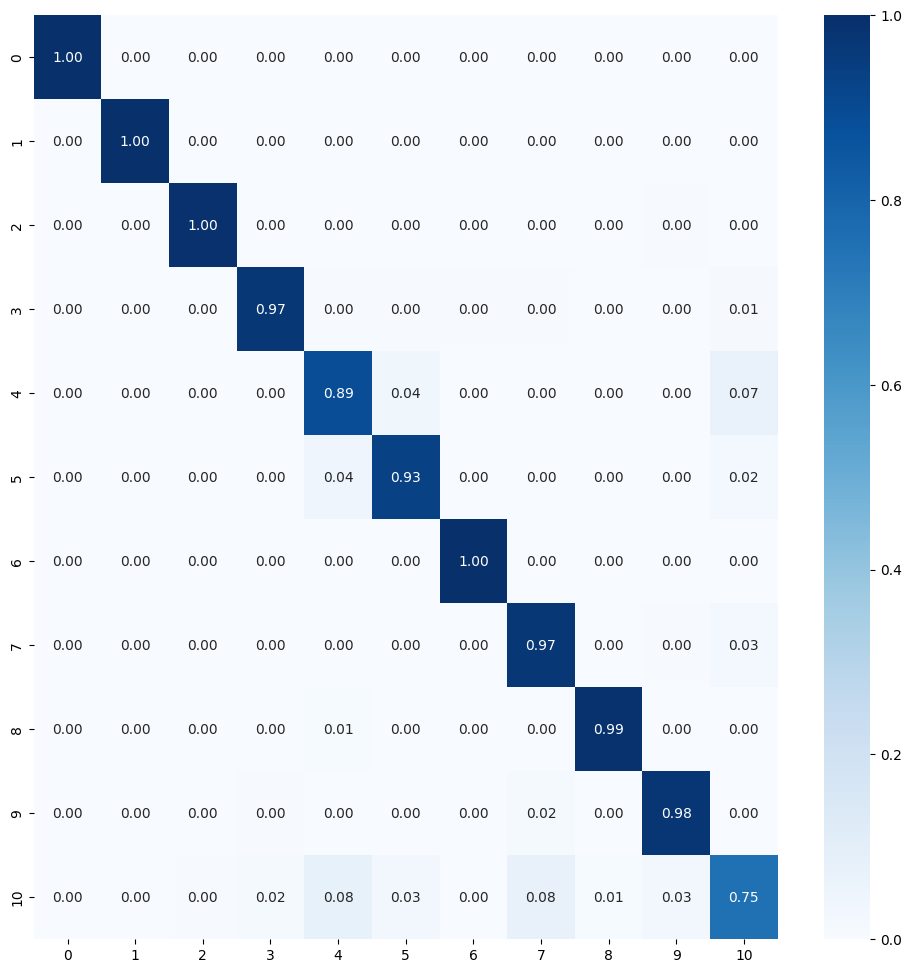


TRAINING AND EVALUATING FOLD 4/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
360/360 [==============================] - 27s 70ms/step - loss: 0.0675 - accuracy: 0.9949 - val_loss: 0.2804 - val_accuracy: 0.9456 - lr: 1.0000e-05
Epoch 2/50
360/360 [==============================] - 27s 74ms/step - loss: 0.0667 - accuracy: 0.9952 - val_loss: 0.2759 - val_accuracy: 0.9468 - lr: 1.0000e-05
Epoch 3/50
360/360 [==============================] - 26s 72ms/step - loss: 0.0659 - accuracy: 0.9958 - val_loss: 0.2801 - val_accuracy: 0.9448 - lr: 1.0000e-05
Epoch 4/50
360/360 [==============================] - 27s 74ms/step - loss: 0.0658 - accuracy: 0.9967 - val_loss: 0.2732 - val_accuracy: 0.9460 - lr: 1.0000e-05
Epoch 5/50
360/360 [==============================] - 27s 74ms/step - loss: 0.0659 - accuracy: 0.9957 - val_loss: 0.2799 - val_accuracy: 0.9460 - lr: 1.0000e-05
Epoch 6/50
360/360 [==============================] -

History for fold 4 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150011_4.pkl
361/361 [==============================] - 22s 60ms/step - loss: 0.0606 - accuracy: 0.9972
Train Accuracy: 0.9972294569015503
Train Log Loss: 0.0606105737388134
78/78 [==============================] - 5s 63ms/step - loss: 0.2720 - accuracy: 0.9491
Validation Accuracy: 0.9490908980369568
Validation Log Loss: 0.27197936177253723
78/78 [==============================] - 5s 59ms/step - loss: 0.2598 - accuracy: 0.9519
Test Accuracy: 0.9519191980361938
Test Log Loss: 0.2598118782043457
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1   0]
 [  0   0   0 218   1   1   1   1   0   0   3]
 [  0   0   0   0 200   9   0   0   0   0  16]
 [  0 

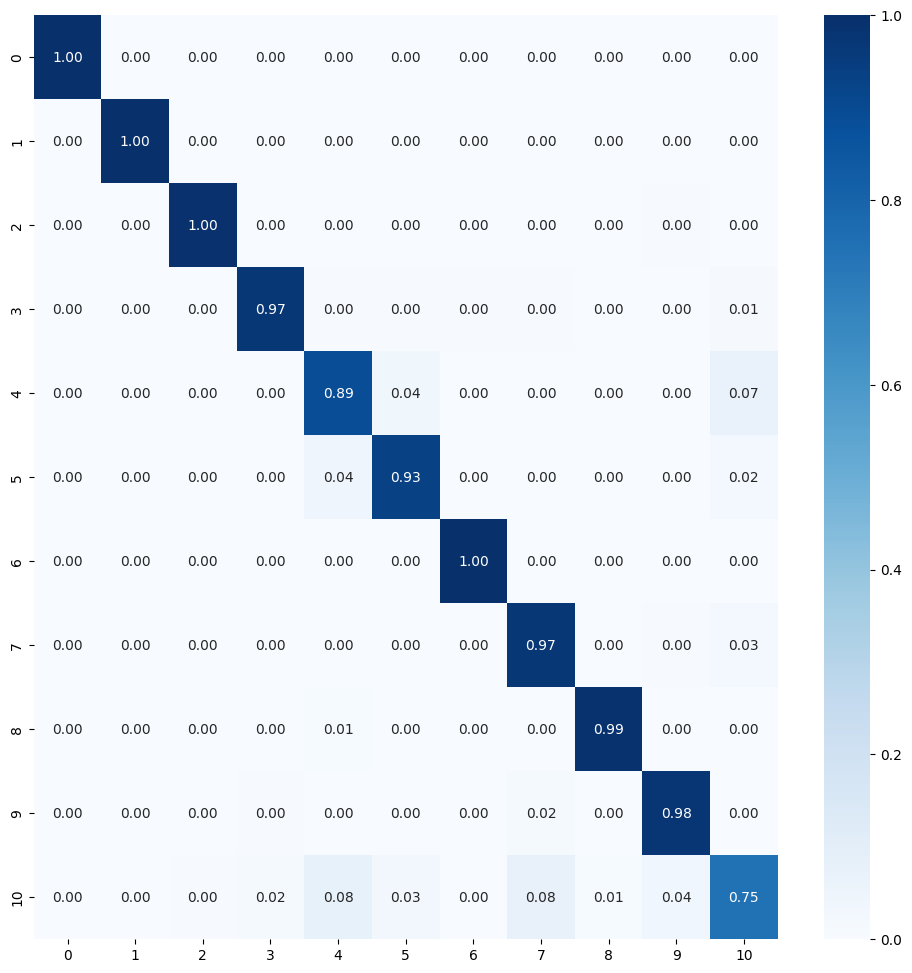


TRAINING AND EVALUATING FOLD 5/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
360/360 [==============================] - 30s 77ms/step - loss: 0.0677 - accuracy: 0.9951 - val_loss: 0.2762 - val_accuracy: 0.9481 - lr: 1.0000e-05
Epoch 2/50
360/360 [==============================] - 27s 75ms/step - loss: 0.0661 - accuracy: 0.9953 - val_loss: 0.2815 - val_accuracy: 0.9452 - lr: 1.0000e-05
Epoch 3/50
360/360 [==============================] - 26s 72ms/step - loss: 0.0660 - accuracy: 0.9957 - val_loss: 0.2732 - val_accuracy: 0.9481 - lr: 1.0000e-05
Epoch 4/50
360/360 [==============================] - 23s 65ms/step - loss: 0.0673 - accuracy: 0.9951 - val_loss: 0.2730 - val_accuracy: 0.9476 - lr: 1.0000e-05
Epoch 5/50
360/360 [==============================] - 27s 74ms/step - loss: 0.0660 - accuracy: 0.9963 - val_loss: 0.2671 - val_accuracy: 0.9481 - lr: 1.0000e-05
Epoch 6/50
360/360 [==============================] -

History for fold 5 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150011_5.pkl
361/361 [==============================] - 23s 63ms/step - loss: 0.0607 - accuracy: 0.9973
Train Accuracy: 0.9973160028457642
Train Log Loss: 0.06067031994462013
78/78 [==============================] - 5s 63ms/step - loss: 0.2717 - accuracy: 0.9499
Validation Accuracy: 0.9498990178108215
Validation Log Loss: 0.27168357372283936
78/78 [==============================] - 5s 63ms/step - loss: 0.2588 - accuracy: 0.9527
Test Accuracy: 0.9527272582054138
Test Log Loss: 0.2587581276893616
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1   0]
 [  0   0   0 218   1   1   1   1   0   0   3]
 [  0   0   0   0 200   9   0   0   0   0  16]
 [  0

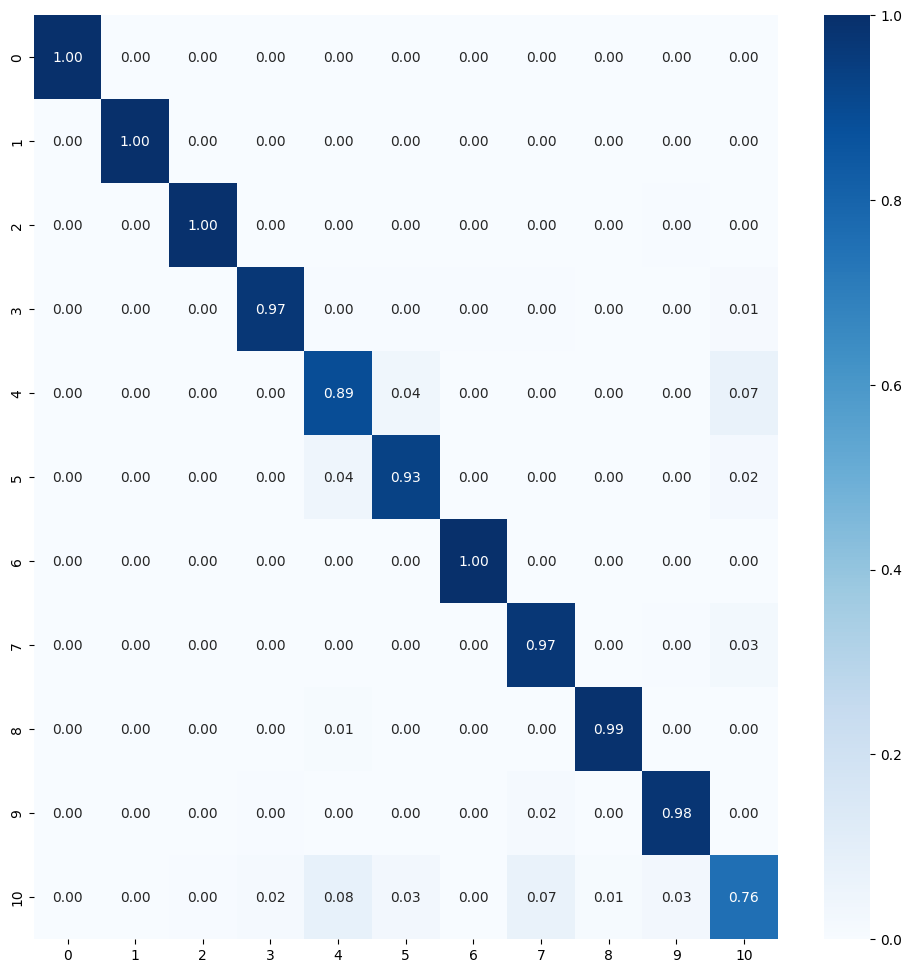


Best fold was 1 with val_accuracy: 0.9509
Average training accuracy in 5-fold: 0.9972912073135376
Average validation precision in 5-fold: 0.9504058480262756

Test Metrics
test_acc_list: [0.9523232579231262, 0.9531313180923462, 0.9523232579231262, 0.9519191980361938, 0.9527272582054138]
Average Test Accuracy with 5-fold: 0.9524848580360412
test_loss_list: [0.25840556621551514, 0.25784456729888916, 0.25889065861701965, 0.2598118782043457, 0.2587581276893616]
Average Test Log Loss with 5-fold: 0.2587421596050262

Precision List: [0.9518605247591825, 0.9526198734121231, 0.9517281468769841, 0.9512792074681818, 0.9521421765791914]
Average Precision List with 5-fold: 0.9519259858191326
Recall List: [0.9523232323232323, 0.9531313131313133, 0.9523232323232323, 0.9519191919191918, 0.9527272727272728]
Average Recall List with 5-fold: 0.9524848484848485
F1 Score List: [0.9517653366584945, 0.9524728494604271, 0.9516388541161362, 0.9511867087754318, 0.952079849797126]
Average F1 Score List with 5-f

In [38]:
%%time

num_classes = 11
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/12
name_save_model: MobileNet_tf_150012
Found 12600 images belonging to 12 classes.
Found 2700 images belonging to 12 classes.
Found 2700 images belonging to 12 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150012_best.h5
Loading pre-trained model...
Model loaded successfully.

Calculating layer importance (once for all folds)...

Calculando importancia con 12600 muestras (100% confianza, ±0% error)
Incluyendo 93 capas (base + personalizadas)


100%|██████████| 12600/12600 [27:45<00:00,  7.56it/s]



Resultados de importancia de capas (incluyendo personalizadas):
----------------------------------------------------------------------
Pos.  | Nombre de Capa                           | Importancia    
----------------------------------------------------------------------
1     | conv_pw_1                                | 0.0142388
2     | conv_dw_1                                | 0.0122774
3     | conv_pw_3                                | 0.0109312
4     | conv_dw_1_bn                             | 0.0081946
5     | conv_pw_2                                | 0.0072423
6     | conv_dw_2_bn                             | 0.0068098
7     | conv_pw_1_bn                             | 0.0054163
8     | conv_pw_3_bn                             | 0.0054019
9     | conv_dw_3_bn                             | 0.0053301
10    | conv1_bn                                 | 0.0052664
11    | conv_dw_4_bn                             | 0.0049497
12    | conv_pw_4                                | 0.00

History for fold 1 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150012_1.pkl
394/394 [==============================] - 25s 62ms/step - loss: 0.0486 - accuracy: 0.9974
Train Accuracy: 0.9973809719085693
Train Log Loss: 0.048637889325618744
85/85 [==============================] - 5s 63ms/step - loss: 0.2741 - accuracy: 0.9507
Validation Accuracy: 0.9507407546043396
Validation Log Loss: 0.27412569522857666
85/85 [==============================] - 6s 64ms/step - loss: 0.2638 - accuracy: 0.9522
Test Accuracy: 0.9522222280502319
Test Log Loss: 0.26375529170036316
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   1   0   0   0   2   0   1   0]
 [  0   0   0   0 

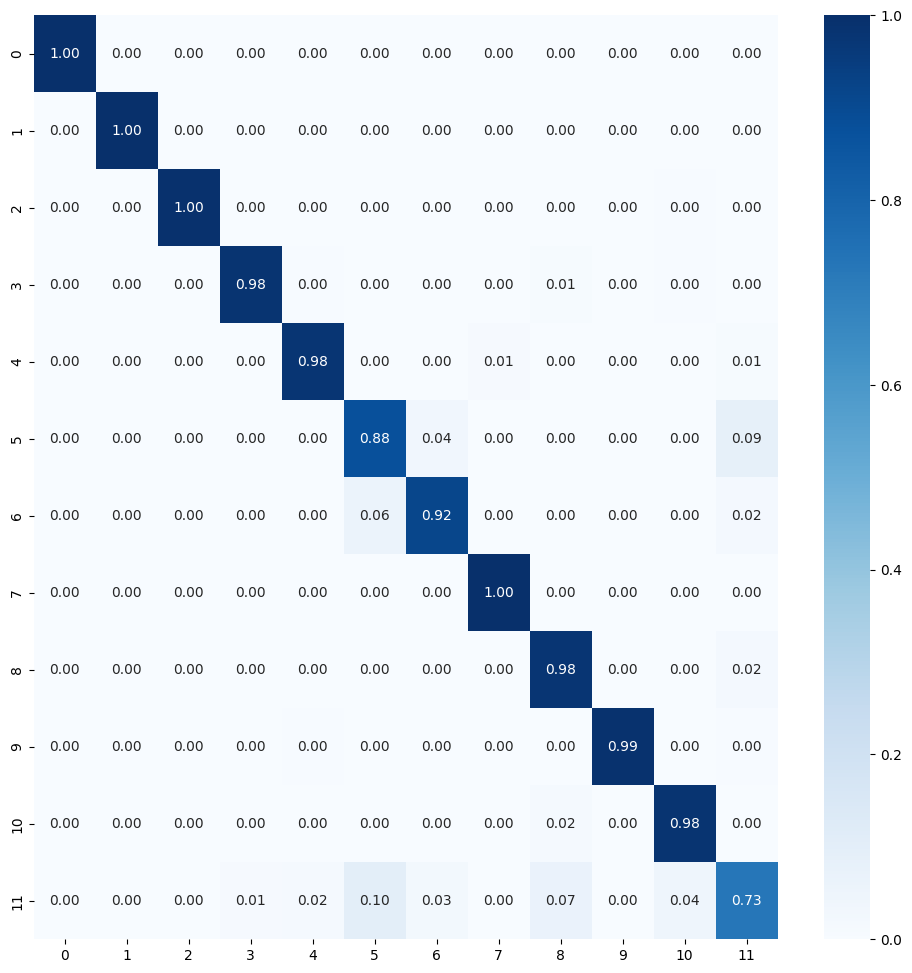


TRAINING AND EVALUATING FOLD 2/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
393/393 [==============================] - 32s 77ms/step - loss: 0.0555 - accuracy: 0.9951 - val_loss: 0.2770 - val_accuracy: 0.9490 - lr: 1.0000e-05
Epoch 2/50
393/393 [==============================] - 31s 79ms/step - loss: 0.0538 - accuracy: 0.9955 - val_loss: 0.2754 - val_accuracy: 0.9498 - lr: 1.0000e-05
Epoch 3/50
393/393 [==============================] - 29s 73ms/step - loss: 0.0541 - accuracy: 0.9959 - val_loss: 0.2779 - val_accuracy: 0.9505 - lr: 1.0000e-05
Epoch 4/50
393/393 [==============================] - 28s 72ms/step - loss: 0.0532 - accuracy: 0.9960 - val_loss: 0.2716 - val_accuracy: 0.9498 - lr: 1.0000e-05
Epoch 5/50
393/393 [==============================] - 29s 73ms/step - loss: 0.0527 - accuracy: 0.9959 - val_loss: 0.2756 - val_accuracy: 0.9483 - lr: 1.0000e-05
Epoch 6/50
393/393 [==============================] -

History for fold 2 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150012_2.pkl
394/394 [==============================] - 22s 57ms/step - loss: 0.0483 - accuracy: 0.9974
Train Accuracy: 0.9973809719085693
Train Log Loss: 0.048277344554662704
85/85 [==============================] - 5s 58ms/step - loss: 0.2713 - accuracy: 0.9500
Validation Accuracy: 0.949999988079071
Validation Log Loss: 0.2712540626525879
85/85 [==============================] - 6s 66ms/step - loss: 0.2642 - accuracy: 0.9515
Test Accuracy: 0.9514814615249634
Test Log Loss: 0.26418831944465637
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   1   0   0   0   2   0   1   0]
 [  0   0   0   0 22

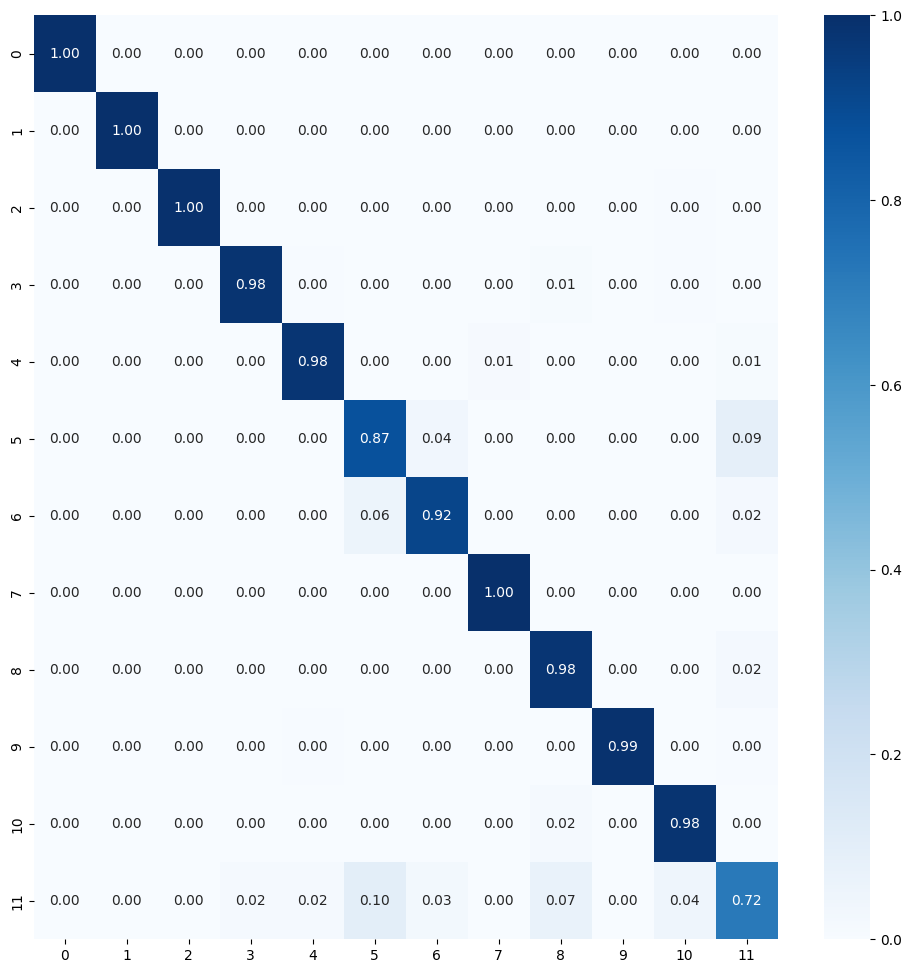


TRAINING AND EVALUATING FOLD 3/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
393/393 [==============================] - 31s 72ms/step - loss: 0.0548 - accuracy: 0.9958 - val_loss: 0.2742 - val_accuracy: 0.9490 - lr: 1.0000e-05
Epoch 2/50
393/393 [==============================] - 29s 74ms/step - loss: 0.0533 - accuracy: 0.9959 - val_loss: 0.2777 - val_accuracy: 0.9490 - lr: 1.0000e-05
Epoch 3/50
393/393 [==============================] - 29s 73ms/step - loss: 0.0535 - accuracy: 0.9957 - val_loss: 0.2779 - val_accuracy: 0.9505 - lr: 1.0000e-05
Epoch 4/50
393/393 [==============================] - 29s 73ms/step - loss: 0.0534 - accuracy: 0.9955 - val_loss: 0.2730 - val_accuracy: 0.9509 - lr: 1.0000e-05
Epoch 5/50
393/393 [==============================] - 30s 75ms/step - loss: 0.0542 - accuracy: 0.9958 - val_loss: 0.2753 - val_accuracy: 0.9494 - lr: 1.0000e-05
Epoch 6/50
393/393 [==============================] -

History for fold 3 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150012_3.pkl
394/394 [==============================] - 24s 61ms/step - loss: 0.0485 - accuracy: 0.9974
Train Accuracy: 0.9973809719085693
Train Log Loss: 0.04848982021212578
85/85 [==============================] - 5s 59ms/step - loss: 0.2737 - accuracy: 0.9500
Validation Accuracy: 0.949999988079071
Validation Log Loss: 0.27370819449424744
85/85 [==============================] - 6s 64ms/step - loss: 0.2653 - accuracy: 0.9515
Test Accuracy: 0.9514814615249634
Test Log Loss: 0.26534685492515564
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   1   1   0   0   1   0   1   0]
 [  0   0   0   0 22

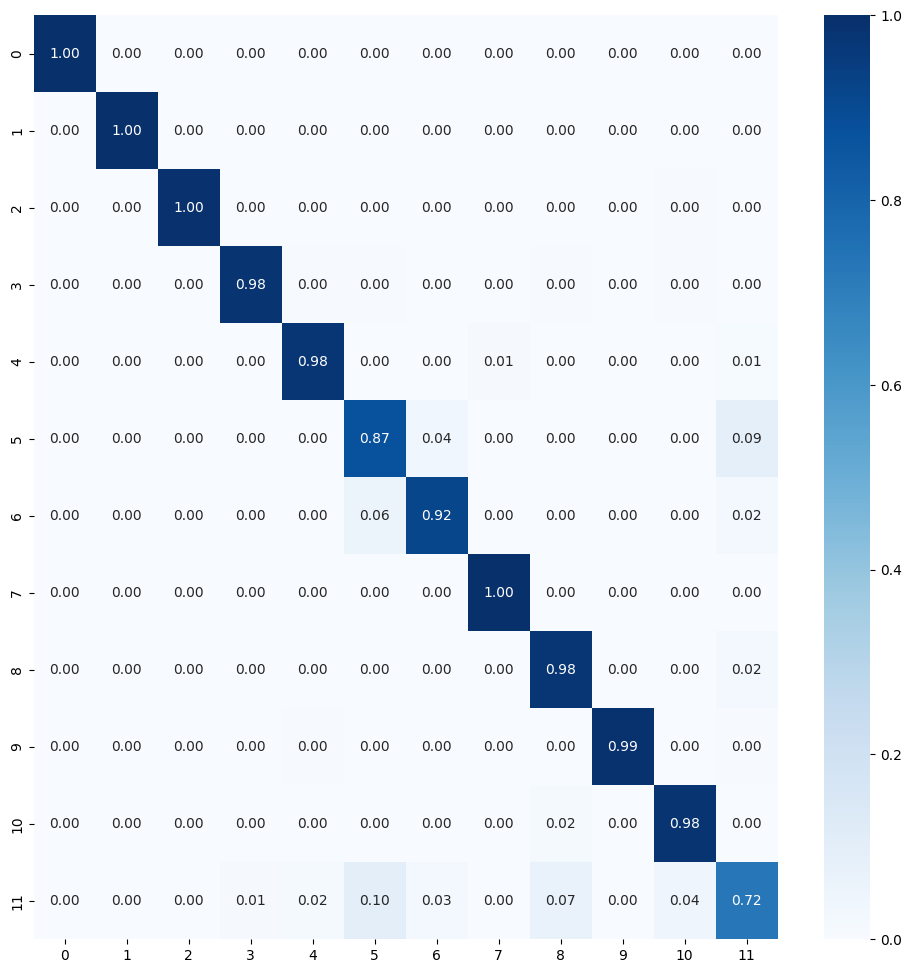


TRAINING AND EVALUATING FOLD 4/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
393/393 [==============================] - 32s 75ms/step - loss: 0.0545 - accuracy: 0.9955 - val_loss: 0.2801 - val_accuracy: 0.9490 - lr: 1.0000e-05
Epoch 2/50
393/393 [==============================] - 29s 74ms/step - loss: 0.0548 - accuracy: 0.9951 - val_loss: 0.2734 - val_accuracy: 0.9483 - lr: 1.0000e-05
Epoch 3/50
393/393 [==============================] - 28s 70ms/step - loss: 0.0544 - accuracy: 0.9957 - val_loss: 0.2699 - val_accuracy: 0.9490 - lr: 1.0000e-05
Epoch 4/50
393/393 [==============================] - 29s 74ms/step - loss: 0.0532 - accuracy: 0.9963 - val_loss: 0.2793 - val_accuracy: 0.9498 - lr: 1.0000e-05
Epoch 5/50
393/393 [==============================] - 29s 74ms/step - loss: 0.0526 - accuracy: 0.9959 - val_loss: 0.2762 - val_accuracy: 0.9479 - lr: 1.0000e-05
Epoch 6/50
393/393 [==============================] -

History for fold 4 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150012_4.pkl
394/394 [==============================] - 24s 60ms/step - loss: 0.0487 - accuracy: 0.9974
Train Accuracy: 0.9973809719085693
Train Log Loss: 0.04872637987136841
85/85 [==============================] - 5s 62ms/step - loss: 0.2743 - accuracy: 0.9504
Validation Accuracy: 0.9503703713417053
Validation Log Loss: 0.27433931827545166
85/85 [==============================] - 5s 61ms/step - loss: 0.2648 - accuracy: 0.9507
Test Accuracy: 0.9507407546043396
Test Log Loss: 0.26479798555374146
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   2   1   0   0   1   0   0   0]
 [  0   0   0   0 2

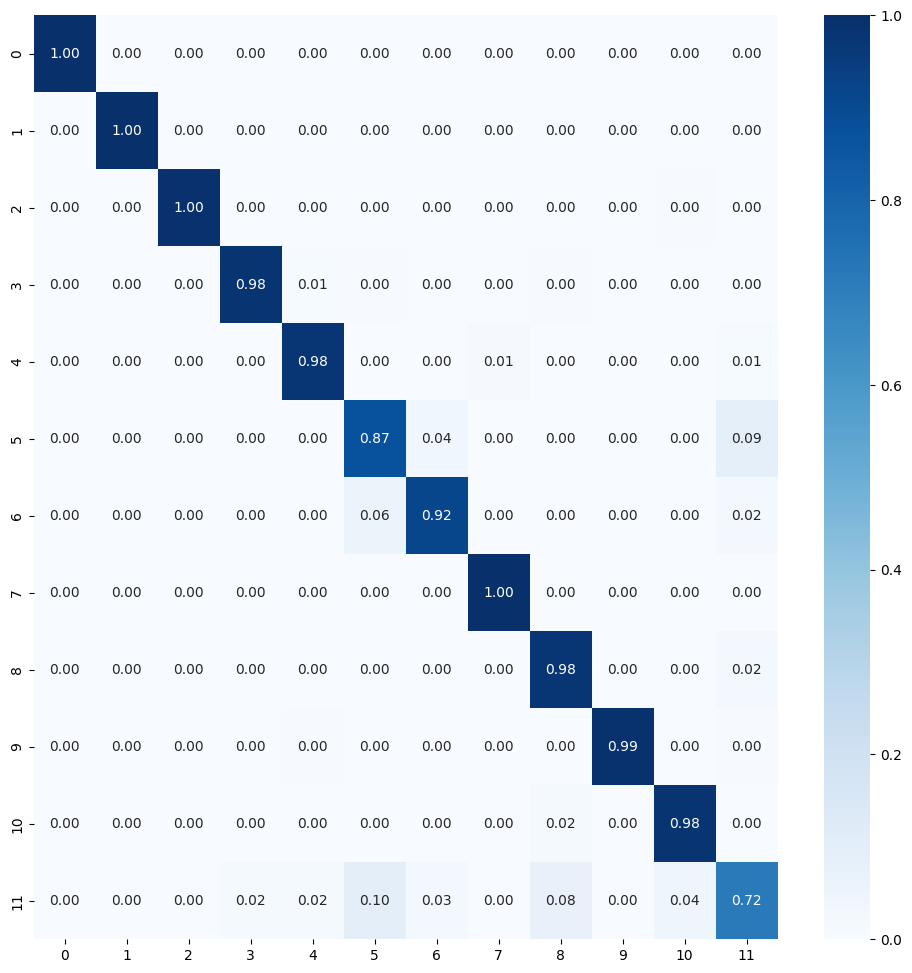


TRAINING AND EVALUATING FOLD 5/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
393/393 [==============================] - 32s 76ms/step - loss: 0.0545 - accuracy: 0.9956 - val_loss: 0.2811 - val_accuracy: 0.9498 - lr: 1.0000e-05
Epoch 2/50
393/393 [==============================] - 29s 74ms/step - loss: 0.0540 - accuracy: 0.9959 - val_loss: 0.2811 - val_accuracy: 0.9516 - lr: 1.0000e-05
Epoch 3/50
393/393 [==============================] - 28s 72ms/step - loss: 0.0536 - accuracy: 0.9956 - val_loss: 0.2775 - val_accuracy: 0.9516 - lr: 1.0000e-05
Epoch 4/50
393/393 [==============================] - 29s 74ms/step - loss: 0.0532 - accuracy: 0.9957 - val_loss: 0.2781 - val_accuracy: 0.9498 - lr: 1.0000e-05
Epoch 5/50
393/393 [==============================] - 29s 75ms/step - loss: 0.0532 - accuracy: 0.9956 - val_loss: 0.2756 - val_accuracy: 0.9509 - lr: 1.0000e-05
Epoch 6/50
393/393 [==============================] -

History for fold 5 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150012_5.pkl
394/394 [==============================] - 24s 60ms/step - loss: 0.0483 - accuracy: 0.9975
Train Accuracy: 0.9974603056907654
Train Log Loss: 0.04832376167178154
85/85 [==============================] - 5s 60ms/step - loss: 0.2722 - accuracy: 0.9507
Validation Accuracy: 0.9507407546043396
Validation Log Loss: 0.27219629287719727
85/85 [==============================] - 5s 61ms/step - loss: 0.2633 - accuracy: 0.9515
Test Accuracy: 0.9514814615249634
Test Log Loss: 0.26334843039512634
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   1   1   0   0   1   0   1   0]
 [  0   0   0   0 2

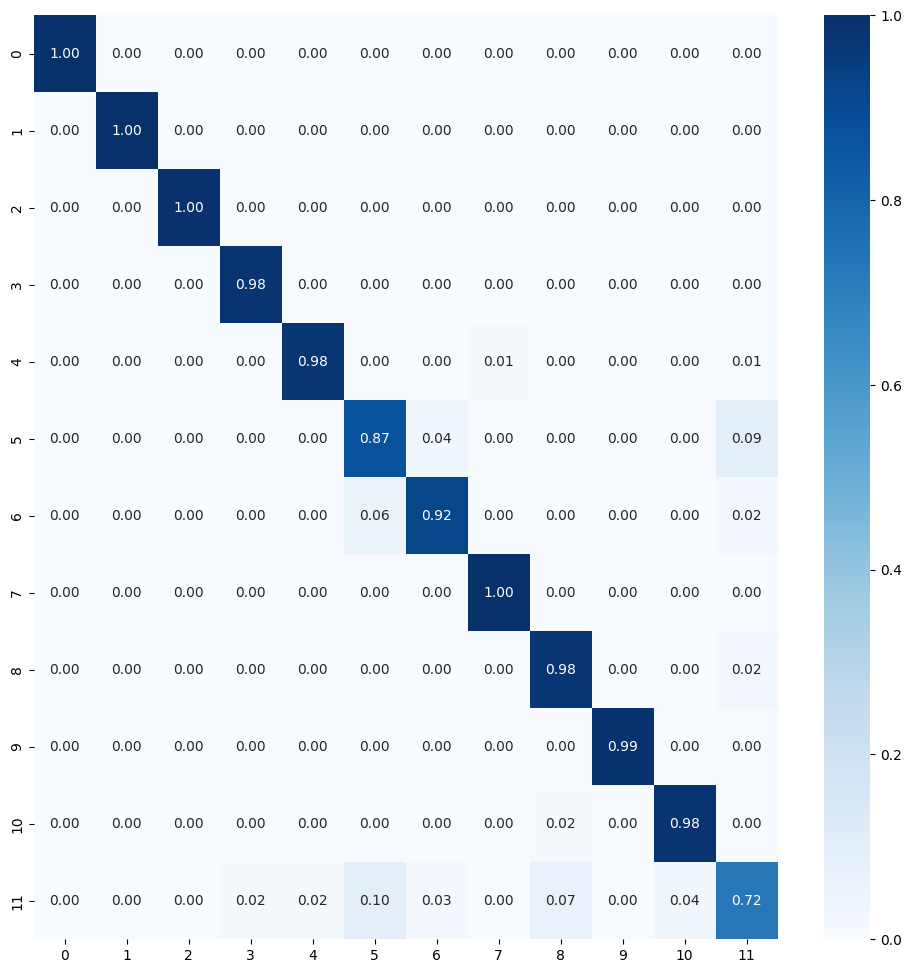


Best fold was 1 with val_accuracy: 0.9528
Average training accuracy in 5-fold: 0.997613000869751
Average validation precision in 5-fold: 0.9523065328598023

Test Metrics
test_acc_list: [0.9522222280502319, 0.9514814615249634, 0.9514814615249634, 0.9507407546043396, 0.9514814615249634]
Average Test Accuracy with 5-fold: 0.9514814734458923
test_loss_list: [0.26375529170036316, 0.26418831944465637, 0.26534685492515564, 0.26479798555374146, 0.26334843039512634]
Average Test Log Loss with 5-fold: 0.2642873764038086

Precision List: [0.9515827323382707, 0.9506761833541143, 0.9508035951378138, 0.9499596615565878, 0.9507788811531785]
Average Precision List with 5-fold: 0.9507602107079931
Recall List: [0.9522222222222223, 0.9514814814814816, 0.9514814814814816, 0.9507407407407409, 0.9514814814814816]
Average Recall List with 5-fold: 0.9514814814814816
F1 Score List: [0.951454897807004, 0.9506152528361317, 0.9506968448930176, 0.9498550697785221, 0.9506905251740719]
Average F1 Score List with 5-

In [39]:
%%time

num_classes = 12
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/13
name_save_model: MobileNet_tf_150013
Found 13650 images belonging to 13 classes.
Found 2925 images belonging to 13 classes.
Found 2925 images belonging to 13 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop
- berbew

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150013_best.h5
Loading pre-trained model...
Model loaded successfully.

Calculating layer importance (once for all folds)...

Calculando importancia con 13650 muestras (100% confianza, ±0% error)
Incluyendo 93 capas (base + personalizadas)


100%|██████████| 13650/13650 [29:19<00:00,  7.76it/s]



Resultados de importancia de capas (incluyendo personalizadas):
----------------------------------------------------------------------
Pos.  | Nombre de Capa                           | Importancia    
----------------------------------------------------------------------
1     | conv_pw_1                                | 0.0374167
2     | conv_dw_1                                | 0.0317258
3     | conv_pw_3                                | 0.0286020
4     | conv_dw_1_bn                             | 0.0250338
5     | conv_pw_2                                | 0.0179710
6     | conv_dw_2_bn                             | 0.0174885
7     | conv_pw_3_bn                             | 0.0146201
8     | conv1_bn                                 | 0.0144599
9     | conv_pw_1_bn                             | 0.0142756
10    | conv_dw_3_bn                             | 0.0142040
11    | conv_dw_4_bn                             | 0.0130742
12    | conv_pw_4                                | 0.01

History for fold 1 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150013_1.pkl
427/427 [==============================] - 26s 60ms/step - loss: 0.0416 - accuracy: 0.9976
Train Accuracy: 0.9975824356079102
Train Log Loss: 0.041636183857917786
92/92 [==============================] - 6s 61ms/step - loss: 0.2575 - accuracy: 0.9542
Validation Accuracy: 0.9541880488395691
Validation Log Loss: 0.2574790120124817
92/92 [==============================] - 6s 59ms/step - loss: 0.2422 - accuracy: 0.9576
Test Accuracy: 0.957606852054596
Test Log Loss: 0.24215830862522125
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0 222   1   0   0   0   0   1   0

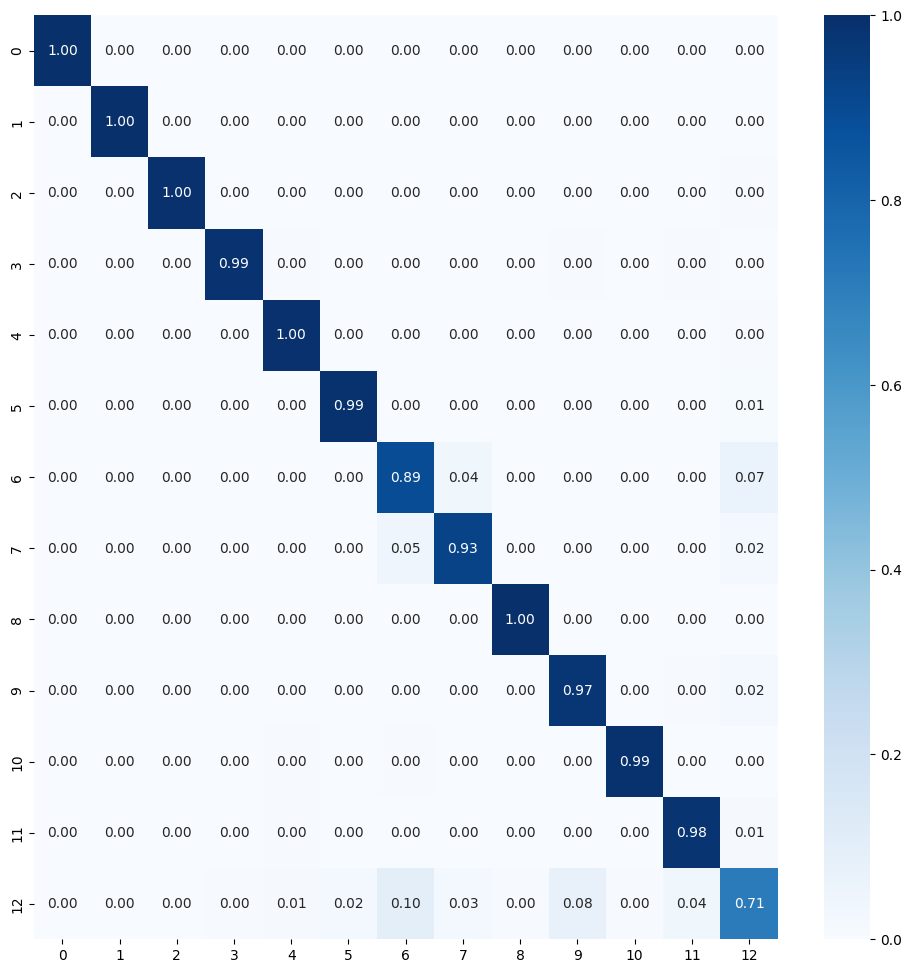


TRAINING AND EVALUATING FOLD 2/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
426/426 [==============================] - 33s 72ms/step - loss: 0.0475 - accuracy: 0.9958 - val_loss: 0.2540 - val_accuracy: 0.9547 - lr: 1.0000e-05
Epoch 2/50
426/426 [==============================] - 30s 71ms/step - loss: 0.0469 - accuracy: 0.9956 - val_loss: 0.2613 - val_accuracy: 0.9536 - lr: 1.0000e-05
Epoch 3/50
426/426 [==============================] - 32s 74ms/step - loss: 0.0476 - accuracy: 0.9960 - val_loss: 0.2562 - val_accuracy: 0.9560 - lr: 1.0000e-05
Epoch 4/50
426/426 [==============================] - 31s 73ms/step - loss: 0.0468 - accuracy: 0.9963 - val_loss: 0.2559 - val_accuracy: 0.9530 - lr: 1.0000e-05
Epoch 5/50
426/426 [==============================] - 31s 73ms/step - loss: 0.0463 - accuracy: 0.9965 - val_loss: 0.2567 - val_accuracy: 0.9536 - lr: 1.0000e-05
Epoch 6/50
426/426 [==============================] -

History for fold 2 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150013_2.pkl
427/427 [==============================] - 24s 56ms/step - loss: 0.0413 - accuracy: 0.9976
Train Accuracy: 0.9975824356079102
Train Log Loss: 0.04131516069173813
92/92 [==============================] - 6s 59ms/step - loss: 0.2561 - accuracy: 0.9535
Validation Accuracy: 0.9535042643547058
Validation Log Loss: 0.25610241293907166
92/92 [==============================] - 6s 60ms/step - loss: 0.2431 - accuracy: 0.9573
Test Accuracy: 0.9572649598121643
Test Log Loss: 0.24310792982578278
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0 222   1   0   0   0   0   1   

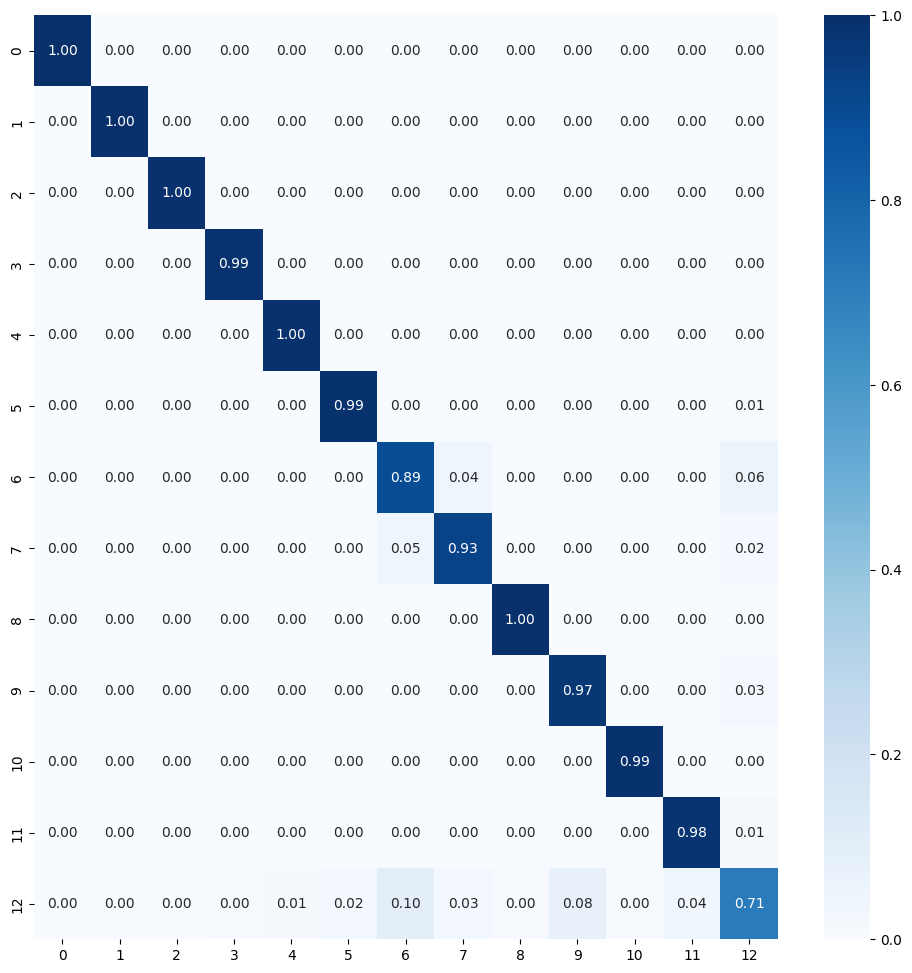


TRAINING AND EVALUATING FOLD 3/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
426/426 [==============================] - 35s 77ms/step - loss: 0.0482 - accuracy: 0.9960 - val_loss: 0.2583 - val_accuracy: 0.9530 - lr: 1.0000e-05
Epoch 2/50
426/426 [==============================] - 30s 71ms/step - loss: 0.0469 - accuracy: 0.9961 - val_loss: 0.2530 - val_accuracy: 0.9530 - lr: 1.0000e-05
Epoch 3/50
426/426 [==============================] - 31s 72ms/step - loss: 0.0463 - accuracy: 0.9965 - val_loss: 0.2544 - val_accuracy: 0.9533 - lr: 1.0000e-05
Epoch 4/50
426/426 [==============================] - 31s 74ms/step - loss: 0.0466 - accuracy: 0.9961 - val_loss: 0.2551 - val_accuracy: 0.9543 - lr: 1.0000e-05
Epoch 5/50
426/426 [==============================] - 32s 74ms/step - loss: 0.0476 - accuracy: 0.9966 - val_loss: 0.2490 - val_accuracy: 0.9543 - lr: 1.0000e-05
Epoch 6/50
426/426 [==============================] -

History for fold 3 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150013_3.pkl
427/427 [==============================] - 27s 62ms/step - loss: 0.0416 - accuracy: 0.9975
Train Accuracy: 0.9975091814994812
Train Log Loss: 0.041601479053497314
92/92 [==============================] - 6s 63ms/step - loss: 0.2571 - accuracy: 0.9542
Validation Accuracy: 0.9541880488395691
Validation Log Loss: 0.2571183443069458
92/92 [==============================] - 6s 60ms/step - loss: 0.2432 - accuracy: 0.9576
Test Accuracy: 0.957606852054596
Test Log Loss: 0.2431640475988388
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0 222   1   0   0   0   0   1   0 

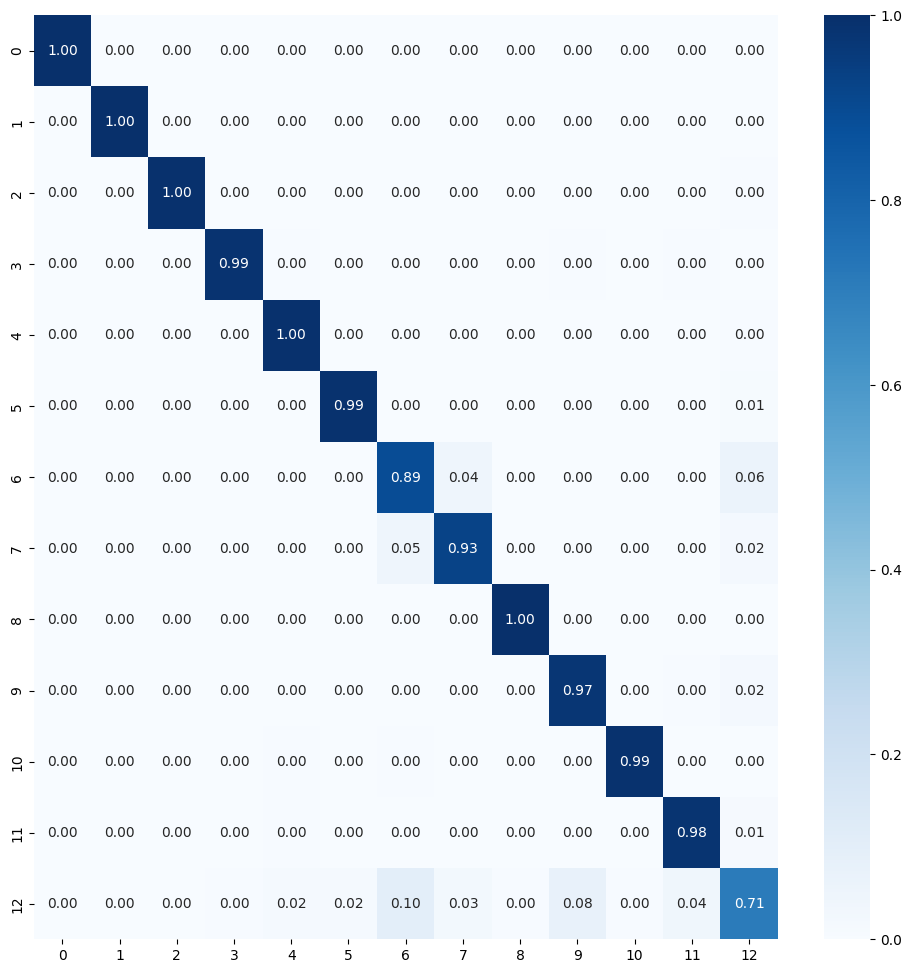


TRAINING AND EVALUATING FOLD 4/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
426/426 [==============================] - 33s 74ms/step - loss: 0.0479 - accuracy: 0.9959 - val_loss: 0.2585 - val_accuracy: 0.9540 - lr: 1.0000e-05
Epoch 2/50
426/426 [==============================] - 30s 70ms/step - loss: 0.0477 - accuracy: 0.9961 - val_loss: 0.2570 - val_accuracy: 0.9550 - lr: 1.0000e-05
Epoch 3/50
426/426 [==============================] - 32s 74ms/step - loss: 0.0472 - accuracy: 0.9962 - val_loss: 0.2578 - val_accuracy: 0.9530 - lr: 1.0000e-05
Epoch 4/50
426/426 [==============================] - 31s 73ms/step - loss: 0.0457 - accuracy: 0.9963 - val_loss: 0.2538 - val_accuracy: 0.9530 - lr: 1.0000e-05
Epoch 5/50
426/426 [==============================] - 32s 74ms/step - loss: 0.0467 - accuracy: 0.9958 - val_loss: 0.2560 - val_accuracy: 0.9543 - lr: 1.0000e-05
Epoch 6/50
426/426 [==============================] -

History for fold 4 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150013_4.pkl
427/427 [==============================] - 25s 59ms/step - loss: 0.0415 - accuracy: 0.9976
Train Accuracy: 0.9975824356079102
Train Log Loss: 0.04149274528026581
92/92 [==============================] - 6s 61ms/step - loss: 0.2568 - accuracy: 0.9538
Validation Accuracy: 0.9538461565971375
Validation Log Loss: 0.25680139660835266
92/92 [==============================] - 5s 55ms/step - loss: 0.2415 - accuracy: 0.9559
Test Accuracy: 0.9558974504470825
Test Log Loss: 0.2415226250886917
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0 222   1   0   0   0   0   1   0

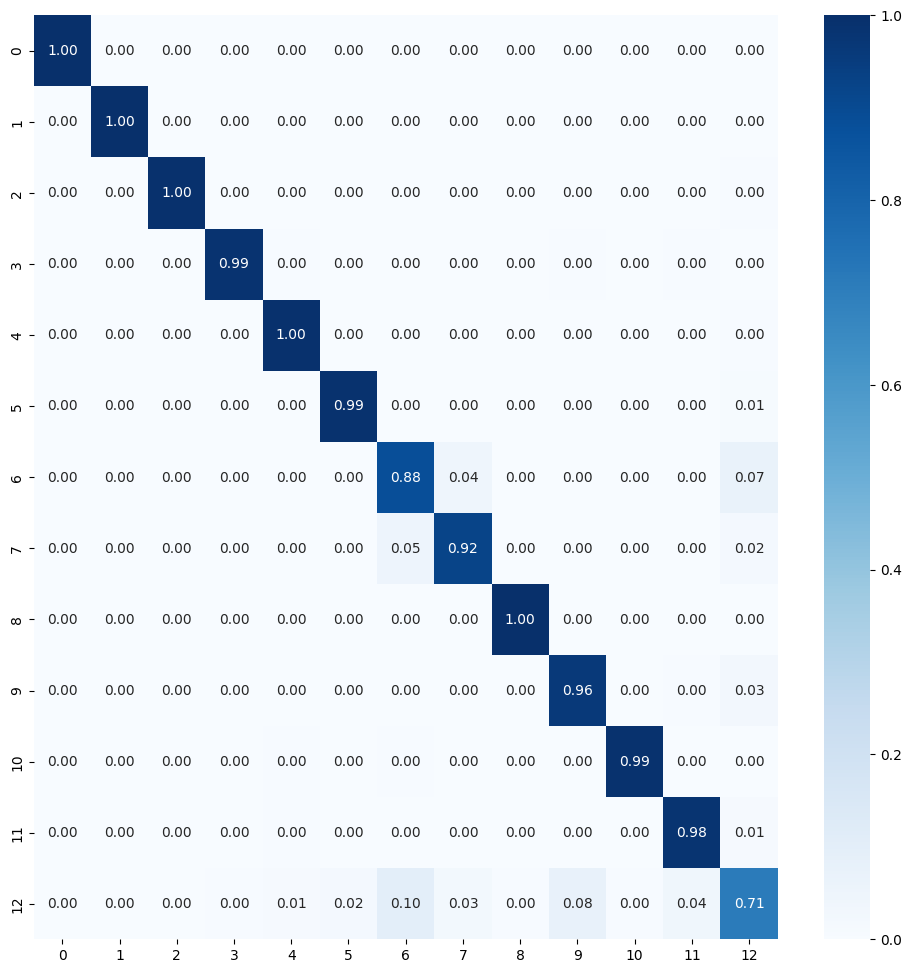


TRAINING AND EVALUATING FOLD 5/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
426/426 [==============================] - 35s 78ms/step - loss: 0.0482 - accuracy: 0.9956 - val_loss: 0.2577 - val_accuracy: 0.9523 - lr: 1.0000e-05
Epoch 2/50
426/426 [==============================] - 31s 72ms/step - loss: 0.0479 - accuracy: 0.9962 - val_loss: 0.2528 - val_accuracy: 0.9550 - lr: 1.0000e-05
Epoch 3/50
426/426 [==============================] - 31s 73ms/step - loss: 0.0460 - accuracy: 0.9968 - val_loss: 0.2552 - val_accuracy: 0.9550 - lr: 1.0000e-05
Epoch 4/50
426/426 [==============================] - 32s 75ms/step - loss: 0.0461 - accuracy: 0.9969 - val_loss: 0.2553 - val_accuracy: 0.9557 - lr: 1.0000e-05
Epoch 5/50
426/426 [==============================] - 31s 73ms/step - loss: 0.0462 - accuracy: 0.9966 - val_loss: 0.2617 - val_accuracy: 0.9540 - lr: 1.0000e-05
Epoch 6/50
426/426 [==============================] -

History for fold 5 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150013_5.pkl
427/427 [==============================] - 27s 62ms/step - loss: 0.0414 - accuracy: 0.9975
Train Accuracy: 0.9975091814994812
Train Log Loss: 0.041407469660043716
92/92 [==============================] - 6s 63ms/step - loss: 0.2562 - accuracy: 0.9542
Validation Accuracy: 0.9541880488395691
Validation Log Loss: 0.2562078833580017
92/92 [==============================] - 6s 61ms/step - loss: 0.2414 - accuracy: 0.9569
Test Accuracy: 0.9569230675697327
Test Log Loss: 0.2413916438817978
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0 222   1   0   0   0   0   1   0

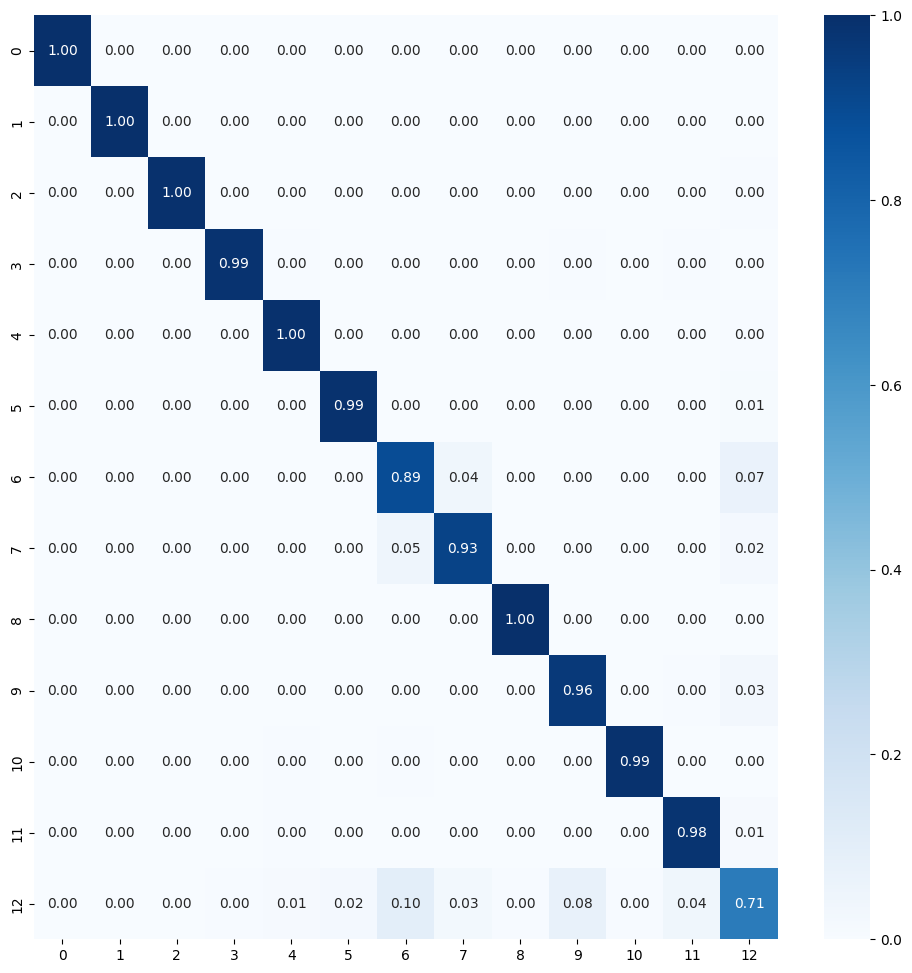


Best fold was 2 with val_accuracy: 0.9560
Average training accuracy in 5-fold: 0.9977235794067383
Average validation precision in 5-fold: 0.955494511127472

Test Metrics
test_acc_list: [0.957606852054596, 0.9572649598121643, 0.957606852054596, 0.9558974504470825, 0.9569230675697327]
Average Test Accuracy with 5-fold: 0.9570598363876343
test_loss_list: [0.24215830862522125, 0.24310792982578278, 0.2431640475988388, 0.2415226250886917, 0.2413916438817978]
Average Test Log Loss with 5-fold: 0.24226891100406647

Precision List: [0.9566872989132259, 0.9563435570094646, 0.9567110513558442, 0.954931685479698, 0.9559767263836613]
Average Precision List with 5-fold: 0.9561300638283787
Recall List: [0.9576068376068375, 0.9572649572649573, 0.9576068376068375, 0.9558974358974359, 0.9569230769230769]
Average Recall List with 5-fold: 0.9570598290598289
F1 Score List: [0.9566611002287526, 0.9563264327034614, 0.9566453187929499, 0.9550210997400428, 0.9560275134632537]
Average F1 Score List with 5-fold

In [40]:
%%time

num_classes = 13
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/14
name_save_model: MobileNet_tf_150014
Found 14700 images belonging to 14 classes.
Found 3150 images belonging to 14 classes.
Found 3150 images belonging to 14 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop
- berbew
- small

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150014_best.h5
Loading pre-trained model...
Model loaded successfully.

Calculating layer importance (once for all folds)...

Calculando importancia con 14700 muestras (100% confianza, ±0% error)
Incluyendo 93 capas (base + personalizadas)


100%|██████████| 14700/14700 [31:43<00:00,  7.72it/s]



Resultados de importancia de capas (incluyendo personalizadas):
----------------------------------------------------------------------
Pos.  | Nombre de Capa                           | Importancia    
----------------------------------------------------------------------
1     | conv_pw_1                                | 0.3384278
2     | conv_dw_1                                | 0.2658257
3     | conv_pw_3                                | 0.2067931
4     | conv_dw_1_bn                             | 0.1919769
5     | conv_dw_2_bn                             | 0.1703174
6     | conv_pw_2                                | 0.1510016
7     | conv_dw_3_bn                             | 0.1175689
8     | conv_pw_1_bn                             | 0.1091792
9     | conv_pw_3_bn                             | 0.0972512
10    | conv1_bn                                 | 0.0930273
11    | conv_dw_3                                | 0.0909520
12    | conv_dw_4_bn                             | 0.08

History for fold 1 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150014_1.pkl
460/460 [==============================] - 28s 61ms/step - loss: 0.1041 - accuracy: 0.9696
Train Accuracy: 0.9695918560028076
Train Log Loss: 0.1041351929306984
99/99 [==============================] - 6s 60ms/step - loss: 0.3198 - accuracy: 0.9238
Validation Accuracy: 0.9238095283508301
Validation Log Loss: 0.3197784125804901
99/99 [==============================] - 6s 60ms/step - loss: 0.3070 - accuracy: 0.9276
Test Accuracy: 0.9276190400123596
Test Log Loss: 0.30698448419570923
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 222   2

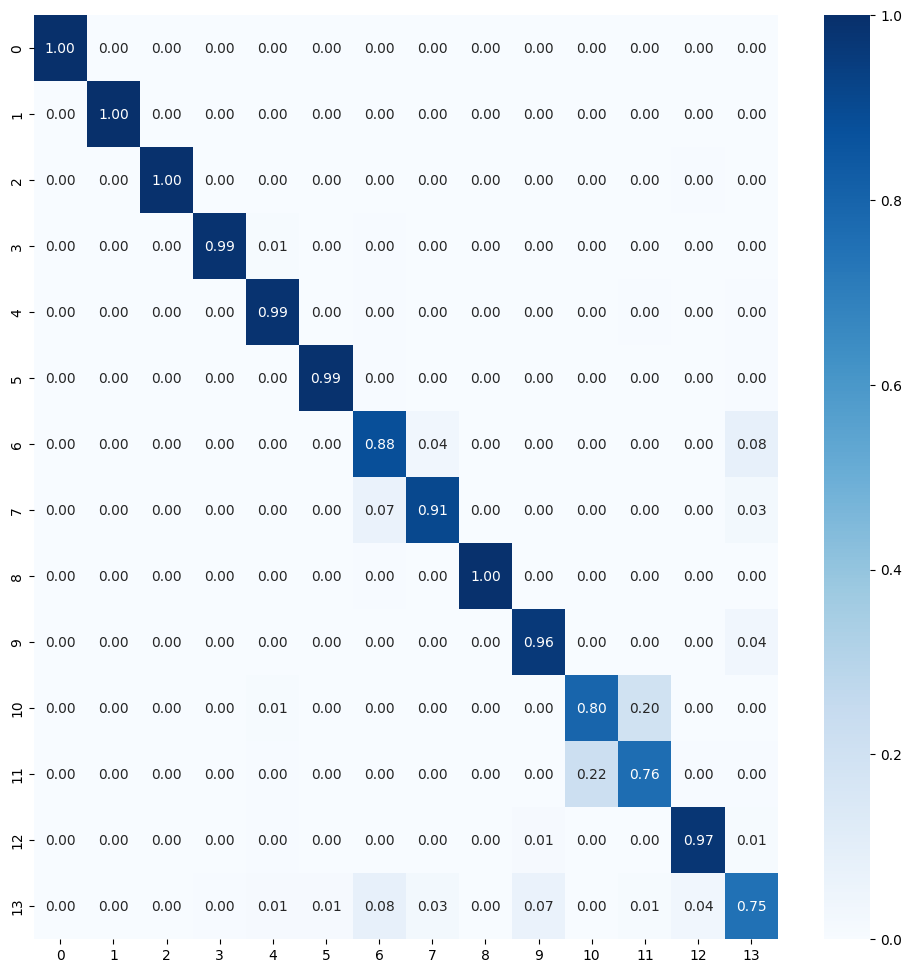


TRAINING AND EVALUATING FOLD 2/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
459/459 [==============================] - 36s 73ms/step - loss: 0.1328 - accuracy: 0.9573 - val_loss: 0.3172 - val_accuracy: 0.9209 - lr: 1.0000e-05
Epoch 2/50
459/459 [==============================] - 33s 73ms/step - loss: 0.1238 - accuracy: 0.9597 - val_loss: 0.3544 - val_accuracy: 0.9008 - lr: 1.0000e-05
Epoch 3/50
459/459 [==============================] - 34s 74ms/step - loss: 0.1311 - accuracy: 0.9521 - val_loss: 0.3188 - val_accuracy: 0.9203 - lr: 1.0000e-05
Epoch 4/50
459/459 [==============================] - 34s 73ms/step - loss: 0.1195 - accuracy: 0.9595 - val_loss: 0.3198 - val_accuracy: 0.9126 - lr: 1.0000e-05
Epoch 5/50
459/459 [==============================] - 30s 66ms/step - loss: 0.1252 - accuracy: 0.9564 - val_loss: 0.3160 - val_accuracy: 0.9238 - lr: 1.0000e-05
Epoch 6/50
459/459 [==============================] -

History for fold 2 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150014_2.pkl
460/460 [==============================] - 27s 60ms/step - loss: 0.1029 - accuracy: 0.9703
Train Accuracy: 0.9703401327133179
Train Log Loss: 0.10292336344718933
99/99 [==============================] - 6s 62ms/step - loss: 0.3136 - accuracy: 0.9206
Validation Accuracy: 0.920634925365448
Validation Log Loss: 0.3136369287967682
99/99 [==============================] - 6s 61ms/step - loss: 0.3073 - accuracy: 0.9257
Test Accuracy: 0.9257143139839172
Test Log Loss: 0.30733832716941833
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   2

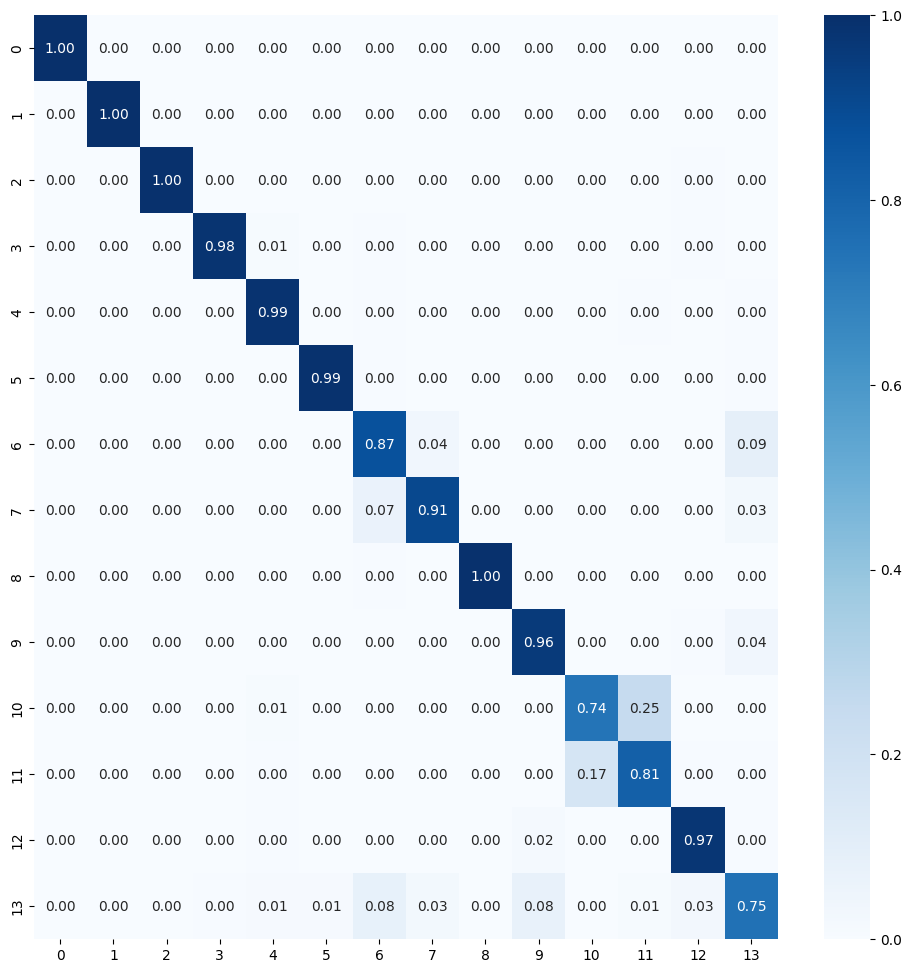


TRAINING AND EVALUATING FOLD 3/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
459/459 [==============================] - 37s 76ms/step - loss: 0.1317 - accuracy: 0.9540 - val_loss: 0.3206 - val_accuracy: 0.9110 - lr: 1.0000e-05
Epoch 2/50
459/459 [==============================] - 34s 74ms/step - loss: 0.1285 - accuracy: 0.9545 - val_loss: 0.3242 - val_accuracy: 0.9126 - lr: 1.0000e-05
Epoch 3/50
459/459 [==============================] - 33s 73ms/step - loss: 0.1287 - accuracy: 0.9595 - val_loss: 0.3063 - val_accuracy: 0.9161 - lr: 1.0000e-05
Epoch 4/50
459/459 [==============================] - 33s 72ms/step - loss: 0.1250 - accuracy: 0.9582 - val_loss: 0.3231 - val_accuracy: 0.9216 - lr: 1.0000e-05
Epoch 5/50
459/459 [==============================] - 34s 74ms/step - loss: 0.1222 - accuracy: 0.9558 - val_loss: 0.3257 - val_accuracy: 0.9139 - lr: 1.0000e-05
Epoch 6/50
459/459 [==============================] -

History for fold 3 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150014_3.pkl
460/460 [==============================] - 28s 61ms/step - loss: 0.1038 - accuracy: 0.9710
Train Accuracy: 0.9710204005241394
Train Log Loss: 0.1038062572479248
99/99 [==============================] - 6s 61ms/step - loss: 0.3166 - accuracy: 0.9222
Validation Accuracy: 0.9222221970558167
Validation Log Loss: 0.31657472252845764
99/99 [==============================] - 6s 60ms/step - loss: 0.3084 - accuracy: 0.9273
Test Accuracy: 0.9273015856742859
Test Log Loss: 0.30837497115135193
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 222   

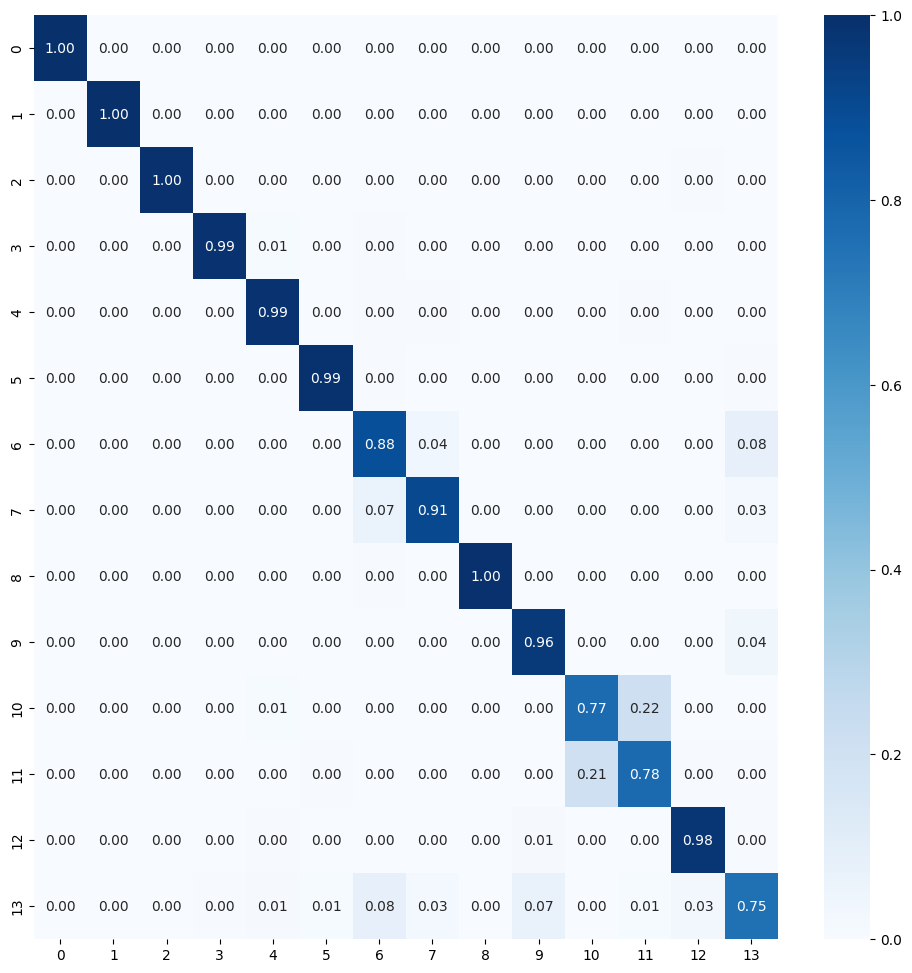


TRAINING AND EVALUATING FOLD 4/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
459/459 [==============================] - 37s 76ms/step - loss: 0.1386 - accuracy: 0.9511 - val_loss: 0.3289 - val_accuracy: 0.9126 - lr: 1.0000e-05
Epoch 2/50
459/459 [==============================] - 33s 72ms/step - loss: 0.1231 - accuracy: 0.9562 - val_loss: 0.3222 - val_accuracy: 0.9149 - lr: 1.0000e-05
Epoch 3/50
459/459 [==============================] - 34s 73ms/step - loss: 0.1250 - accuracy: 0.9551 - val_loss: 0.3284 - val_accuracy: 0.9149 - lr: 1.0000e-05
Epoch 4/50
459/459 [==============================] - 34s 75ms/step - loss: 0.1190 - accuracy: 0.9604 - val_loss: 0.3239 - val_accuracy: 0.9107 - lr: 1.0000e-05
Epoch 5/50
459/459 [==============================] - 33s 73ms/step - loss: 0.1210 - accuracy: 0.9582 - val_loss: 0.3179 - val_accuracy: 0.9232 - lr: 1.0000e-05
Epoch 6/50
459/459 [==============================] -

History for fold 4 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150014_4.pkl
460/460 [==============================] - 28s 60ms/step - loss: 0.1048 - accuracy: 0.9704
Train Accuracy: 0.9704081416130066
Train Log Loss: 0.1047598347067833
99/99 [==============================] - 6s 60ms/step - loss: 0.3156 - accuracy: 0.9216
Validation Accuracy: 0.9215872883796692
Validation Log Loss: 0.3156050145626068
99/99 [==============================] - 6s 60ms/step - loss: 0.3108 - accuracy: 0.9263
Test Accuracy: 0.9263492226600647
Test Log Loss: 0.31076765060424805
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 222   1

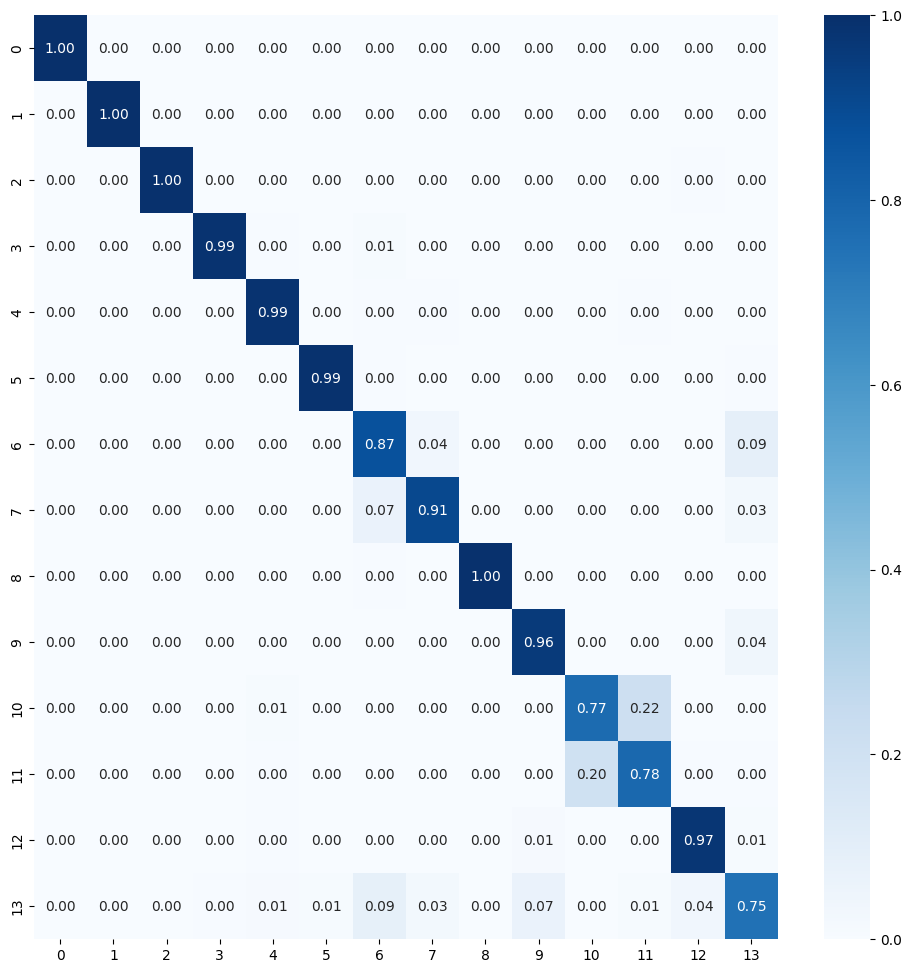


TRAINING AND EVALUATING FOLD 5/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
459/459 [==============================] - 36s 73ms/step - loss: 0.1324 - accuracy: 0.9513 - val_loss: 0.3262 - val_accuracy: 0.9209 - lr: 1.0000e-05
Epoch 2/50
459/459 [==============================] - 34s 74ms/step - loss: 0.1215 - accuracy: 0.9594 - val_loss: 0.3229 - val_accuracy: 0.9129 - lr: 1.0000e-05
Epoch 3/50
459/459 [==============================] - 33s 73ms/step - loss: 0.1305 - accuracy: 0.9559 - val_loss: 0.3211 - val_accuracy: 0.9206 - lr: 1.0000e-05
Epoch 4/50
459/459 [==============================] - 33s 72ms/step - loss: 0.1328 - accuracy: 0.9504 - val_loss: 0.3190 - val_accuracy: 0.9206 - lr: 1.0000e-05
Epoch 5/50
459/459 [==============================] - 34s 73ms/step - loss: 0.1247 - accuracy: 0.9557 - val_loss: 0.3218 - val_accuracy: 0.9174 - lr: 1.0000e-05
Epoch 6/50
459/459 [==============================] -

History for fold 5 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150014_5.pkl
460/460 [==============================] - 28s 60ms/step - loss: 0.1038 - accuracy: 0.9703
Train Accuracy: 0.9703401327133179
Train Log Loss: 0.10383094102144241
99/99 [==============================] - 6s 62ms/step - loss: 0.3197 - accuracy: 0.9229
Validation Accuracy: 0.9228571653366089
Validation Log Loss: 0.31968867778778076
99/99 [==============================] - 6s 60ms/step - loss: 0.3071 - accuracy: 0.9283
Test Accuracy: 0.9282539486885071
Test Log Loss: 0.3070581257343292
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   

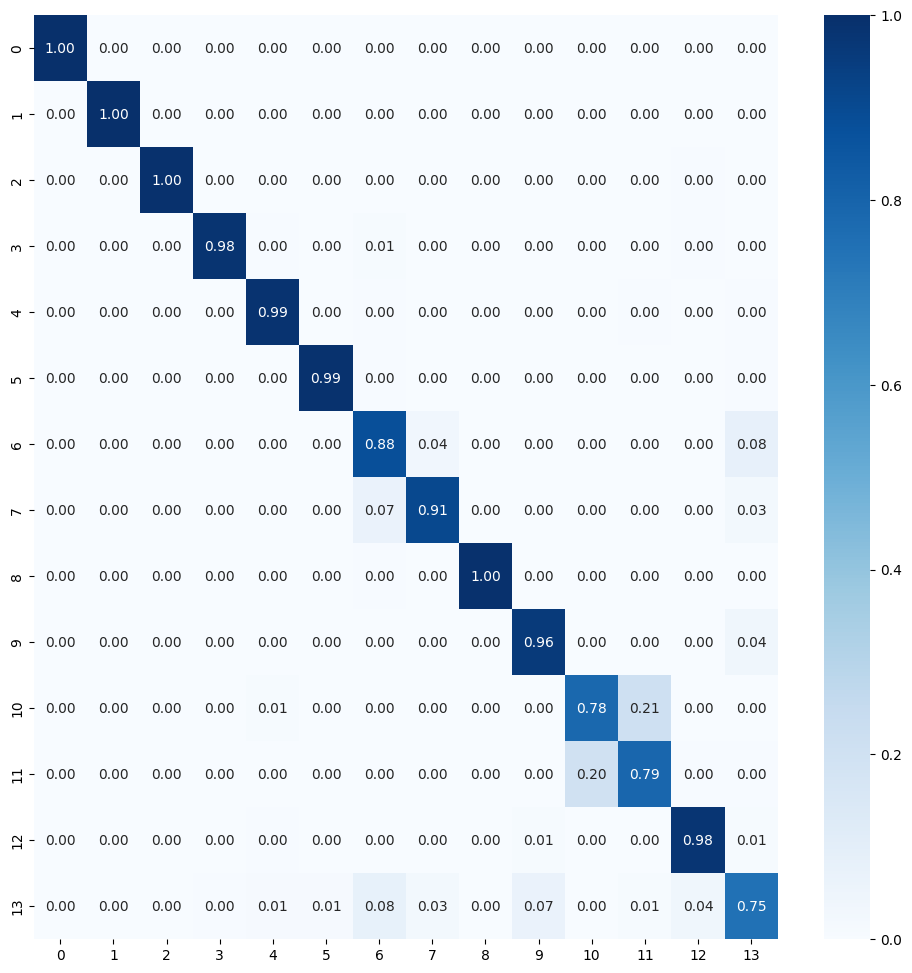


Best fold was 1 with val_accuracy: 0.9244
Average training accuracy in 5-fold: 0.9692391633987427
Average validation precision in 5-fold: 0.9239795804023743

Test Metrics
test_acc_list: [0.9276190400123596, 0.9257143139839172, 0.9273015856742859, 0.9263492226600647, 0.9282539486885071]
Average Test Accuracy with 5-fold: 0.9270476222038269
test_loss_list: [0.30698448419570923, 0.30733832716941833, 0.30837497115135193, 0.31076765060424805, 0.3070581257343292]
Average Test Log Loss with 5-fold: 0.30810471177101134

Precision List: [0.9271686298082399, 0.9255889065587581, 0.9268885751975928, 0.9259856818102177, 0.9278862055317623]
Average Precision List with 5-fold: 0.9267035997813142
Recall List: [0.9276190476190475, 0.9257142857142856, 0.9273015873015874, 0.9263492063492061, 0.9282539682539681]
Average Recall List with 5-fold: 0.927047619047619
F1 Score List: [0.9271678275565692, 0.9252478939999191, 0.9268855274788967, 0.9259840564038927, 0.9278687280427749]
Average F1 Score List with 5

In [41]:
%%time

num_classes = 14
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/15
name_save_model: MobileNet_tf_150015
Found 15750 images belonging to 15 classes.
Found 3375 images belonging to 15 classes.
Found 3375 images belonging to 15 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop
- berbew
- small
- upatre

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150015_best.h5
Loading pre-trained model...
Model loaded successfully.

Calculating layer importance (once for all folds)...

Calculando importancia con 15750 muestras (100% confianza, ±0% error)
Incluyendo 93 capas (base + personalizadas)


100%|██████████| 15750/15750 [34:20<00:00,  7.64it/s]



Resultados de importancia de capas (incluyendo personalizadas):
----------------------------------------------------------------------
Pos.  | Nombre de Capa                           | Importancia    
----------------------------------------------------------------------
1     | conv_pw_1                                | 0.1733577
2     | conv_dw_1                                | 0.1510274
3     | conv_pw_3                                | 0.1109991
4     | conv_dw_1_bn                             | 0.1011790
5     | conv_dw_2_bn                             | 0.0839061
6     | conv_pw_2                                | 0.0798875
7     | conv_dw_3_bn                             | 0.0624766
8     | conv_pw_1_bn                             | 0.0553409
9     | conv_pw_3_bn                             | 0.0531230
10    | conv_dw_3                                | 0.0494123
11    | conv1_bn                                 | 0.0481109
12    | conv_dw_4_bn                             | 0.04

History for fold 1 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150015_1.pkl
493/493 [==============================] - 30s 60ms/step - loss: 0.0995 - accuracy: 0.9702
Train Accuracy: 0.9702222347259521
Train Log Loss: 0.09950169175863266
106/106 [==============================] - 7s 62ms/step - loss: 0.3270 - accuracy: 0.9277
Validation Accuracy: 0.9277036786079407
Validation Log Loss: 0.32698366045951843
106/106 [==============================] - 7s 62ms/step - loss: 0.3132 - accuracy: 0.9301
Test Accuracy: 0.9300740957260132
Test Log Loss: 0.31324997544288635
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   

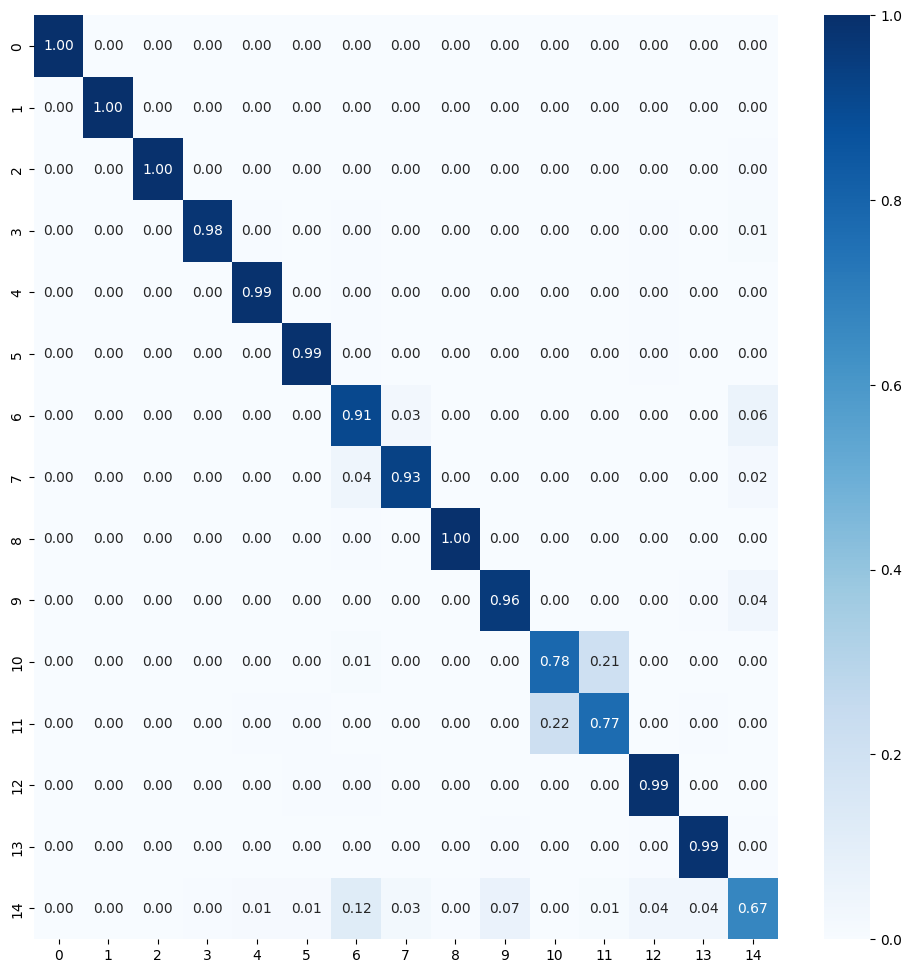


TRAINING AND EVALUATING FOLD 2/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
492/492 [==============================] - 38s 73ms/step - loss: 0.1221 - accuracy: 0.9595 - val_loss: 0.3390 - val_accuracy: 0.9187 - lr: 1.0000e-05
Epoch 2/50
492/492 [==============================] - 39s 78ms/step - loss: 0.1194 - accuracy: 0.9592 - val_loss: 0.3427 - val_accuracy: 0.9155 - lr: 1.0000e-05
Epoch 3/50
492/492 [==============================] - 34s 68ms/step - loss: 0.1152 - accuracy: 0.9564 - val_loss: 0.3351 - val_accuracy: 0.9256 - lr: 1.0000e-05
Epoch 4/50
492/492 [==============================] - 36s 73ms/step - loss: 0.1191 - accuracy: 0.9593 - val_loss: 0.3381 - val_accuracy: 0.9092 - lr: 1.0000e-05
Epoch 5/50
492/492 [==============================] - 36s 73ms/step - loss: 0.1257 - accuracy: 0.9563 - val_loss: 0.3336 - val_accuracy: 0.9217 - lr: 1.0000e-05
Epoch 6/50
492/492 [==============================] -

History for fold 2 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150015_2.pkl
493/493 [==============================] - 30s 60ms/step - loss: 0.1031 - accuracy: 0.9634
Train Accuracy: 0.9634285569190979
Train Log Loss: 0.10309182852506638
106/106 [==============================] - 7s 63ms/step - loss: 0.3289 - accuracy: 0.9197
Validation Accuracy: 0.9197037220001221
Validation Log Loss: 0.3288578987121582
106/106 [==============================] - 6s 59ms/step - loss: 0.3200 - accuracy: 0.9182
Test Accuracy: 0.9182222485542297
Test Log Loss: 0.32002976536750793
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   0

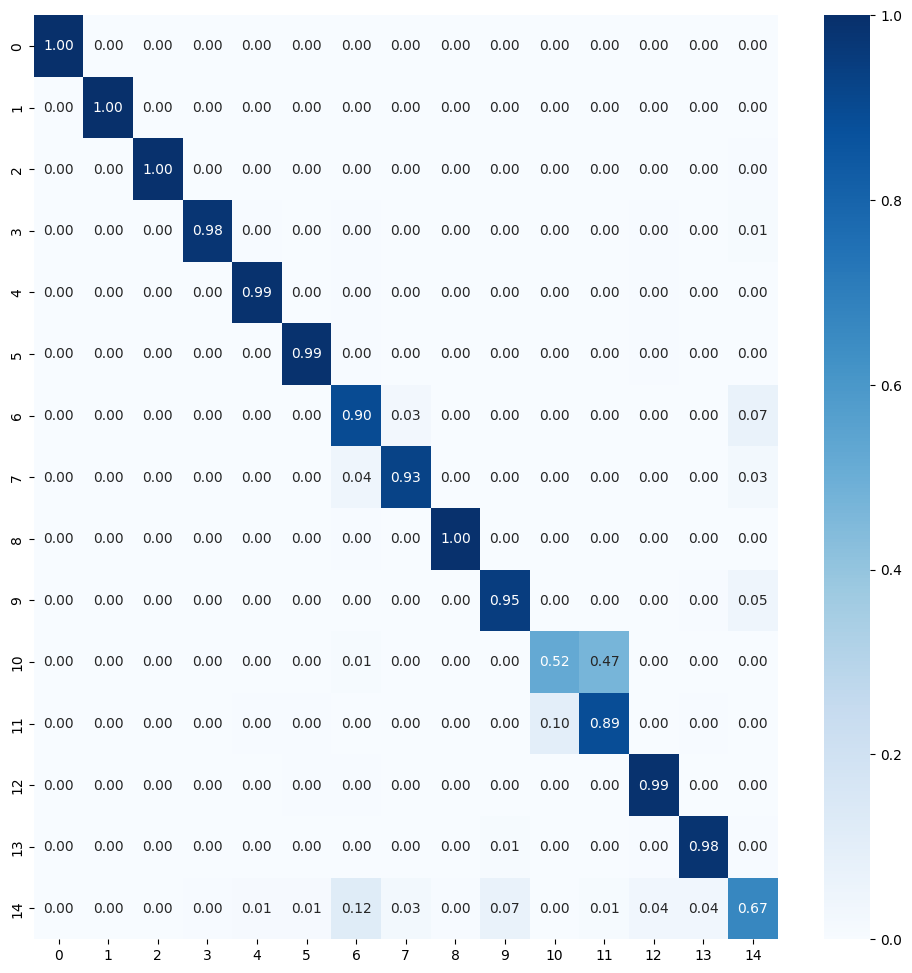


TRAINING AND EVALUATING FOLD 3/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
492/492 [==============================] - 38s 74ms/step - loss: 0.1201 - accuracy: 0.9546 - val_loss: 0.3381 - val_accuracy: 0.9199 - lr: 1.0000e-05
Epoch 2/50
492/492 [==============================] - 36s 73ms/step - loss: 0.1201 - accuracy: 0.9586 - val_loss: 0.3365 - val_accuracy: 0.9205 - lr: 1.0000e-05
Epoch 3/50
492/492 [==============================] - 36s 74ms/step - loss: 0.1197 - accuracy: 0.9563 - val_loss: 0.3351 - val_accuracy: 0.9176 - lr: 1.0000e-05
Epoch 4/50
492/492 [==============================] - 36s 72ms/step - loss: 0.1130 - accuracy: 0.9603 - val_loss: 0.3363 - val_accuracy: 0.9205 - lr: 1.0000e-05
Epoch 5/50
492/492 [==============================] - 36s 74ms/step - loss: 0.1175 - accuracy: 0.9606 - val_loss: 0.3439 - val_accuracy: 0.9193 - lr: 1.0000e-05
Epoch 6/50
492/492 [==============================] -

History for fold 3 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150015_3.pkl
493/493 [==============================] - 28s 58ms/step - loss: 0.1003 - accuracy: 0.9697
Train Accuracy: 0.9696508049964905
Train Log Loss: 0.10029688477516174
106/106 [==============================] - 5s 50ms/step - loss: 0.3262 - accuracy: 0.9265
Validation Accuracy: 0.9265184998512268
Validation Log Loss: 0.3261919915676117
106/106 [==============================] - 6s 58ms/step - loss: 0.3154 - accuracy: 0.9265
Test Accuracy: 0.9265184998512268
Test Log Loss: 0.31541678309440613
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   0

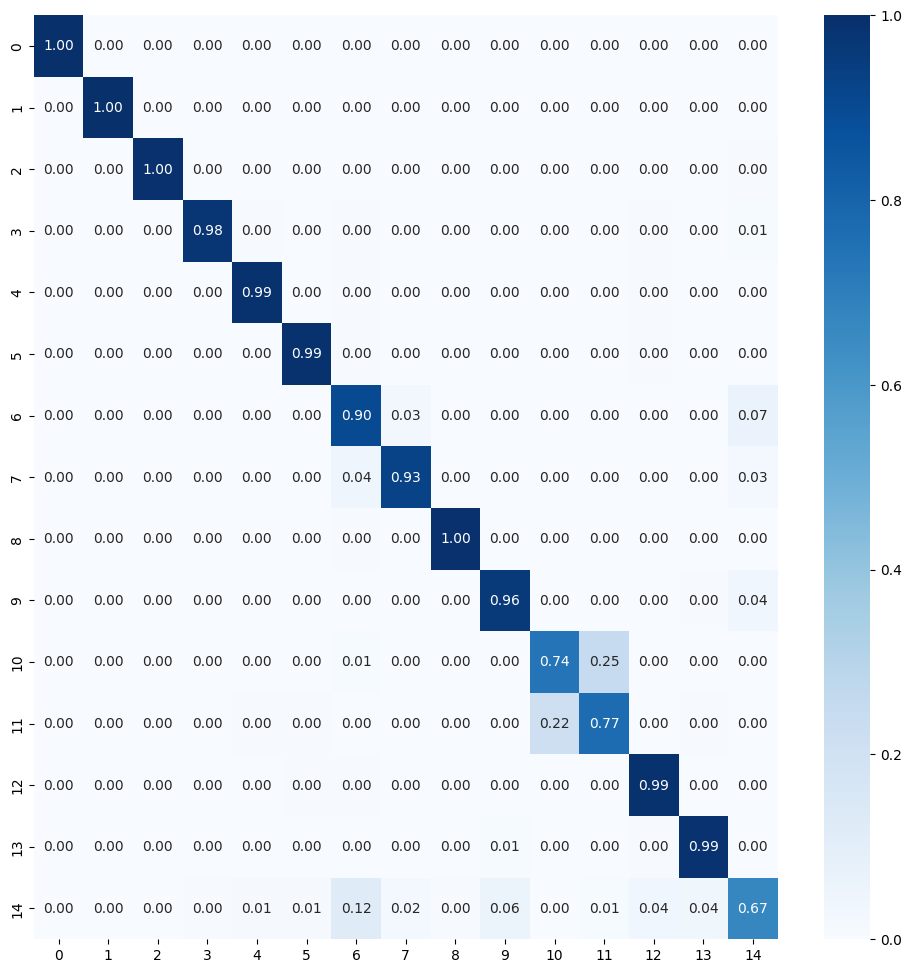


TRAINING AND EVALUATING FOLD 4/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
492/492 [==============================] - 38s 74ms/step - loss: 0.1260 - accuracy: 0.9560 - val_loss: 0.3314 - val_accuracy: 0.9235 - lr: 1.0000e-05
Epoch 2/50
492/492 [==============================] - 36s 73ms/step - loss: 0.1150 - accuracy: 0.9612 - val_loss: 0.3398 - val_accuracy: 0.9161 - lr: 1.0000e-05
Epoch 3/50
492/492 [==============================] - 36s 74ms/step - loss: 0.1171 - accuracy: 0.9607 - val_loss: 0.3377 - val_accuracy: 0.9235 - lr: 1.0000e-05
Epoch 4/50
492/492 [==============================] - 36s 73ms/step - loss: 0.1149 - accuracy: 0.9599 - val_loss: 0.3342 - val_accuracy: 0.9235 - lr: 1.0000e-05
Epoch 5/50
492/492 [==============================] - 37s 75ms/step - loss: 0.1156 - accuracy: 0.9629 - val_loss: 0.3406 - val_accuracy: 0.9217 - lr: 1.0000e-05
Epoch 6/50
492/492 [==============================] -

History for fold 4 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150015_4.pkl
493/493 [==============================] - 29s 58ms/step - loss: 0.0997 - accuracy: 0.9705
Train Accuracy: 0.9705396890640259
Train Log Loss: 0.09968220442533493
106/106 [==============================] - 6s 59ms/step - loss: 0.3262 - accuracy: 0.9259
Validation Accuracy: 0.9259259104728699
Validation Log Loss: 0.3261735439300537
106/106 [==============================] - 6s 60ms/step - loss: 0.3146 - accuracy: 0.9298
Test Accuracy: 0.9297778010368347
Test Log Loss: 0.314581960439682
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   0  

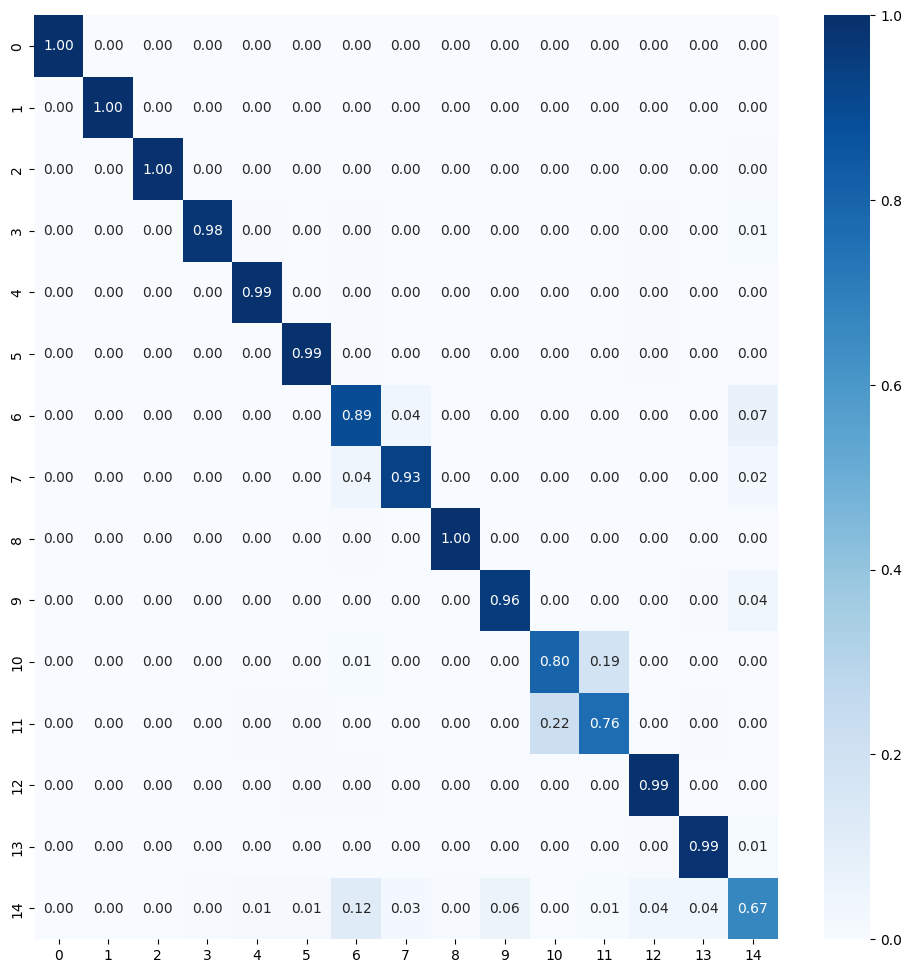


TRAINING AND EVALUATING FOLD 5/5...


Capas configuradas como entrenables:
- conv_dw_1
- conv_pw_1
- conv_pw_3
Total: 3/93 capas entrenables
Epoch 1/50
492/492 [==============================] - 38s 73ms/step - loss: 0.1270 - accuracy: 0.9544 - val_loss: 0.3427 - val_accuracy: 0.9107 - lr: 1.0000e-05
Epoch 2/50
492/492 [==============================] - 36s 72ms/step - loss: 0.1173 - accuracy: 0.9607 - val_loss: 0.3438 - val_accuracy: 0.9229 - lr: 1.0000e-05
Epoch 3/50
492/492 [==============================] - 36s 73ms/step - loss: 0.1152 - accuracy: 0.9586 - val_loss: 0.3349 - val_accuracy: 0.9223 - lr: 1.0000e-05
Epoch 4/50
492/492 [==============================] - 35s 71ms/step - loss: 0.1134 - accuracy: 0.9615 - val_loss: 0.3387 - val_accuracy: 0.9179 - lr: 1.0000e-05
Epoch 5/50
492/492 [==============================] - 37s 74ms/step - loss: 0.1151 - accuracy: 0.9589 - val_loss: 0.3306 - val_accuracy: 0.9202 - lr: 1.0000e-05
Epoch 6/50
492/492 [==============================] -

History for fold 5 saved as c9_base_MobNetTF_1500_LIBFT_MobileNet_tf_150015_5.pkl
493/493 [==============================] - 31s 63ms/step - loss: 0.1002 - accuracy: 0.9699
Train Accuracy: 0.9699047803878784
Train Log Loss: 0.10023067146539688
106/106 [==============================] - 6s 60ms/step - loss: 0.3271 - accuracy: 0.9256
Validation Accuracy: 0.9256296157836914
Validation Log Loss: 0.32712268829345703
106/106 [==============================] - 6s 60ms/step - loss: 0.3163 - accuracy: 0.9280
Test Accuracy: 0.9279999732971191
Test Log Loss: 0.3162517249584198
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   0

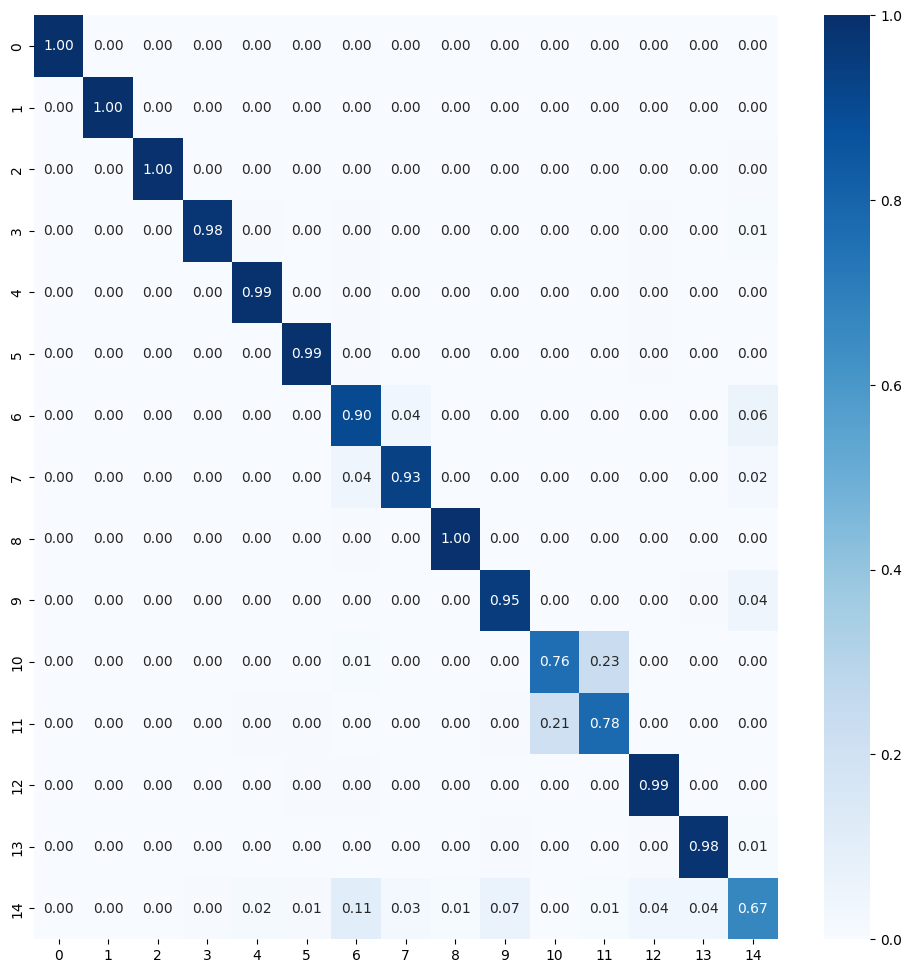


Best fold was 1 with val_accuracy: 0.9283
Average training accuracy in 5-fold: 0.9698307752609253
Average validation precision in 5-fold: 0.9276190638542176

Test Metrics
test_acc_list: [0.9300740957260132, 0.9182222485542297, 0.9265184998512268, 0.9297778010368347, 0.9279999732971191]
Average Test Accuracy with 5-fold: 0.9265185236930847
test_loss_list: [0.31324997544288635, 0.32002976536750793, 0.31541678309440613, 0.314581960439682, 0.3162517249584198]
Average Test Log Loss with 5-fold: 0.31590604186058047

Precision List: [0.9292996490972005, 0.9220460684578641, 0.9258066938073364, 0.9288488708117859, 0.9270393982509126]
Average Precision List with 5-fold: 0.9266081360850199
Recall List: [0.930074074074074, 0.9182222222222223, 0.9265185185185184, 0.9297777777777778, 0.928]
Average Recall List with 5-fold: 0.9265185185185185
F1 Score List: [0.9289166724756117, 0.9157598945905698, 0.9253791427523439, 0.9286745456590846, 0.9268630629561575]
Average F1 Score List with 5-fold: 0.925118

In [42]:
%%time

num_classes = 15
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

In [43]:
print(f"test_acc_list_all = {test_acc_list_all}")
print(f"test_loss_list_all = {test_loss_list_all}")
print(f"precision_list_all = {precision_list_all}")
print(f"recall_list_all = {recall_list_all}")
print(f"f1_score_list_all = {f1_score_list_all}")

test_acc_list_all = [1.0, 1.0, 0.9977777600288391, 0.9946666955947876, 0.9940740466117859, 0.9945396661758423, 0.995555579662323, 0.9958518743515015, 0.9733333468437195, 0.9524848580360412, 0.9514814734458923, 0.9570598363876343, 0.9270476222038269, 0.9265185236930847]
test_loss_list_all = [0.10119460225105285, 0.031538961082696916, 0.03703656271100044, 0.16368310749530793, 0.06694064736366272, 0.054586343467235565, 0.043653282523155215, 0.03531979322433472, 0.17570399940013887, 0.2587421596050262, 0.2642873764038086, 0.24226891100406647, 0.30810471177101134, 0.31590604186058047]
precision_list_all = [1.0, 1.0, 0.9977973568281937, 0.9946822250192294, 0.9940968714291216, 0.994564672844561, 0.9955871203708444, 0.9958874677451327, 0.9731950420879958, 0.9519259858191326, 0.9507602107079931, 0.9561300638283787, 0.9267035997813142, 0.9266081360850199]
recall_list_all = [1.0, 1.0, 0.9977777777777778, 0.9946666666666667, 0.994074074074074, 0.9945396825396825, 0.9955555555555555, 0.995851851851

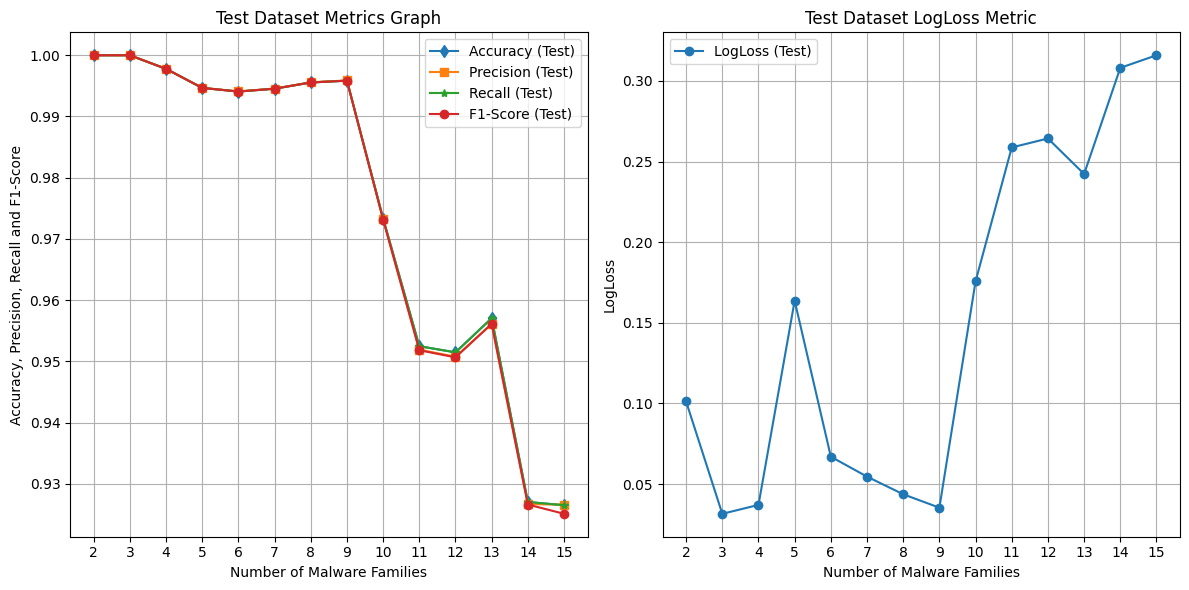

In [44]:
import matplotlib.pyplot as plt

# Datos históricos
strategies = [str(i) for i in range(2, len(test_acc_list_all) + 2)]

# Crear gráfico para Test Accuracy y Test LogLoss en una fila con dos columnas
fig, axes = plt.subplots(1, 2, figsize=(12, 6))


# Gráfico para Test Accuracy, Precision, Recall and F1-Score
axes[0].plot(strategies, test_acc_list_all, marker='d', label='Accuracy (Test)')
axes[0].plot(strategies, precision_list_all, marker='s', label='Precision (Test)')
axes[0].plot(strategies, recall_list_all, marker='*', label='Recall (Test)')
axes[0].plot(strategies, f1_score_list_all, marker='o', label='F1-Score (Test)')
axes[0].set_title('Test Dataset Metrics Graph')
axes[0].set_xlabel('Number of Malware Families')
axes[0].set_ylabel('Accuracy, Precision, Recall and F1-Score')
axes[0].legend()
axes[0].grid(True)

# Gráfico para Test LogLoss
axes[1].plot(strategies, test_loss_list_all, marker='o', label='LogLoss (Test)')
axes[1].set_title('Test Dataset LogLoss Metric')
axes[1].set_xlabel('Number of Malware Families')
axes[1].set_ylabel('LogLoss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
